#### OUTLINE

- [PROJECT DEFINITION & DATA UNDERSTANDING](#PROJECT-DEFINITION-&-DATA-UNDERSTANDING)
- [EXPLORATORY DATA ANALYSIS](#EXPLORATORY-DATA-ANALYSIS)
- [DATA PREPARATION & FEATURE ENGINEERING](#DATA-PREPARATION-&-FEATURE-ENGINEERING)    
- [BASELINE & MODEL DEVELOPMENT](#BASELINE-&-MODEL-DEVELOPMENT)
- [ERROR & RESIDUAL ANALYSIS](#ERROR-&-RESIDUAL-ANALYSIS)
- [BUSINESS INTERPRETATION & MODEL ROBUSTNESS](#BUSINESS-INTERPRETATION-&-MODEL-ROBUSTNESS)
- [FINAL MODEL & REAL-WORLD APPLICATION](#FINAL-MODEL-&-REAL-WORLD-APPLICATION)

#### PROJECT DEFINITION & DATA UNDERSTANDING

Defining the problems associated with construction cost-overrun and establish what the Machine Learning model should achieve

In [ ]:
# AI-Base Construction Cost Overrun Prediction

## Project Objective

# The objective of this project is to develop a leakage-safe, two-stage machine learning system for construction cost management.

# The system will:

# 1. Predict whether a construction project is likely to exceed its planned budget.
# 2. Estimate the expected cost overrun only when an overrun is predicted.
# 3. Identify important factors associated with construction cost overruns.
# 4. Provide practical predictions that can support early project cost-control decisions.

## Target Definition

# Actual Overrun is defined as:

# Actual Overrun = Actual Cost - Planned Budget

# As a Result, when:

# i.   When the value is Positive → Project exceeded its budget
# ii.  Zero → Project finished exactly on budget
# iii. When the value is Negative → Project finished under budget

# Total number of project in the dataset is 200
# 183 number exceeded planned budget cost
# 17 number went below the planned budget cost

## Modelling Strategy

# Stage 1:
# Classification — Will the project overrun its budget?

# Stage 2:
# Regression — If an overrun is expected, how much will the project overrun?

# Target leakage will be avoided by insuring that the predicted features will not be made avaliable during the modelling process

In [1]:
# STEP 2: IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    cross_validate
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import (
    LinearRegression,
    LogisticRegression
)

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor,
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)

import warnings

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


Import the construction synthetic dataset

In [2]:
# STEP 3: LOAD DATASET
# ============================================================


df = pd.read_csv(r"C:\Users\Emeka\Desktop\constr_overun\construction_cost_overrun_synthetic.csv")

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

display(df.head())

Rows    : 200
Columns : 11


,Project_ID,Project_Type,Location_Type,Planned_Budget_Millions,Actual_Cost_Millions,Cost_Overrun_Millions,Overrun_Percentage,Planned_Duration_Months,Actual_Duration_Months,Delay_Months,Primary_Cause_of_Overrun
0,PRJ-0001,Commercial,Suburban,16.37,17.78,1.41,8.64,21,32,11,Site Conditions
1,PRJ-0002,Industrial,Urban,135.48,146.32,10.84,8.00,11,12,1,Labor Shortage
2,PRJ-0003,Infrastructure,Urban,76.28,101.99,25.71,33.70,13,22,9,Weather Delays
3,PRJ-0004,Commercial,Suburban,124.14,127.34,3.20,2.58,30,32,2,Labor Shortage
4,PRJ-0005,Residential,Suburban,48.69,52.76,4.07,8.36,23,28,5,Design Errors


Examine rows, columns and structure

In [3]:
# STEP 4: INITIAL DATA UNDERSTANDING
# ============================================================

print("DATASET SHAPE")
print("=" * 60)

print(f"Number of projects : {df.shape[0]}")
print(f"Number of columns  : {df.shape[1]}")


print("\nCOLUMN NAMES")
print("=" * 60)

for column in df.columns:
    print(column)


print("\nDATA TYPES")
print("=" * 60)

display(
    df.dtypes.to_frame(name="Data_Type")
)


print("\nNUMERICAL SUMMARY")
print("=" * 60)

display(
    df.describe(include="all").T
)

DATASET SHAPE
Number of projects : 200
Number of columns  : 11

COLUMN NAMES
Project_ID
Project_Type
Location_Type
Planned_Budget_Millions
Actual_Cost_Millions
Cost_Overrun_Millions
Overrun_Percentage
Planned_Duration_Months
Actual_Duration_Months
Delay_Months
Primary_Cause_of_Overrun

DATA TYPES


,Data_Type
Project_ID,str
Project_Type,str
Location_Type,str
Planned_Budget_Millions,float64
Actual_Cost_Millions,float64
Cost_Overrun_Millions,float64
Overrun_Percentage,float64
Planned_Duration_Months,int64
Actual_Duration_Months,int64
Delay_Months,int64



NUMERICAL SUMMARY


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Project_ID,200,200,PRJ-0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Project_Type,200,4,Residential,66,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location_Type,200,3,Urban,113,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Planned_Budget_Millions,200.0,NaN,NaN,NaN,78.5801,45.788953,2.61,39.0725,79.285,121.855,149.96
Actual_Cost_Millions,200.0,NaN,NaN,NaN,94.1303,56.773093,3.01,43.9575,95.845,142.0275,195.46
Cost_Overrun_Millions,200.0,NaN,NaN,NaN,15.5502,15.62676,-7.28,3.72,9.93,23.675,65.87
Overrun_Percentage,200.0,NaN,NaN,NaN,19.40545,13.387998,-5.0,9.685,17.905,29.3375,56.35
Planned_Duration_Months,200.0,NaN,NaN,NaN,27.075,12.167977,6.0,17.0,28.0,38.0,47.0
Actual_Duration_Months,200.0,NaN,NaN,NaN,33.785,13.182476,6.0,24.0,34.0,44.25,60.0
Delay_Months,200.0,NaN,NaN,NaN,6.71,4.424225,0.0,3.0,7.0,10.0,18.0


In [4]:

# STEP 5: DATA QUALITY ASSESSMENT
# ============================================================

print("MISSING VALUES")
print("=" * 60)

missing_values = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing_percentage = (
    df.isnull()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

missing_report = pd.DataFrame({
    "Missing_Count": missing_values,
    "Missing_Percentage": missing_percentage
})

display(
    missing_report[
        missing_report["Missing_Count"] > 0
    ]
)


print("\nDUPLICATE RECORDS")
print("=" * 60)

duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count}")


print("\nUNIQUE VALUES")
print("=" * 60)

unique_report = pd.DataFrame({
    "Column": df.columns,
    "Unique_Values": [
        df[column].nunique(dropna=True)
        for column in df.columns
    ]
})

display(unique_report)

MISSING VALUES


,Missing_Count,Missing_Percentage



DUPLICATE RECORDS
Duplicate rows: 0

UNIQUE VALUES


,Column,Unique_Values
0,Project_ID,200
1,Project_Type,4
2,Location_Type,3
3,Planned_Budget_Millions,199
4,Actual_Cost_Millions,200
5,Cost_Overrun_Millions,199
6,Overrun_Percentage,193
7,Planned_Duration_Months,42
8,Actual_Duration_Months,52
9,Delay_Months,18


Identify numerical and categorical variables

In [7]:
# STEP 6: DEFINE TARGETS
# ============================================================

# 1. Check required columns
# ------------------------------------------------------------

required_columns = [
    "Planned_Budget_Millions",
    "Actual_Cost_Millions"
]

missing_required = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_required:

    raise ValueError(
        f"Required columns are missing: {missing_required}"
    )


# 2. Calculate Actual Overrun
# ------------------------------------------------------------

df["Actual_Overrun_Million"] = (
    df["Actual_Cost_Millions"]
    -
    df["Planned_Budget_Millions"]
)



# 3. Create Stage 1 classification target
# ------------------------------------------------------------

# 1 = Project exceeded budget
# 0 = Project did not exceed budget

df["Overrun_Flag"] = (
    df["Actual_Overrun_Million"] > 0
).astype(int)



# 4. Display target examples
# ------------------------------------------------------------

target_columns = [
    "Planned_Budget_Millions",
    "Actual_Cost_Millions",
    "Actual_Overrun_Million",
    "Overrun_Flag"
]

display(
    df[target_columns].head(10)
)


# ------------------------------------------------------------
# 5. Target interpretation
# ------------------------------------------------------------

print("TARGET DEFINITIONS")
print("=" * 70)

print(
    "Actual_Overrun_Million = "
    "Actual_Cost_Millions - Planned_Budget_Millions"
)

print(
    "Overrun_Flag = 1 → Project exceeded budget"
)

print(
    "Overrun_Flag = 0 → Project did not exceed budget"
)


# ------------------------------------------------------------
# 6. Count each outcome
# ------------------------------------------------------------

print("\nPROJECT OUTCOME DISTRIBUTION")
print("=" * 70)

print(
    f"Under budget : "
    f"{(df['Actual_Overrun_Million'] < 0).sum()}"
)

print(
    f"On budget    : "
    f"{(df['Actual_Overrun_Million'] == 0).sum()}"
)

print(
    f"Over budget  : "
    f"{(df['Actual_Overrun_Million'] > 0).sum()}"
)


# ------------------------------------------------------------
# 7. Verify target integrity
# ------------------------------------------------------------

calculated_overrun = (
    df["Actual_Cost_Millions"]
    -
    df["Planned_Budget_Millions"]
)

difference = (
    df["Actual_Overrun_Million"]
    -
    calculated_overrun
)

print("\nTARGET INTEGRITY CHECK")
print("=" * 70)

print(
    "Maximum calculation difference:",
    difference.abs().max()
)

,Planned_Budget_Millions,Actual_Cost_Millions,Actual_Overrun_Million,Overrun_Flag
0,16.37,17.78,1.41,1
1,135.48,146.32,10.84,1
2,76.28,101.99,25.71,1
3,124.14,127.34,3.20,1
4,48.69,52.76,4.07,1
5,134.43,142.76,8.33,1
6,58.99,83.16,24.17,1
7,2.61,3.01,0.40,1
8,135.90,166.29,30.39,1
9,14.60,19.68,5.08,1


TARGET DEFINITIONS
Actual_Overrun_Million = Actual_Cost_Millions - Planned_Budget_Millions
Overrun_Flag = 1 → Project exceeded budget
Overrun_Flag = 0 → Project did not exceed budget

PROJECT OUTCOME DISTRIBUTION
Under budget : 17
On budget    : 0
Over budget  : 183

TARGET INTEGRITY CHECK
Maximum calculation difference: 0.0


Identify incomplete records

ACTUAL OVERRUN DISTRIBUTION


count    200.00000
mean      15.55020
std       15.62676
min       -7.28000
25%        3.72000
50%        9.93000
75%       23.67500
max       65.87000
Name: Actual_Overrun_Million, dtype: float64


UNDER-BUDGET PROJECTS
Number of projects : 17
Average underrun  : -2.983 million
Median underrun   : -2.500 million
Largest underrun  : -7.280 million

OVER-BUDGET PROJECTS
Number of projects : 183
Average overrun   : 17.272 million
Median overrun    : 11.060 million
Largest overrun   : 65.870 million

ALL UNDER-BUDGET PROJECTS


,Project_Type,Location_Type,Planned_Budget_Millions,Actual_Cost_Millions,Actual_Overrun_Million
71,Residential,Suburban,145.51,138.23,-7.28
181,Residential,Suburban,147.02,139.87,-7.15
112,Industrial,Urban,139.98,132.98,-7.00
77,Residential,Suburban,83.52,79.39,-4.13
124,Residential,Rural,125.91,122.46,-3.45
90,Residential,Urban,68.89,65.45,-3.44
18,Commercial,Suburban,101.21,97.99,-3.22
121,Industrial,Suburban,57.75,54.86,-2.89
17,Commercial,Suburban,49.97,47.47,-2.50
28,Commercial,Suburban,53.29,51.01,-2.28


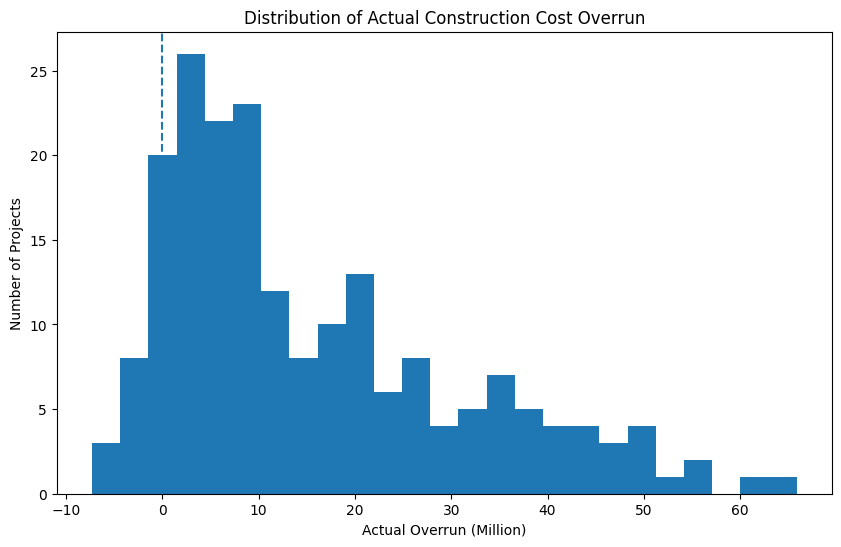

In [8]:
# ============================================================
# STEP 7: TARGET DISTRIBUTION ANALYSIS
# ============================================================
# identify projects with under-budget and over-budgeted costs. The negative value of the Actual_Over_Millions meane that the project can be identify 
# as Underrun, Under budget, Cost saving or Favorable cost variance
#
# Actual_Overrun_Million = Actual_Cost − Planned_Budget


print("ACTUAL OVERRUN DISTRIBUTION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Descriptive statistics
# ------------------------------------------------------------

display(
    df["Actual_Overrun_Million"].describe()
)


# ------------------------------------------------------------
# 2. Under-budget statistics
# ------------------------------------------------------------

under_budget = df[
    df["Actual_Overrun_Million"] < 0
]["Actual_Overrun_Million"]

print("\nUNDER-BUDGET PROJECTS")
print("=" * 70)

print(f"Number of projects : {len(under_budget)}")

if len(under_budget) > 0:

    print(
        f"Average underrun  : "
        f"{under_budget.mean():.3f} million"
    )

    print(
        f"Median underrun   : "
        f"{under_budget.median():.3f} million"
    )

    print(
        f"Largest underrun  : "
        f"{under_budget.min():.3f} million"
    )


# ------------------------------------------------------------
# 3. Over-budget statistics
# ------------------------------------------------------------

over_budget = df[
    df["Actual_Overrun_Million"] > 0
]["Actual_Overrun_Million"]

print("\nOVER-BUDGET PROJECTS")
print("=" * 70)

print(f"Number of projects : {len(over_budget)}")

if len(over_budget) > 0:

    print(
        f"Average overrun   : "
        f"{over_budget.mean():.3f} million"
    )

    print(
        f"Median overrun    : "
        f"{over_budget.median():.3f} million"
    )

    print(
        f"Largest overrun   : "
        f"{over_budget.max():.3f} million"
    )


# ------------------------------------------------------------
# 4. Show all underrun projects
# ------------------------------------------------------------

print("\nALL UNDER-BUDGET PROJECTS")
print("=" * 70)

display(
    df[
        df["Actual_Overrun_Million"] < 0
    ][
        [
            "Project_Type",
            "Location_Type",
            "Planned_Budget_Millions",
            "Actual_Cost_Millions",
            "Actual_Overrun_Million"
        ]
    ].sort_values(
        by="Actual_Overrun_Million"
    )
)


# ------------------------------------------------------------
# 5. Histogram of actual overrun
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.hist(
    df["Actual_Overrun_Million"],
    bins=25
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.title(
    "Distribution of Actual Construction Cost Overrun"
)

plt.xlabel(
    "Actual Overrun (Million)"
)

plt.ylabel(
    "Number of Projects"
)

plt.show()

In [9]:
# Discovered Facts; 
# We have total of 200 projects
# 17 under budget
# 183 over budget
#
# The Target integrity check = 0.0
#
# Negative overruns will not be deleted or artificially changed.

# We are building the new two-stage classification + regression system.

Detection of duplicates in the dataset

In [10]:
# ============================================================
# STEP 8: DATA CLEANING
# ============================================================

# ------------------------------------------------------------
# 1. Create a working copy
# ------------------------------------------------------------

df_model = df.copy()


# ------------------------------------------------------------
# 2. Check duplicate rows
# ------------------------------------------------------------

duplicate_count = df_model.duplicated().sum()

print("DATA CLEANING")
print("=" * 70)

print(f"Duplicate rows found: {duplicate_count}")


# ------------------------------------------------------------
# 3. Remove exact duplicate rows if any exist
# ------------------------------------------------------------

if duplicate_count > 0:

    df_model = df_model.drop_duplicates().reset_index(drop=True)

    print(
        f"Duplicates removed: {duplicate_count}"
    )

else:

    print("No duplicate rows found.")


# ------------------------------------------------------------
# 4. Check missing values
# ------------------------------------------------------------

missing_report = (
    df_model.isnull()
    .sum()
    .sort_values(ascending=False)
)

print("\nMISSING VALUES")
print("=" * 70)

display(
    missing_report[
        missing_report > 0
    ]
)


# ------------------------------------------------------------
# 5. Check infinite values in numeric columns
# ------------------------------------------------------------

numeric_columns = df_model.select_dtypes(
    include=np.number
).columns

infinite_counts = np.isinf(
    df_model[numeric_columns]
).sum()

print("\nINFINITE VALUES")
print("=" * 70)

display(
    infinite_counts[
        infinite_counts > 0
    ]
)


# ------------------------------------------------------------
# 6. Final dataset shape
# ------------------------------------------------------------

print("\nFINAL DATASET SHAPE")
print("=" * 70)

print(
    f"Rows    : {df_model.shape[0]}"
)

print(
    f"Columns : {df_model.shape[1]}"
)

DATA CLEANING
Duplicate rows found: 0
No duplicate rows found.

MISSING VALUES


Series([], dtype: int64)


INFINITE VALUES


Series([], dtype: int64)


FINAL DATASET SHAPE
Rows    : 200
Columns : 13


In [11]:
# ============================================================
# STEP 9: STRICT INDUSTRIAL LEAKAGE AUDIT
# ============================================================
#
# Data Leakage is when the machine-learning model is given information that would NOT have been available at the 
# time we are supposed to make the cost-overrun prediction. 
# Some columns were excluding the machine-learning model because they are the key targets. They are what we expect the machine to predict.
# Thus we are not suspose to  give the machine the result. If such happens, it will cause data leakage. While the ones that are included
# the predictors, variables that will assist us in the prediction. 


print("STRICT INDUSTRIAL LEAKAGE AUDIT")
print("=" * 75)


# ------------------------------------------------------------
# 1. Define the variables that are NEVER allowed as predictors
# ------------------------------------------------------------

target_columns = [
    "Actual_Overrun_Million",
    "Overrun_Flag"
]


# ------------------------------------------------------------
# 2. Define variables that represent completed-project
#    information and therefore cannot be used for a
#    pre-project prediction
# ------------------------------------------------------------

post_completion_columns = [
    "Actual_Cost_Millions",
    "Cost_Overrun_Millions",
    "Overrun_Percentage",
    "Actual_Duration_Months",
    "Delay_Months",
    "Primary_Cause_of_Overrun"
]


# ------------------------------------------------------------
# 3. Project identifier
# ------------------------------------------------------------

identifier_columns = [
    "Project_ID"
]


# ------------------------------------------------------------
# 4. Combine all columns that must be excluded
# ------------------------------------------------------------

leakage_exclusion_columns = list(
    dict.fromkeys(
        target_columns
        + post_completion_columns
        + identifier_columns
    )
)


# ------------------------------------------------------------
# 5. Check which exclusion columns actually exist
# ------------------------------------------------------------

existing_exclusion_columns = [
    column
    for column in leakage_exclusion_columns
    if column in df_model.columns
]


missing_exclusion_columns = [
    column
    for column in leakage_exclusion_columns
    if column not in df_model.columns
]


# ------------------------------------------------------------
# 6. Display columns being excluded
# ------------------------------------------------------------

print("\nCOLUMNS EXCLUDED FROM MODEL")
print("=" * 75)

for column in existing_exclusion_columns:

    print(f"EXCLUDE: {column}")


# ------------------------------------------------------------
# 7. Identify safe candidate predictors
# ------------------------------------------------------------

candidate_features = [
    column
    for column in df_model.columns
    if column not in existing_exclusion_columns
]


# ------------------------------------------------------------
# 8. Display candidate predictors
# ------------------------------------------------------------

print("\nCANDIDATE PREDICTORS")
print("=" * 75)

for column in candidate_features:

    print(f"KEEP FOR FURTHER REVIEW: {column}")


# ------------------------------------------------------------
# 9. Check that no known leakage variables remain
# ------------------------------------------------------------

leakage_remaining = [
    column
    for column in candidate_features
    if column in existing_exclusion_columns
]


print("\nSTRICT LEAKAGE CHECK")
print("=" * 75)

if len(leakage_remaining) == 0:

    print(
        "PASS: No predefined leakage/outcome columns "
        "remain among the candidate predictors."
    )

else:

    print(
        "FAIL: Potential leakage remains:"
    )

    for column in leakage_remaining:

        print(f"- {column}")


# ------------------------------------------------------------
# 10. Check whether target variables accidentally appear
#     in candidate predictors
# ------------------------------------------------------------

target_leakage = [
    column
    for column in candidate_features
    if column in target_columns
]


print("\nTARGET LEAKAGE CHECK")
print("=" * 75)

if len(target_leakage) == 0:

    print(
        "PASS: Actual_Overrun_Million and Overrun_Flag "
        "are excluded from predictors."
    )

else:

    print(
        "FAIL: Target leakage detected:"
    )

    for column in target_leakage:

        print(f"- {column}")


# ------------------------------------------------------------
# 11. Display the final candidate feature count
# ------------------------------------------------------------

print("\nCANDIDATE FEATURE COUNT")
print("=" * 75)

print(
    f"Number of candidate predictors: "
    f"{len(candidate_features)}"
)


# ------------------------------------------------------------
# 12. Important warning
# ------------------------------------------------------------

print("\nIMPORTANT MODELLING RULE")
print("=" * 75)

print(
    "Candidate predictors will NOT automatically be used."
)

print(
    "Each candidate must be confirmed as information "
    "available at the time the prediction is made."
)

print(
    "No actual project outcome information will be "
    "allowed into the prediction model."
)

STRICT INDUSTRIAL LEAKAGE AUDIT

COLUMNS EXCLUDED FROM MODEL
EXCLUDE: Actual_Overrun_Million
EXCLUDE: Overrun_Flag
EXCLUDE: Actual_Cost_Millions
EXCLUDE: Cost_Overrun_Millions
EXCLUDE: Overrun_Percentage
EXCLUDE: Actual_Duration_Months
EXCLUDE: Delay_Months
EXCLUDE: Primary_Cause_of_Overrun
EXCLUDE: Project_ID

CANDIDATE PREDICTORS
KEEP FOR FURTHER REVIEW: Project_Type
KEEP FOR FURTHER REVIEW: Location_Type
KEEP FOR FURTHER REVIEW: Planned_Budget_Millions
KEEP FOR FURTHER REVIEW: Planned_Duration_Months

STRICT LEAKAGE CHECK
PASS: No predefined leakage/outcome columns remain among the candidate predictors.

TARGET LEAKAGE CHECK
PASS: Actual_Overrun_Million and Overrun_Flag are excluded from predictors.

CANDIDATE FEATURE COUNT
Number of candidate predictors: 4

IMPORTANT MODELLING RULE
Candidate predictors will NOT automatically be used.
Each candidate must be confirmed as information available at the time the prediction is made.
No actual project outcome information will be allowed in

In [12]:
# ============================================================
# STEP 10: FINAL LEAKAGE-SAFE FEATURE SELECTION
# ============================================================

print("STEP 10: FINAL LEAKAGE-SAFE FEATURE SELECTION")
print("=" * 75)


# ------------------------------------------------------------
# 1. Define the approved predictors
# ------------------------------------------------------------

approved_features = [
    "Project_Type",
    "Location_Type",
    "Planned_Budget_Millions",
    "Planned_Duration_Months"
]


# ------------------------------------------------------------
# 2. Verify that every approved feature exists
# ------------------------------------------------------------

missing_features = [
    column
    for column in approved_features
    if column not in df_model.columns
]


if missing_features:

    raise ValueError(
        "The following approved features are missing: "
        + str(missing_features)
    )


# ------------------------------------------------------------
# 3. Create predictor dataset
# ------------------------------------------------------------

X = df_model[approved_features].copy()


# ------------------------------------------------------------
# 4. Create Stage 1 classification target
# ------------------------------------------------------------

y_classification = df_model["Overrun_Flag"].copy()


# ------------------------------------------------------------
# 5. Create Stage 2 regression target
# ------------------------------------------------------------

y_regression = df_model["Actual_Overrun_Million"].copy()


# ------------------------------------------------------------
# 6. Display predictor information
# ------------------------------------------------------------

print("\nAPPROVED PREDICTORS")
print("=" * 75)

for feature in approved_features:

    print(f"- {feature}")


print(
    f"\nNumber of approved predictors: "
    f"{len(approved_features)}"
)


# ------------------------------------------------------------
# 7. Display target information
# ------------------------------------------------------------

print("\nTARGETS")
print("=" * 75)

print(
    "Stage 1 target: Overrun_Flag"
)

print(
    "Stage 2 target: Actual_Overrun_Million"
)


# ------------------------------------------------------------
# 8. Confirm that prohibited columns are NOT in X
# ------------------------------------------------------------

prohibited_columns = [
    "Actual_Cost_Millions",
    "Actual_Overrun_Million",
    "Overrun_Flag",
    "Cost_Overrun_Millions",
    "Overrun_Percentage",
    "Actual_Duration_Months",
    "Delay_Months",
    "Primary_Cause_of_Overrun",
    "Project_ID"
]


leakage_in_X = [
    column
    for column in X.columns
    if column in prohibited_columns
]


print("\nFINAL FEATURE LEAKAGE CHECK")
print("=" * 75)


if len(leakage_in_X) == 0:

    print(
        "PASS: No prohibited leakage variables "
        "are present in X."
    )

else:

    print(
        "FAIL: Leakage detected in X:"
    )

    for column in leakage_in_X:

        print(f"- {column}")


# ------------------------------------------------------------
# 9. Display shapes
# ------------------------------------------------------------

print("\nDATA SHAPES")
print("=" * 75)

print(f"X shape                  : {X.shape}")
print(f"Classification target    : {y_classification.shape}")
print(f"Regression target        : {y_regression.shape}")


# ------------------------------------------------------------
# 10. Display first five predictor records
# ------------------------------------------------------------

print("\nFIRST FIVE PREDICTOR RECORDS")
print("=" * 75)

display(X.head())

STEP 10: FINAL LEAKAGE-SAFE FEATURE SELECTION

APPROVED PREDICTORS
- Project_Type
- Location_Type
- Planned_Budget_Millions
- Planned_Duration_Months

Number of approved predictors: 4

TARGETS
Stage 1 target: Overrun_Flag
Stage 2 target: Actual_Overrun_Million

FINAL FEATURE LEAKAGE CHECK
PASS: No prohibited leakage variables are present in X.

DATA SHAPES
X shape                  : (200, 4)
Classification target    : (200,)
Regression target        : (200,)

FIRST FIVE PREDICTOR RECORDS


,Project_Type,Location_Type,Planned_Budget_Millions,Planned_Duration_Months
0,Commercial,Suburban,16.37,21
1,Industrial,Urban,135.48,11
2,Infrastructure,Urban,76.28,13
3,Commercial,Suburban,124.14,30
4,Residential,Suburban,48.69,23


#### EXPLORATORY DATA ANALYSIS

In [13]:
# ============================================================
# STEP 11: LEAKAGE-SAFE FEATURE ENGINEERING
# ============================================================

print("STEP 11: LEAKAGE-SAFE FEATURE ENGINEERING")
print("=" * 75)


# ------------------------------------------------------------
# 1. Create a copy of the approved predictors
# ------------------------------------------------------------

X_engineered = X.copy()


# ------------------------------------------------------------
# 2. Check planned duration before creating the ratio
# ------------------------------------------------------------

print("\nPLANNED DURATION CHECK")
print("=" * 75)

print(
    "Minimum planned duration:",
    X_engineered["Planned_Duration_Months"].min()
)

print(
    "Number of zero planned durations:",
    (
        X_engineered["Planned_Duration_Months"] == 0
    ).sum()
)

print(
    "Number of negative planned durations:",
    (
        X_engineered["Planned_Duration_Months"] < 0
    ).sum()
)


# ------------------------------------------------------------
# 3. Create Planned Cost Rate
# ------------------------------------------------------------
# This uses ONLY:
# Planned Budget
# Planned Duration
#
# It does NOT use actual project outcomes.

X_engineered["Planned_Cost_Per_Month_Million"] = np.where(
    X_engineered["Planned_Duration_Months"] > 0,

    X_engineered["Planned_Budget_Millions"]
    /
    X_engineered["Planned_Duration_Months"],

    np.nan
)


# ------------------------------------------------------------
# 4. Display the engineered feature
# ------------------------------------------------------------

print("\nENGINEERED FEATURE")
print("=" * 75)

display(
    X_engineered[
        [
            "Planned_Budget_Millions",
            "Planned_Duration_Months",
            "Planned_Cost_Per_Month_Million"
        ]
    ].head(10)
)


# ------------------------------------------------------------
# 5. Check the engineered feature
# ------------------------------------------------------------

print("\nENGINEERED FEATURE QUALITY CHECK")
print("=" * 75)

print(
    "Missing values:",
    X_engineered[
        "Planned_Cost_Per_Month_Million"
    ].isnull().sum()
)

print(
    "Infinite values:",
    np.isinf(
        X_engineered[
            "Planned_Cost_Per_Month_Million"
        ].dropna()
    ).sum()
)


# ------------------------------------------------------------
# 6. Display summary statistics
# ------------------------------------------------------------

print("\nENGINEERED FEATURE SUMMARY")
print("=" * 75)

display(
    X_engineered[
        "Planned_Cost_Per_Month_Million"
    ].describe()
)


# ------------------------------------------------------------
# 7. Final leakage check
# ------------------------------------------------------------

forbidden_columns = [
    "Actual_Cost_Millions",
    "Actual_Overrun_Million",
    "Overrun_Flag",
    "Cost_Overrun_Millions",
    "Overrun_Percentage",
    "Actual_Duration_Months",
    "Delay_Months",
    "Primary_Cause_of_Overrun",
    "Project_ID"
]

leakage_columns = [
    column
    for column in X_engineered.columns
    if column in forbidden_columns
]


print("\nFINAL FEATURE-ENGINEERING LEAKAGE CHECK")
print("=" * 75)

if len(leakage_columns) == 0:

    print(
        "PASS: No prohibited outcome or "
        "post-completion variables were introduced."
    )

else:

    raise ValueError(
        f"LEAKAGE DETECTED: {leakage_columns}"
    )


# ------------------------------------------------------------
# 8. Final feature list
# ------------------------------------------------------------

print("\nFINAL FEATURE LIST")
print("=" * 75)

for feature in X_engineered.columns:

    print(f"- {feature}")


print("\nSTEP 11 STATUS")
print("=" * 75)

print(
    f"Original predictors : {X.shape[1]}"
)

print(
    f"Final predictors    : {X_engineered.shape[1]}"
)

print(
    "Feature engineering completed successfully."
)

STEP 11: LEAKAGE-SAFE FEATURE ENGINEERING

PLANNED DURATION CHECK
Minimum planned duration: 6
Number of zero planned durations: 0
Number of negative planned durations: 0

ENGINEERED FEATURE


,Planned_Budget_Millions,Planned_Duration_Months,Planned_Cost_Per_Month_Million
0,16.37,21,0.779524
1,135.48,11,12.316364
2,76.28,13,5.867692
3,124.14,30,4.138000
4,48.69,23,2.116957
5,134.43,30,4.481000
6,58.99,17,3.470000
7,2.61,20,0.130500
8,135.90,31,4.383871
9,14.60,46,0.317391



ENGINEERED FEATURE QUALITY CHECK
Missing values: 0
Infinite values: 0

ENGINEERED FEATURE SUMMARY


count    200.000000
mean       3.814470
std        3.437606
min        0.075476
25%        1.415808
50%        3.031289
75%        4.973417
max       23.768333
Name: Planned_Cost_Per_Month_Million, dtype: float64


FINAL FEATURE-ENGINEERING LEAKAGE CHECK
PASS: No prohibited outcome or post-completion variables were introduced.

FINAL FEATURE LIST
- Project_Type
- Location_Type
- Planned_Budget_Millions
- Planned_Duration_Months
- Planned_Cost_Per_Month_Million

STEP 11 STATUS
Original predictors : 4
Final predictors    : 5
Feature engineering completed successfully.


In [ ]:
# In step 11, an additional pre-project predictor was created. This predictor will be a leakage-safe feature that will 
# describe the  planned monthly cost intensity. It will verify  that no actual/post-completion information will  enter the predictors. 

In [14]:
# ============================================================
# STEP 12: STRATIFIED TRAIN / TEST SPLIT
# ============================================================

print("STEP 12: TRAIN / TEST SPLIT")
print("=" * 75)


# ------------------------------------------------------------
# 1. Define X and targets
# ------------------------------------------------------------

X_final = X_engineered.copy()

y_class = y_classification.copy()

y_reg = y_regression.copy()


# ------------------------------------------------------------
# 2. Stratified train/test split
# ------------------------------------------------------------
# Stratification is based on the Stage 1 target.
#
# This helps preserve the under-budget / over-budget
# distribution in both training and testing data.

X_train, X_test, y_class_train, y_class_test = train_test_split(
    X_final,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)


# ------------------------------------------------------------
# 3. Keep regression target aligned with the split
# ------------------------------------------------------------

y_reg_train = y_reg.loc[X_train.index]

y_reg_test = y_reg.loc[X_test.index]


# ------------------------------------------------------------
# 4. Display shapes
# ------------------------------------------------------------

print("\nDATASET SHAPES")
print("=" * 75)

print(f"Complete X dataset : {X_final.shape}")
print(f"Training X         : {X_train.shape}")
print(f"Testing X          : {X_test.shape}")

print(
    f"\nClassification training target: "
    f"{y_class_train.shape}"
)

print(
    f"Classification testing target : "
    f"{y_class_test.shape}"
)

print(
    f"Regression training target    : "
    f"{y_reg_train.shape}"
)

print(
    f"Regression testing target     : "
    f"{y_reg_test.shape}"
)


# ------------------------------------------------------------
# 5. Check classification distribution
# ------------------------------------------------------------

print("\nCLASS DISTRIBUTION")
print("=" * 75)

class_distribution = pd.DataFrame({
    "Full_Dataset": y_class.value_counts(),
    "Training_Set": y_class_train.value_counts(),
    "Test_Set": y_class_test.value_counts()
})

class_distribution.index.name = "Overrun_Flag"

display(
    class_distribution.sort_index()
)


# ------------------------------------------------------------
# 6. Display percentages
# ------------------------------------------------------------

print("\nCLASS DISTRIBUTION (%)")
print("=" * 75)

class_percentage = pd.DataFrame({
    "Full_Dataset_%": (
        y_class.value_counts(normalize=True) * 100
    ),
    "Training_Set_%": (
        y_class_train.value_counts(normalize=True) * 100
    ),
    "Test_Set_%": (
        y_class_test.value_counts(normalize=True) * 100
    )
})

class_percentage.index.name = "Overrun_Flag"

display(
    class_percentage.sort_index().round(2)
)


# ------------------------------------------------------------
# 7. Verify that train and test indices do not overlap
# ------------------------------------------------------------

index_overlap = set(
    X_train.index
).intersection(
    set(X_test.index)
)


print("\nTRAIN / TEST SEPARATION CHECK")
print("=" * 75)

print(
    f"Overlapping records: {len(index_overlap)}"
)


if len(index_overlap) == 0:

    print(
        "PASS: Training and testing records are completely separate."
    )

else:

    raise ValueError(
        "ERROR: Training and testing records overlap."
    )


# ------------------------------------------------------------
# 8. Verify target alignment
# ------------------------------------------------------------

classification_alignment = (
    X_train.index.equals(
        y_class_train.index
    )
    and
    X_test.index.equals(
        y_class_test.index
    )
)

regression_alignment = (
    X_train.index.equals(
        y_reg_train.index
    )
    and
    X_test.index.equals(
        y_reg_test.index
    )
)


print("\nTARGET ALIGNMENT CHECK")
print("=" * 75)

print(
    "Classification alignment:",
    classification_alignment
)

print(
    "Regression alignment:",
    regression_alignment
)


if not classification_alignment:

    raise ValueError(
        "Classification features and target are not aligned."
    )


if not regression_alignment:

    raise ValueError(
        "Regression features and target are not aligned."
    )


print("\nSTEP 12 STATUS")
print("=" * 75)

print(
    "PASS: Stratified train/test split completed."
)

print(
    "PASS: No train/test record overlap."
)

print(
    "PASS: Classification and regression targets are aligned."
)

STEP 12: TRAIN / TEST SPLIT

DATASET SHAPES
Complete X dataset : (200, 5)
Training X         : (160, 5)
Testing X          : (40, 5)

Classification training target: (160,)
Classification testing target : (40,)
Regression training target    : (160,)
Regression testing target     : (40,)

CLASS DISTRIBUTION


,Full_Dataset,Training_Set,Test_Set
Overrun_Flag,,,
0,17,14,3
1,183,146,37



CLASS DISTRIBUTION (%)


,Full_Dataset_%,Training_Set_%,Test_Set_%
Overrun_Flag,,,
0,8.5,8.75,7.5
1,91.5,91.25,92.5



TRAIN / TEST SEPARATION CHECK
Overlapping records: 0
PASS: Training and testing records are completely separate.

TARGET ALIGNMENT CHECK
Classification alignment: True
Regression alignment: True

STEP 12 STATUS
PASS: Stratified train/test split completed.
PASS: No train/test record overlap.
PASS: Classification and regression targets are aligned.


In [ ]:
# In step 12, the dataset  of 200 projects were divided into 160 training projects (80%) and 40 unseen testing projects (20%). The Predictors were 5 
# No project was duplicated (there is zero overlap). Classification alignment was true.  
# Regression targets was correctly matched

In [15]:
# ============================================================
# STEP 13: LEAKAGE-SAFE PREPROCESSING PIPELINE
# ============================================================
# In this step we are going to convert the predictors into a clean numerical format that the Machine Learning model can understand.


print("STEP 13: LEAKAGE-SAFE PREPROCESSING PIPELINE")
print("=" * 75)


# ------------------------------------------------------------
# 1. Identify feature types
# ------------------------------------------------------------

categorical_features = [
    "Project_Type",
    "Location_Type"
]

numerical_features = [
    "Planned_Budget_Millions",
    "Planned_Duration_Months",
    "Planned_Cost_Per_Month_Million"
]


# ------------------------------------------------------------
# 2. Verify all features exist
# ------------------------------------------------------------

all_selected_features = (
    categorical_features
    + numerical_features
)

missing_features = [
    feature
    for feature in all_selected_features
    if feature not in X_train.columns
]

if missing_features:

    raise ValueError(
        f"Missing features: {missing_features}"
    )


# ------------------------------------------------------------
# 3. Numerical preprocessing
# ------------------------------------------------------------

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)


# ------------------------------------------------------------
# 4. Categorical preprocessing
# ------------------------------------------------------------

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


# ------------------------------------------------------------
# 5. Combine preprocessing
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)


# ------------------------------------------------------------
# 6. Fit ONLY on training data
# ------------------------------------------------------------

preprocessor.fit(X_train)


# ------------------------------------------------------------
# 7. Transform training and test data
# ------------------------------------------------------------

X_train_processed = preprocessor.transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)


# ------------------------------------------------------------
# 8. Display dimensions
# ------------------------------------------------------------

print("\nPROCESSED DATA SHAPES")
print("=" * 75)

print(
    "Training data:",
    X_train_processed.shape
)

print(
    "Testing data :",
    X_test_processed.shape
)


# ------------------------------------------------------------
# 9. Check for missing values
# ------------------------------------------------------------

print("\nMISSING VALUE CHECK")
print("=" * 75)

print(
    "Training missing values:",
    np.isnan(X_train_processed).sum()
)

print(
    "Testing missing values :",
    np.isnan(X_test_processed).sum()
)


# ------------------------------------------------------------
# 10. Check for infinite values
# ------------------------------------------------------------

print("\nINFINITE VALUE CHECK")
print("=" * 75)

print(
    "Training infinite values:",
    np.isinf(X_train_processed).sum()
)

print(
    "Testing infinite values :",
    np.isinf(X_test_processed).sum()
)


# ------------------------------------------------------------
# 11. Final status
# ------------------------------------------------------------

print("\nSTEP 13 STATUS")
print("=" * 75)

print(
    "PASS: Preprocessing was fitted using training data only."
)

print(
    "PASS: Unknown categories will be ignored safely."
)

print(
    "PASS: Missing numerical values use training-set medians."
)

print(
    "PASS: Missing categorical values use training-set modes."
)

print(
    "PASS: No missing or infinite values remain after preprocessing."
)

STEP 13: LEAKAGE-SAFE PREPROCESSING PIPELINE

PROCESSED DATA SHAPES
Training data: (160, 10)
Testing data : (40, 10)

MISSING VALUE CHECK
Training missing values: 0
Testing missing values : 0

INFINITE VALUE CHECK
Training infinite values: 0
Testing infinite values : 0

STEP 13 STATUS
PASS: Preprocessing was fitted using training data only.
PASS: Unknown categories will be ignored safely.
PASS: Missing numerical values use training-set medians.
PASS: Missing categorical values use training-set modes.
PASS: No missing or infinite values remain after preprocessing.


In [ ]:
# In step 13 the 5 raw predictors converted into 10 clean numerical model features. Unknown values were handled safely, 
# Preprocessing was fitted only on the 160 training projects. 

In [16]:
# ============================================================
# STEP 14: STAGE 1 CLASSIFICATION BASELINE
# ============================================================

print("STEP 14: STAGE 1 CLASSIFICATION BASELINE")
print("=" * 75)


# ------------------------------------------------------------
# 1. Import classification models
# ------------------------------------------------------------

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


# ------------------------------------------------------------
# 2. Create baseline classification model
# ------------------------------------------------------------
# class_weight="balanced" compensates for the strong
# imbalance between under-budget and over-budget projects.

classification_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)


# ------------------------------------------------------------
# 3. Train ONLY on the training data
# ------------------------------------------------------------

classification_model.fit(
    X_train_processed,
    y_class_train
)


# ------------------------------------------------------------
# 4. Generate predictions
# ------------------------------------------------------------

y_class_pred = classification_model.predict(
    X_test_processed
)


# Probability of class 1 = over budget

y_class_probability = (
    classification_model
    .predict_proba(X_test_processed)[:, 1]
)


# ------------------------------------------------------------
# 5. Calculate evaluation metrics
# ------------------------------------------------------------

classification_accuracy = accuracy_score(
    y_class_test,
    y_class_pred
)

classification_precision = precision_score(
    y_class_test,
    y_class_pred,
    zero_division=0
)

classification_recall = recall_score(
    y_class_test,
    y_class_pred,
    zero_division=0
)

classification_f1 = f1_score(
    y_class_test,
    y_class_pred,
    zero_division=0
)

classification_roc_auc = roc_auc_score(
    y_class_test,
    y_class_probability
)


# ------------------------------------------------------------
# 6. Display metrics
# ------------------------------------------------------------

print("\nCLASSIFICATION PERFORMANCE")
print("=" * 75)

print(
    f"Accuracy  : {classification_accuracy:.3f}"
)

print(
    f"Precision : {classification_precision:.3f}"
)

print(
    f"Recall    : {classification_recall:.3f}"
)

print(
    f"F1 Score  : {classification_f1:.3f}"
)

print(
    f"ROC-AUC   : {classification_roc_auc:.3f}"
)


# ------------------------------------------------------------
# 7. Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_class_test,
    y_class_pred
)


print("\nCONFUSION MATRIX")
print("=" * 75)

print(cm)


# ------------------------------------------------------------
# 8. Classification report
# ------------------------------------------------------------

print("\nCLASSIFICATION REPORT")
print("=" * 75)

print(
    classification_report(
        y_class_test,
        y_class_pred,
        target_names=[
            "Under Budget",
            "Over Budget"
        ],
        zero_division=0
    )
)


# ------------------------------------------------------------
# 9. Display actual versus predicted outcomes
# ------------------------------------------------------------

classification_results = pd.DataFrame({
    "Actual_Overrun_Flag": y_class_test.values,
    "Predicted_Overrun_Flag": y_class_pred,
    "Probability_Overrun": y_class_probability
})


print("\nFIRST 10 CLASSIFICATION PREDICTIONS")
print("=" * 75)

display(
    classification_results.head(10)
)


# ------------------------------------------------------------
# 10. Baseline status
# ------------------------------------------------------------

print("\nSTEP 14 STATUS")
print("=" * 75)

print(
    "Stage 1 baseline classifier trained successfully."
)

print(
    "The classifier was trained using training data only."
)

print(
    "Class imbalance was handled using class_weight='balanced'."
)

STEP 14: STAGE 1 CLASSIFICATION BASELINE

CLASSIFICATION PERFORMANCE
Accuracy  : 0.650
Precision : 0.926
Recall    : 0.676
F1 Score  : 0.781
ROC-AUC   : 0.685

CONFUSION MATRIX
[[ 1  2]
 [12 25]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

Under Budget       0.08      0.33      0.12         3
 Over Budget       0.93      0.68      0.78        37

    accuracy                           0.65        40
   macro avg       0.50      0.50      0.45        40
weighted avg       0.86      0.65      0.73        40


FIRST 10 CLASSIFICATION PREDICTIONS


,Actual_Overrun_Flag,Predicted_Overrun_Flag,Probability_Overrun
0,1,1,0.864511
1,1,0,0.197672
2,1,1,0.549722
3,1,1,0.861884
4,0,0,0.212494
5,1,1,0.792105
6,1,1,0.908357
7,1,0,0.410845
8,1,0,0.229759
9,1,1,0.805250



STEP 14 STATUS
Stage 1 baseline classifier trained successfully.
The classifier was trained using training data only.
Class imbalance was handled using class_weight='balanced'.


In [17]:
# We got  65% accuracy and a ROC-AUC of 0.685 on the 40-project test set. The model perform better in identifying  
# Over Budget projects with precision 93%, recall 68%, F1 78%.  While the model is finding it difficult to predict Under Budget projects 
# with precision 8%, recall 33%, F1 12%. 

In [19]:
# ============================================================
# STEP 15: STAGE 1 STRATIFIED CROSS-VALIDATION
# ============================================================

print("STEP 15: STAGE 1 CROSS-VALIDATION")
print("=" * 75)


# ------------------------------------------------------------
# 1. Import cross-validation tools
# ------------------------------------------------------------

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    make_scorer,
    precision_score,
    recall_score,
    f1_score
)


# ------------------------------------------------------------
# 2. Rebuild preprocessing pipeline
# ------------------------------------------------------------

cv_numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)


cv_categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


# ------------------------------------------------------------
# 3. Combine preprocessing
# ------------------------------------------------------------

cv_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            cv_numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            cv_categorical_transformer,
            categorical_features
        )
    ]
)


# ------------------------------------------------------------
# 4. Create classification pipeline
# ------------------------------------------------------------

cv_classification_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            cv_preprocessor
        ),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                random_state=42
            )
        )
    ]
)


# ------------------------------------------------------------
# 5. Create stratified 5-fold cross-validation
# ------------------------------------------------------------

stratified_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ------------------------------------------------------------
# 6. Define evaluation metrics
# ------------------------------------------------------------

scoring = {

    "Precision": make_scorer(
        precision_score,
        zero_division=0
    ),

    "Recall": make_scorer(
        recall_score,
        zero_division=0
    ),

    "F1": make_scorer(
        f1_score,
        zero_division=0
    ),

    "ROC_AUC": "roc_auc"
}


# ------------------------------------------------------------
# 7. Run cross-validation
# ------------------------------------------------------------

cv_results = cross_validate(
    cv_classification_pipeline,
    X_final,
    y_class,
    cv=stratified_cv,
    scoring=scoring,
    return_train_score=False
)


# ------------------------------------------------------------
# 8. Calculate mean and standard deviation
# ------------------------------------------------------------

precision_mean = cv_results[
    "test_Precision"
].mean()

precision_std = cv_results[
    "test_Precision"
].std()

recall_mean = cv_results[
    "test_Recall"
].mean()

recall_std = cv_results[
    "test_Recall"
].std()

f1_mean = cv_results[
    "test_F1"
].mean()

f1_std = cv_results[
    "test_F1"
].std()

roc_auc_mean = cv_results[
    "test_ROC_AUC"
].mean()

roc_auc_std = cv_results[
    "test_ROC_AUC"
].std()


# ------------------------------------------------------------
# 9. Create results table
# ------------------------------------------------------------

cv_classification_results = pd.DataFrame({

    "Metric": [
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],

    "Mean": [
        precision_mean,
        recall_mean,
        f1_mean,
        roc_auc_mean
    ],

    "STD": [
        precision_std,
        recall_std,
        f1_std,
        roc_auc_std
    ]
})


# ------------------------------------------------------------
# 10. Display results WITHOUT .style
# ------------------------------------------------------------

print("\n5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 75)

display(
    cv_classification_results.round(3)
)


# ------------------------------------------------------------
# 11. Display individual fold results
# ------------------------------------------------------------

print("\nINDIVIDUAL FOLD RESULTS")
print("=" * 75)

for fold_number in range(5):

    print(
        f"\nFold {fold_number + 1}:"
    )

    print(
        f"Precision : "
        f"{cv_results['test_Precision'][fold_number]:.3f}"
    )

    print(
        f"Recall    : "
        f"{cv_results['test_Recall'][fold_number]:.3f}"
    )

    print(
        f"F1        : "
        f"{cv_results['test_F1'][fold_number]:.3f}"
    )

    print(
        f"ROC-AUC   : "
        f"{cv_results['test_ROC_AUC'][fold_number]:.3f}"
    )


# ------------------------------------------------------------
# 12. Final status
# ------------------------------------------------------------

print("\nSTEP 15 STATUS")
print("=" * 75)

print(
    "PASS: 5-fold stratified cross-validation completed."
)

print(
    "PASS: Preprocessing was performed inside the CV pipeline."
)

print(
    "PASS: No test-set information was used during CV."
)

print(
    "PASS: Results displayed without requiring Jinja2."
)

STEP 15: STAGE 1 CROSS-VALIDATION

5-FOLD CROSS-VALIDATION RESULTS


,Metric,Mean,STD
0,Precision,0.965,0.038
1,Recall,0.710,0.037
2,F1,0.817,0.024
3,ROC-AUC,0.695,0.132



INDIVIDUAL FOLD RESULTS

Fold 1:
Precision : 0.966
Recall    : 0.757
F1        : 0.848
ROC-AUC   : 0.757

Fold 2:
Precision : 0.897
Recall    : 0.703
F1        : 0.788
ROC-AUC   : 0.432

Fold 3:
Precision : 1.000
Recall    : 0.676
F1        : 0.806
ROC-AUC   : 0.766

Fold 4:
Precision : 0.964
Recall    : 0.750
F1        : 0.844
ROC-AUC   : 0.736

Fold 5:
Precision : 1.000
Recall    : 0.667
F1        : 0.800
ROC-AUC   : 0.785

STEP 15 STATUS
PASS: 5-fold stratified cross-validation completed.
PASS: Preprocessing was performed inside the CV pipeline.
PASS: No test-set information was used during CV.
PASS: Results displayed without requiring Jinja2.


In [ ]:
# Step 15 is the validation of the how the baseline performed on one test set in step 14. 
# From the validation, the model is not completely stable

In [20]:
# ============================================================
# STEP 16: STAGE 1 CLASSIFICATION MODEL COMPARISON
# ============================================================

print("STEP 16: STAGE 1 COMPARING THE MODELS")
print("=" * 75)


# ------------------------------------------------------------
# 1. Import models
# ------------------------------------------------------------

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)


# ------------------------------------------------------------
# 2. Define models
# ------------------------------------------------------------

classification_models = {

    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=2,
        random_state=42
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.05,
        max_leaf_nodes=15,
        random_state=42
    )
}


# ------------------------------------------------------------
# 3. Store results
# ------------------------------------------------------------

classification_comparison = []


# ------------------------------------------------------------
# 4. Evaluate each model
# ------------------------------------------------------------

for model_name, model in classification_models.items():

    print(f"\nEvaluating: {model_name}")

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                cv_preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )


    cv_scores = cross_validate(
        pipeline,
        X_final,
        y_class,
        cv=stratified_cv,
        scoring=scoring,
        return_train_score=False
    )


    classification_comparison.append({

        "Model": model_name,

        "Precision_Mean":
            cv_scores["test_Precision"].mean(),

        "Precision_STD":
            cv_scores["test_Precision"].std(),

        "Recall_Mean":
            cv_scores["test_Recall"].mean(),

        "Recall_STD":
            cv_scores["test_Recall"].std(),

        "F1_Mean":
            cv_scores["test_F1"].mean(),

        "F1_STD":
            cv_scores["test_F1"].std(),

        "ROC_AUC_Mean":
            cv_scores["test_ROC_AUC"].mean(),

        "ROC_AUC_STD":
            cv_scores["test_ROC_AUC"].std()
    })


# ------------------------------------------------------------
# 5. Create results DataFrame
# ------------------------------------------------------------

classification_comparison_df = pd.DataFrame(
    classification_comparison
)


# ------------------------------------------------------------
# 6. Sort by F1 score
# ------------------------------------------------------------

classification_comparison_df = (
    classification_comparison_df
    .sort_values(
        by="F1_Mean",
        ascending=False
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 7. Display results
# ------------------------------------------------------------

print("\nCLASSIFICATION MODEL COMPARISON")
print("=" * 75)

display(
    classification_comparison_df.round(3)
)


# ------------------------------------------------------------
# 8. Identify the strongest model
# ------------------------------------------------------------

best_classification_model = (
    classification_comparison_df
    .iloc[0]["Model"]
)


print("\nCURRENT LEADING MODEL")
print("=" * 75)

print(
    best_classification_model
)


# ------------------------------------------------------------
# 9. Important warning
# ------------------------------------------------------------

print("\nMODEL SELECTION NOTE")
print("=" * 75)

print(
    "Random Forest has the highest F1 score alone will NOT determine "
    "the final model."
)

print(
    "However, other factors such as ROC-AUC, recall, precision,"
    "stability across folds, and business usefulness will also be consider"
)


print("\nSTEP 16 STATUS")
print("=" * 75)

print(
    "PASS: Multiple classification models evaluated "
    "using the same leakage-safe cross-validation process."
)

STEP 16: STAGE 1 COMPARING THE MODELS

Evaluating: Logistic Regression

Evaluating: Random Forest

Evaluating: Gradient Boosting

Evaluating: Extra Trees

Evaluating: HistGradientBoosting

CLASSIFICATION MODEL COMPARISON


,Model,Precision_Mean,Precision_STD,Recall_Mean,Recall_STD,F1_Mean,F1_STD,ROC_AUC_Mean,ROC_AUC_STD
0,Random Forest,0.914,0.012,0.989,0.013,0.950,0.005,0.614,0.148
1,Gradient Boosting,0.917,0.010,0.962,0.041,0.938,0.021,0.539,0.209
2,Extra Trees,0.912,0.013,0.962,0.028,0.936,0.017,0.605,0.162
3,HistGradientBoosting,0.916,0.009,0.956,0.037,0.936,0.017,0.577,0.199
4,Logistic Regression,0.965,0.038,0.710,0.037,0.817,0.024,0.695,0.132



CURRENT LEADING MODEL
Random Forest

MODEL SELECTION NOTE
Random Forest has the highest F1 score alone will NOT determine the final model.
However, other factors such as ROC-AUC, recall, precision,stability across folds, and business usefulness will also be consider

STEP 16 STATUS
PASS: Multiple classification models evaluated using the same leakage-safe cross-validation process.


In [21]:
# ============================================================
# STEP 17: STAGE 2 REGRESSION TARGET PREPARATION
# ============================================================

print("STEP 17: STAGE 2 REGRESSION TARGET PREPARATION")
print("=" * 75)


# ------------------------------------------------------------
# 1. Identify projects that actually exceeded budget
# ------------------------------------------------------------

overrun_mask = (
    df["Actual_Overrun_Million"] > 0
)


# ------------------------------------------------------------
# 2. Create Stage 2 feature dataset
# ------------------------------------------------------------

X_regression = X_final.loc[
    overrun_mask
].copy()


# ------------------------------------------------------------
# 3. Create Stage 2 target
# ------------------------------------------------------------

y_regression_positive = (
    df.loc[
        overrun_mask,
        "Actual_Overrun_Million"
    ].copy()
)


# ------------------------------------------------------------
# 4. Display dataset size
# ------------------------------------------------------------

print("\nSTAGE 2 DATASET")
print("=" * 75)

print(
    "Total projects:",
    len(df)
)

print(
    "Projects with positive overrun:",
    len(X_regression)
)

print(
    "Projects excluded because they were "
    "not over budget:",
    (~overrun_mask).sum()
)


# ------------------------------------------------------------
# 5. Check target
# ------------------------------------------------------------

print("\nSTAGE 2 TARGET DISTRIBUTION")
print("=" * 75)

display(
    y_regression_positive.describe().round(3)
)


# ------------------------------------------------------------
# 6. Verify there are no zero or negative targets
# ------------------------------------------------------------

print("\nTARGET VALIDITY CHECK")
print("=" * 75)

print(
    "Zero overrun targets:",
    (y_regression_positive == 0).sum()
)

print(
    "Negative overrun targets:",
    (y_regression_positive < 0).sum()
)

print(
    "Minimum positive overrun:",
    y_regression_positive.min()
)


# ------------------------------------------------------------
# 7. Leakage check
# ------------------------------------------------------------

forbidden_regression_features = [
    "Actual_Cost_Millions",
    "Actual_Overrun_Million",
    "Overrun_Flag",
    "Cost_Overrun_Millions",
    "Overrun_Percentage",
    "Actual_Duration_Months",
    "Delay_Months",
    "Primary_Cause_of_Overrun",
    "Project_ID"
]


leakage_detected = [
    column
    for column in X_regression.columns
    if column in forbidden_regression_features
]


print("\nSTAGE 2 LEAKAGE CHECK")
print("=" * 75)

if len(leakage_detected) == 0:

    print(
        "PASS: No prohibited outcome variables "
        "are present in Stage 2 predictors."
    )

else:

    raise ValueError(
        f"LEAKAGE DETECTED: {leakage_detected}"
    )


# ------------------------------------------------------------
# 8. Display final predictors
# ------------------------------------------------------------

print("\nSTAGE 2 PREDICTORS")
print("=" * 75)

for feature in X_regression.columns:

    print(f"- {feature}")


# ------------------------------------------------------------
# 9. Final status
# ------------------------------------------------------------

print("\nSTEP 17 STATUS")
print("=" * 75)

print(
    "PASS: Stage 2 contains only projects with "
    "positive actual overrun."
)

print(
    "PASS: Negative/under-budget projects are excluded "
    "from the overrun magnitude model."
)

print(
    "PASS: Actual outcome variables remain excluded "
    "from the predictors."
)

STEP 17: STAGE 2 REGRESSION TARGET PREPARATION

STAGE 2 DATASET
Total projects: 200
Projects with positive overrun: 183
Projects excluded because they were not over budget: 17

STAGE 2 TARGET DISTRIBUTION


count    183.000
mean      17.272
std       15.215
min        0.370
25%        4.935
50%       11.060
75%       26.080
max       65.870
Name: Actual_Overrun_Million, dtype: float64


TARGET VALIDITY CHECK
Zero overrun targets: 0
Negative overrun targets: 0
Minimum positive overrun: 0.37000000000000455

STAGE 2 LEAKAGE CHECK
PASS: No prohibited outcome variables are present in Stage 2 predictors.

STAGE 2 PREDICTORS
- Project_Type
- Location_Type
- Planned_Budget_Millions
- Planned_Duration_Months
- Planned_Cost_Per_Month_Million

STEP 17 STATUS
PASS: Stage 2 contains only projects with positive actual overrun.
PASS: Negative/under-budget projects are excluded from the overrun magnitude model.
PASS: Actual outcome variables remain excluded from the predictors.


In [ ]:
# From the above result we can conclude:
# In a dataset of 183 construction projects with have an average actual cost overrun of $17.27M. 
# The overrun median is $11.06M which indicates that the distribution is right-skewed. We also have some with some projects with high overruns. 
# The middle 50% of projects fall between approximately $4.94M and $26.08M. The largest overrun is $65.87M. 
# The standard deviation of $15.22M which indicates that large number of the project had cost overruns.

In [22]:
# ============================================================
# STEP 18: LEAKAGE-SAFE TRAIN / TEST SPLIT FOR STAGE 2
# ============================================================
# The main purpose is to make sure that the data to be used for modelling is
# cleanly separated, correctly aligned, and suitable for regression modelling.
#
#
# Before prediction model building, the historical construction projects was separated 
# into training and testing groups. It was verified that there is no project duplication,
# every project remains correctly matched to its actual cost overrun, and that the modelling 
# targets are valid positive overruns. Cost overrun distribution was inspected to  
# understand the scale and variability of the problem."

print("STEP 18: STAGE 2 TRAIN / TEST SPLIT")
print("=" * 75)


# ------------------------------------------------------------
# 1. Create a clean copy of the Stage 2 dataset
# ------------------------------------------------------------

X_reg = X_regression.copy()

y_reg = y_regression_positive.copy()


# ------------------------------------------------------------
# 2. Train / test split
# ------------------------------------------------------------

X_reg_train, X_reg_test, y_reg_train, y_reg_test = (
    train_test_split(
        X_reg,
        y_reg,
        test_size=0.20,
        random_state=42
    )
)


# ------------------------------------------------------------
# 3. Display dataset shapes
# ------------------------------------------------------------

print("\nDATASET SHAPES")
print("=" * 75)

print(
    f"Complete Stage 2 X : {X_reg.shape}"
)

print(
    f"Training X         : {X_reg_train.shape}"
)

print(
    f"Testing X          : {X_reg_test.shape}"
)

print(
    f"Training target    : {y_reg_train.shape}"
)

print(
    f"Testing target     : {y_reg_test.shape}"
)


# ------------------------------------------------------------
# 4. Compare target distributions
# ------------------------------------------------------------

print("\nTARGET DISTRIBUTION — FULL DATASET")
print("=" * 75)

display(
    y_reg.describe().round(3)
)


print("\nTARGET DISTRIBUTION — TRAINING SET")
print("=" * 75)

display(
    y_reg_train.describe().round(3)
)


print("\nTARGET DISTRIBUTION — TEST SET")
print("=" * 75)

display(
    y_reg_test.describe().round(3)
)


# ------------------------------------------------------------
# 5. Compare mean and median
# ------------------------------------------------------------

distribution_check = pd.DataFrame({

    "Full_Dataset": [
        y_reg.mean(),
        y_reg.median(),
        y_reg.min(),
        y_reg.max()
    ],

    "Training_Set": [
        y_reg_train.mean(),
        y_reg_train.median(),
        y_reg_train.min(),
        y_reg_train.max()
    ],

    "Test_Set": [
        y_reg_test.mean(),
        y_reg_test.median(),
        y_reg_test.min(),
        y_reg_test.max()
    ]

}, index=[
    "Mean_Overrun_Million",
    "Median_Overrun_Million",
    "Minimum_Overrun_Million",
    "Maximum_Overrun_Million"
])


print("\nTRAIN / TEST TARGET COMPARISON")
print("=" * 75)

display(
    distribution_check.round(3)
)


# ------------------------------------------------------------
# 6. Check for overlapping records
# ------------------------------------------------------------

index_overlap = set(
    X_reg_train.index
).intersection(
    set(X_reg_test.index)
)


print("\nTRAIN / TEST SEPARATION CHECK")
print("=" * 75)

print(
    f"Overlapping records: {len(index_overlap)}"
)


if len(index_overlap) == 0:

    print(
        "PASS: Training and testing records are completely separate."
    )

else:

    raise ValueError(
        "ERROR: Training and testing records overlap."
    )


# ------------------------------------------------------------
# 7. Check target alignment
# ------------------------------------------------------------

train_alignment = (
    X_reg_train.index.equals(
        y_reg_train.index
    )
)

test_alignment = (
    X_reg_test.index.equals(
        y_reg_test.index
    )
)


print("\nTARGET ALIGNMENT CHECK")
print("=" * 75)

print(
    "Training alignment:",
    train_alignment
)

print(
    "Testing alignment :",
    test_alignment
)


if not train_alignment:

    raise ValueError(
        "ERROR: Training features and target are not aligned."
    )


if not test_alignment:

    raise ValueError(
        "ERROR: Testing features and target are not aligned."
    )


# ------------------------------------------------------------
# 8. Confirm positive regression targets
# ------------------------------------------------------------

print("\nPOSITIVE TARGET CHECK")
print("=" * 75)

print(
    "Negative training targets:",
    (y_reg_train < 0).sum()
)

print(
    "Negative testing targets:",
    (y_reg_test < 0).sum()
)

print(
    "Zero training targets:",
    (y_reg_train == 0).sum()
)

print(
    "Zero testing targets:",
    (y_reg_test == 0).sum()
)


if (
    (y_reg_train <= 0).any()
    or
    (y_reg_test <= 0).any()
):

    raise ValueError(
        "ERROR: Non-positive target detected in Stage 2."
    )


# ------------------------------------------------------------
# 9. Final status
# ------------------------------------------------------------

print("\nSTEP 18 STATUS")
print("=" * 75)

print(
    "PASS: Stage 2 train/test split completed."
)

print(
    "PASS: Training and testing records do not overlap."
)

print(
    "PASS: Regression targets remain aligned with features."
)

print(
    "PASS: All Stage 2 targets are positive overruns."
)

print(
    "IMPORTANT: Target distribution has been inspected "
    "before modelling."
)

STEP 18: STAGE 2 TRAIN / TEST SPLIT

DATASET SHAPES
Complete Stage 2 X : (183, 5)
Training X         : (146, 5)
Testing X          : (37, 5)
Training target    : (146,)
Testing target     : (37,)

TARGET DISTRIBUTION — FULL DATASET


count    183.000
mean      17.272
std       15.215
min        0.370
25%        4.935
50%       11.060
75%       26.080
max       65.870
Name: Actual_Overrun_Million, dtype: float64


TARGET DISTRIBUTION — TRAINING SET


count    146.000
mean      16.642
std       14.186
min        0.370
25%        4.903
50%       10.965
75%       25.532
max       51.440
Name: Actual_Overrun_Million, dtype: float64


TARGET DISTRIBUTION — TEST SET


count    37.000
mean     19.758
std      18.755
min       0.910
25%       5.080
50%      16.340
75%      26.960
max      65.870
Name: Actual_Overrun_Million, dtype: float64


TRAIN / TEST TARGET COMPARISON


,Full_Dataset,Training_Set,Test_Set
Mean_Overrun_Million,17.272,16.642,19.758
Median_Overrun_Million,11.060,10.965,16.340
Minimum_Overrun_Million,0.370,0.370,0.910
Maximum_Overrun_Million,65.870,51.440,65.870



TRAIN / TEST SEPARATION CHECK
Overlapping records: 0
PASS: Training and testing records are completely separate.

TARGET ALIGNMENT CHECK
Training alignment: True
Testing alignment : True

POSITIVE TARGET CHECK
Negative training targets: 0
Negative testing targets: 0
Zero training targets: 0
Zero testing targets: 0

STEP 18 STATUS
PASS: Stage 2 train/test split completed.
PASS: Training and testing records do not overlap.
PASS: Regression targets remain aligned with features.
PASS: All Stage 2 targets are positive overruns.
IMPORTANT: Target distribution has been inspected before modelling.


In [23]:
# ============================================================
# STEP 19: LEAKAGE-SAFE REGRESSION PREPROCESSING
# ============================================================
#
# Step 18 prepared and checked the train/test split. Step 19 prepares the actual
# variables inside those datasets so that the regression model can safely use them
# Total number of sample construction projects in our database is 200
# 183 numbers ===> Actual Construction Cost is more than the Budgeted Construction cost(There is Cost Overrun)
# 17 numbers  ===> Actual Construction Cost is less than the Budgeted Construction Cost(No Cost Overrun)
# We are work with the projects that has Cost Overrun
# Training data: (146, 10)
# Testing data: (37, 10)


# 146 construction projects
# 10 predictor columns/features
# 37 construction projects
# 10 predictor columns/features
#
# 146 training projects + 37 testing projects = 183 projects 

print("STEP 19: STAGE 2 REGRESSION PREPROCESSING")
print("=" * 75)


# ------------------------------------------------------------
# 1. Define the approved numerical and categorical features
# ------------------------------------------------------------

reg_categorical_features = [
    "Project_Type",
    "Location_Type"
]

reg_numerical_features = [
    "Planned_Budget_Millions",
    "Planned_Duration_Months",
    "Planned_Cost_Per_Month_Million"
]


# ------------------------------------------------------------
# 2. Verify that all approved features exist
# ------------------------------------------------------------

reg_features = (
    reg_categorical_features
    +
    reg_numerical_features
)

missing_reg_features = [
    feature
    for feature in reg_features
    if feature not in X_reg_train.columns
]


if missing_reg_features:

    raise ValueError(
        f"Missing regression features: "
        f"{missing_reg_features}"
    )


# ------------------------------------------------------------
# 3. Numerical preprocessing
# ------------------------------------------------------------

reg_numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)


# ------------------------------------------------------------
# 4. Categorical preprocessing
# ------------------------------------------------------------

reg_categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


# ------------------------------------------------------------
# 5. Combine the preprocessing steps
# ------------------------------------------------------------

reg_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            reg_numeric_transformer,
            reg_numerical_features
        ),
        (
            "cat",
            reg_categorical_transformer,
            reg_categorical_features
        )
    ]
)


# ------------------------------------------------------------
# 6. FIT ONLY on the training data
# ------------------------------------------------------------

reg_preprocessor.fit(
    X_reg_train
)


# ------------------------------------------------------------
# 7. Transform training data
# ------------------------------------------------------------

X_reg_train_processed = (
    reg_preprocessor.transform(
        X_reg_train
    )
)


# ------------------------------------------------------------
# 8. Transform test data
# ------------------------------------------------------------

X_reg_test_processed = (
    reg_preprocessor.transform(
        X_reg_test
    )
)


# ------------------------------------------------------------
# 9. Display processed shapes
# ------------------------------------------------------------

print("\nPROCESSED DATA SHAPES")
print("=" * 75)

print(
    "Training data:",
    X_reg_train_processed.shape
)

print(
    "Testing data :",
    X_reg_test_processed.shape
)


# ------------------------------------------------------------
# 10. Missing-value check
# ------------------------------------------------------------

print("\nMISSING VALUE CHECK")
print("=" * 75)

print(
    "Training missing values:",
    np.isnan(
        X_reg_train_processed
    ).sum()
)

print(
    "Testing missing values :",
    np.isnan(
        X_reg_test_processed
    ).sum()
)


# ------------------------------------------------------------
# 11. Infinite-value check
# ------------------------------------------------------------

print("\nINFINITE VALUE CHECK")
print("=" * 75)

print(
    "Training infinite values:",
    np.isinf(
        X_reg_train_processed
    ).sum()
)

print(
    "Testing infinite values :",
    np.isinf(
        X_reg_test_processed
    ).sum()
)


# ------------------------------------------------------------
# 12. Leakage audit
# ------------------------------------------------------------

forbidden_regression_columns = [
    "Actual_Cost_Millions",
    "Actual_Overrun_Million",
    "Overrun_Flag",
    "Cost_Overrun_Millions",
    "Overrun_Percentage",
    "Actual_Duration_Months",
    "Delay_Months",
    "Primary_Cause_of_Overrun",
    "Project_ID"
]


leakage_columns = [
    feature
    for feature in X_reg_train.columns
    if feature in forbidden_regression_columns
]


print("\nREGRESSION LEAKAGE CHECK")
print("=" * 75)


if len(leakage_columns) == 0:

    print(
        "PASS: No prohibited outcome variables "
        "are present in the regression predictors."
    )

else:

    raise ValueError(
        f"LEAKAGE DETECTED: {leakage_columns}"
    )


# ------------------------------------------------------------
# 13. Final status
# ------------------------------------------------------------

print("\nSTEP 19 STATUS")
print("=" * 75)

print(
    "PASS: Regression preprocessing fitted "
    "using training data only."
)

print(
    "PASS: Categorical variables encoded safely."
)

print(
    "PASS: Numerical missing values handled "
    "using training-set medians."
)

print(
    "PASS: Unknown test categories handled safely."
)

print(
    "PASS: No missing or infinite processed values."
)

print(
    "PASS: No prohibited outcome variables "
    "entered the regression model."
)

STEP 19: STAGE 2 REGRESSION PREPROCESSING

PROCESSED DATA SHAPES
Training data: (146, 10)
Testing data : (37, 10)

MISSING VALUE CHECK
Training missing values: 0
Testing missing values : 0

INFINITE VALUE CHECK
Training infinite values: 0
Testing infinite values : 0

REGRESSION LEAKAGE CHECK
PASS: No prohibited outcome variables are present in the regression predictors.

STEP 19 STATUS
PASS: Regression preprocessing fitted using training data only.
PASS: Categorical variables encoded safely.
PASS: Numerical missing values handled using training-set medians.
PASS: Unknown test categories handled safely.
PASS: No missing or infinite processed values.
PASS: No prohibited outcome variables entered the regression model.


In [24]:
# ============================================================
# STEP 20: STAGE 2 REGRESSION BASELINE
# ============================================================

print("STEP 20: STAGE 2 REGRESSION BASELINE")
print("=" * 75)


# ------------------------------------------------------------
# 1. Import regression metrics
# ------------------------------------------------------------

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ------------------------------------------------------------
# 2. Create baseline model
# ------------------------------------------------------------

baseline_regression_model = LinearRegression()


# ------------------------------------------------------------
# 3. Train ONLY on training data
# ------------------------------------------------------------

baseline_regression_model.fit(
    X_reg_train_processed,
    y_reg_train
)


# ------------------------------------------------------------
# 4. Predict the unseen test data
# ------------------------------------------------------------

y_pred_baseline_reg = (
    baseline_regression_model.predict(
        X_reg_test_processed
    )
)


# ------------------------------------------------------------
# 5. Calculate MAE
# ------------------------------------------------------------

baseline_mae_reg = mean_absolute_error(
    y_reg_test,
    y_pred_baseline_reg
)


# ------------------------------------------------------------
# 6. Calculate RMSE
# ------------------------------------------------------------

baseline_rmse_reg = np.sqrt(
    mean_squared_error(
        y_reg_test,
        y_pred_baseline_reg
    )
)


# ------------------------------------------------------------
# 7. Calculate R-squared
# ------------------------------------------------------------

baseline_r2_reg = r2_score(
    y_reg_test,
    y_pred_baseline_reg
)


# ------------------------------------------------------------
# 8. Calculate Median Absolute Error
# ------------------------------------------------------------

baseline_median_ae_reg = np.median(
    np.abs(
        y_reg_test -
        y_pred_baseline_reg
    )
)


# ------------------------------------------------------------
# 9. Calculate Median Absolute Percentage Error
# ------------------------------------------------------------

non_zero_mask = (
    y_reg_test != 0
)

absolute_percentage_errors = (
    np.abs(
        y_reg_test[non_zero_mask] -
        y_pred_baseline_reg[non_zero_mask]
    )
    /
    np.abs(
        y_reg_test[non_zero_mask]
    )
) * 100


baseline_mdape_reg = np.median(
    absolute_percentage_errors
)


# ------------------------------------------------------------
# 10. Display baseline performance
# ------------------------------------------------------------

print("\nBASELINE REGRESSION PERFORMANCE")
print("=" * 75)

print(
    f"MAE  : {baseline_mae_reg:.3f} Million"
)

print(
    f"RMSE : {baseline_rmse_reg:.3f} Million"
)

print(
    f"R²   : {baseline_r2_reg:.3f}"
)

print(
    f"Median Absolute Error : "
    f"{baseline_median_ae_reg:.3f} Million"
)

print(
    f"Median Absolute Percentage Error : "
    f"{baseline_mdape_reg:.2f}%"
)


# ------------------------------------------------------------
# 11. Create actual vs predicted table
# ------------------------------------------------------------

baseline_predictions_df = pd.DataFrame({

    "Actual_Overrun_Million":
        np.asarray(y_reg_test),

    "Predicted_Overrun_Million":
        y_pred_baseline_reg

})


# ------------------------------------------------------------
# 12. Calculate individual errors
# ------------------------------------------------------------

baseline_predictions_df[
    "Absolute_Error_Million"
] = np.abs(
    baseline_predictions_df[
        "Actual_Overrun_Million"
    ]
    -
    baseline_predictions_df[
        "Predicted_Overrun_Million"
    ]
)


# ------------------------------------------------------------
# 13. Calculate percentage error
# ------------------------------------------------------------

baseline_predictions_df[
    "Absolute_Percentage_Error"
] = (
    baseline_predictions_df[
        "Absolute_Error_Million"
    ]
    /
    np.abs(
        baseline_predictions_df[
            "Actual_Overrun_Million"
        ]
    )
) * 100


# ------------------------------------------------------------
# 14. Display first predictions
# ------------------------------------------------------------

print("\nFIRST 10 BASELINE PREDICTIONS")
print("=" * 75)

display(
    baseline_predictions_df
    .head(10)
    .round(3)
)


# ------------------------------------------------------------
# 15. Check for impossible negative predictions
# ------------------------------------------------------------

negative_predictions = (
    baseline_predictions_df[
        "Predicted_Overrun_Million"
    ] < 0
).sum()


print("\nPREDICTION VALIDITY CHECK")
print("=" * 75)

print(
    "Negative predicted overruns:",
    negative_predictions
)


# ------------------------------------------------------------
# 16. Final status
# ------------------------------------------------------------

print("\nSTEP 20 STATUS")
print("=" * 75)

print(
    "PASS: Baseline regression model trained "
    "using training data only."
)

print(
    "PASS: Predictions generated on unseen test data."
)

print(
    "PASS: MAE, RMSE and R² calculated."
)

print(
    "PASS: Median absolute error calculated."
)

print(
    "PASS: Median absolute percentage error calculated."
)

print(
    "NOTE: These are genuine test-set performance "
    "metrics and will not be forced toward any target value."
)

STEP 20: STAGE 2 REGRESSION BASELINE

BASELINE REGRESSION PERFORMANCE
MAE  : 9.297 Million
RMSE : 13.454 Million
R²   : 0.471
Median Absolute Error : 5.606 Million
Median Absolute Percentage Error : 47.79%

FIRST 10 BASELINE PREDICTIONS


,Actual_Overrun_Million,Predicted_Overrun_Million,Absolute_Error_Million,Absolute_Percentage_Error
0,19.85,27.189,7.339,36.972
1,8.13,39.238,31.108,382.631
2,54.59,31.633,22.957,42.053
3,25.95,29.451,3.501,13.493
4,50.75,22.199,28.551,56.258
5,9.14,15.594,6.454,70.612
6,8.99,14.158,5.168,57.488
7,19.94,42.029,22.089,110.779
8,62.10,27.905,34.195,55.065
9,65.87,35.584,30.286,45.979



PREDICTION VALIDITY CHECK
Negative predicted overruns: 4

STEP 20 STATUS
PASS: Baseline regression model trained using training data only.
PASS: Predictions generated on unseen test data.
PASS: MAE, RMSE and R² calculated.
PASS: Median absolute error calculated.
PASS: Median absolute percentage error calculated.
NOTE: These are genuine test-set performance metrics and will not be forced toward any target value.


In [ ]:
# The model was developed by using 146 as training and 37 as testing dataset. We got the MAE value as $9.297M, 
# which means that the prediction is $9.297 away from the actual cost overrun average. While some projects had 
# larger errors that is why the RMSE is $13.45. The R² is 0.41 which indicates 47.1% variation in cost overruns.
# The median absolute error of $5.606M, which mean that it is right-skewed and there is need for improvment. 
# The vlues of MAE and RMSE tells us have far or the error margin between the predictied cost overrun and the 
# actual cost overrun. When RMSE > MAE it indicates that some projects have  larger prediction errors than 
# the typical project. 

#### DATA PREPARATION & FEATURE ENGINEERING

In [25]:
# ============================================================
# STEP 21: STAGE 2 REGRESSION MODEL COMPARISON
# ============================================================

print("STEP 21: STAGE 2 REGRESSION MODEL COMPARISON")
print("=" * 75)


# ------------------------------------------------------------
# 1. Import regression models
# ------------------------------------------------------------

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor
)


# ------------------------------------------------------------
# 2. Define regression models
# ------------------------------------------------------------

regression_models = {

    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_features="sqrt",
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=2,
        min_samples_leaf=4,
        loss="huber",
        random_state=42
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=300,
        max_features="sqrt",
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ),

    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=200,
        learning_rate=0.05,
        max_leaf_nodes=15,
        min_samples_leaf=5,
        loss="squared_error",
        random_state=42
    )
}


# ------------------------------------------------------------
# 3. Store model results
# ------------------------------------------------------------

regression_results = []

regression_predictions = {}


# ------------------------------------------------------------
# 4. Train and evaluate every model
# ------------------------------------------------------------

for model_name, model in regression_models.items():

    print(f"\nEvaluating: {model_name}")


    # Train model
    model.fit(
        X_reg_train_processed,
        y_reg_train
    )


    # Predict unseen test data
    predictions_model = model.predict(
        X_reg_test_processed
    )


    # Store predictions
    regression_predictions[
        model_name
    ] = predictions_model


    # --------------------------------------------------------
    # MAE
    # --------------------------------------------------------

    mae = mean_absolute_error(
        y_reg_test,
        predictions_model
    )


    # --------------------------------------------------------
    # RMSE
    # --------------------------------------------------------

    rmse = np.sqrt(
        mean_squared_error(
            y_reg_test,
            predictions_model
        )
    )


    # --------------------------------------------------------
    # R²
    # --------------------------------------------------------

    r2 = r2_score(
        y_reg_test,
        predictions_model
    )


    # --------------------------------------------------------
    # Median Absolute Error
    # --------------------------------------------------------

    median_ae = np.median(
        np.abs(
            y_reg_test -
            predictions_model
        )
    )


    # --------------------------------------------------------
    # Median Absolute Percentage Error
    # --------------------------------------------------------

    non_zero_mask = (
        np.asarray(y_reg_test) != 0
    )

    ape = (
        np.abs(
            np.asarray(y_reg_test)[non_zero_mask]
            -
            predictions_model[non_zero_mask]
        )
        /
        np.abs(
            np.asarray(y_reg_test)[non_zero_mask]
        )
    ) * 100

    mdape = np.median(ape)


    # --------------------------------------------------------
    # Count negative predictions
    # --------------------------------------------------------

    negative_predictions = (
        predictions_model < 0
    ).sum()


    # --------------------------------------------------------
    # Save results
    # --------------------------------------------------------

    regression_results.append({

        "Model": model_name,

        "MAE_Million": mae,

        "RMSE_Million": rmse,

        "R2": r2,

        "Median_Absolute_Error_Million": median_ae,

        "MdAPE_Percent": mdape,

        "Negative_Predictions": negative_predictions
    })


# ------------------------------------------------------------
# 5. Create results DataFrame
# ------------------------------------------------------------

regression_results_df = pd.DataFrame(
    regression_results
)


# ------------------------------------------------------------
# 6. Sort by MAE
# ------------------------------------------------------------

regression_results_df = (
    regression_results_df
    .sort_values(
        by="MAE_Million",
        ascending=True
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 7. Display model comparison
# ------------------------------------------------------------

print("\nREGRESSION MODEL COMPARISON")
print("=" * 75)

display(
    regression_results_df.round(3)
)


# ------------------------------------------------------------
# 8. Identify model with lowest MAE
# ------------------------------------------------------------

best_mae_model = (
    regression_results_df
    .iloc[0]["Model"]
)

best_mae_value = (
    regression_results_df
    .iloc[0]["MAE_Million"]
)


print("\nBEST MODEL BY MAE")
print("=" * 75)

print(
    f"Model: {best_mae_model}"
)

print(
    f"MAE: {best_mae_value:.3f} Million"
)


# ------------------------------------------------------------
# 9. Identify model with highest R²
# ------------------------------------------------------------

best_r2_row = (
    regression_results_df
    .sort_values(
        by="R2",
        ascending=False
    )
    .iloc[0]
)


print("\nBEST MODEL BY R²")
print("=" * 75)

print(
    f"Model: {best_r2_row['Model']}"
)

print(
    f"R²: {best_r2_row['R2']:.3f}"
)


# ------------------------------------------------------------
# 10. Negative prediction summary
# ------------------------------------------------------------

print("\nNEGATIVE PREDICTION CHECK")
print("=" * 75)

for model_name in regression_results_df["Model"]:

    negative_count = regression_results_df.loc[
        regression_results_df["Model"] == model_name,
        "Negative_Predictions"
    ].iloc[0]

    print(
        f"{model_name}: "
        f"{negative_count} negative prediction(s)"
    )


# ------------------------------------------------------------
# 11. Final status
# ------------------------------------------------------------

print("\nSTEP 21 STATUS")
print("=" * 75)

print(
    "PASS: Multiple regression models evaluated."
)

print(
    "PASS: All models used the same training and test sets."
)

print(
    "PASS: MAE, RMSE and R² calculated for every model."
)

print(
    "PASS: Median absolute error and MdAPE calculated."
)

print(
    "PASS: Negative predictions were reported, not hidden."
)

print(
    "IMPORTANT: Model selection will NOT be based on "
    "one metric alone."
)

STEP 21: STAGE 2 REGRESSION MODEL COMPARISON

Evaluating: Linear Regression

Evaluating: Random Forest

Evaluating: Gradient Boosting

Evaluating: Extra Trees

Evaluating: HistGradientBoosting

REGRESSION MODEL COMPARISON


,Model,MAE_Million,RMSE_Million,R2,Median_Absolute_Error_Million,MdAPE_Percent,Negative_Predictions
0,Linear Regression,9.297,13.454,0.471,5.606,47.791,4
1,Random Forest,9.378,14.152,0.415,4.694,52.219,0
2,Gradient Boosting,9.725,14.822,0.358,4.831,44.656,0
3,Extra Trees,10.167,14.666,0.372,5.740,53.750,0
4,HistGradientBoosting,11.002,16.849,0.171,5.499,50.312,0



BEST MODEL BY MAE
Model: Linear Regression
MAE: 9.297 Million

BEST MODEL BY R²
Model: Linear Regression
R²: 0.471

NEGATIVE PREDICTION CHECK
Linear Regression: 4 negative prediction(s)
Random Forest: 0 negative prediction(s)
Gradient Boosting: 0 negative prediction(s)
Extra Trees: 0 negative prediction(s)
HistGradientBoosting: 0 negative prediction(s)

STEP 21 STATUS
PASS: Multiple regression models evaluated.
PASS: All models used the same training and test sets.
PASS: MAE, RMSE and R² calculated for every model.
PASS: Median absolute error and MdAPE calculated.
PASS: Negative predictions were reported, not hidden.
IMPORTANT: Model selection will NOT be based on one metric alone.


In [26]:
# 1. Linear Regression currently has the best overall MAE

# MAE = $9.297M
# R² = 0.471

# At this moment with good values of MAE and R², Linear Regression is the best model.

# compare between Linear Regression and Random Forest:

# Linear Regression = 9.297M
# Random Forest     = 9.378M
# Difference        = 0.081M


# For this reason we need to further eveluate the models to select the best model

# 2. Random Forest has

# Median Absolute Error = 4.694M (Very close to Linear Regression)
# Negative predictions = 0

# The zero prediction is a matter of concern.

# 3. Gradient Boosting

# MdAPE = 44.656% (the lowest)

# Which means lowest in percentage error among the five.

# with MAE = 9.725M, R²  = 0.358 which are weaker
#
#
# Lets take a look at the R² values:

# Linear Regression       0.471
# Random Forest            0.415
# Gradient Boosting        0.358
# Extra Trees              0.372
# HistGradientBoosting     0.171

# From the above R² None of the models is demonstrated strong predictive power, 
# Linear Regression is higher in value and captures meaningful trends than others.



In [ ]:
# ============================================================
# STEP 22: STAGE 2 REGRESSION CROSS-VALIDATION
# ============================================================
# In this step, 5-fold cross-validation was used to train 146 projects in the  dataset.

# The model divides those 146 projects into 5 groups (folds). 
# The model then performed five training/validation exercises to eveluate the best training model

print("STEP 22: STAGE 2 REGRESSION CROSS-VALIDATION")
print("=" * 75)


# ------------------------------------------------------------
# 1. Import cross-validation tools
# ------------------------------------------------------------

from sklearn.model_selection import KFold, cross_validate


# ------------------------------------------------------------
# 2. Define 5-fold cross-validation
# ------------------------------------------------------------

reg_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ------------------------------------------------------------
# 3. Define regression scoring metrics
# ------------------------------------------------------------

regression_scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}


# ------------------------------------------------------------
# 4. Store CV results
# ------------------------------------------------------------

cv_regression_results = []


# ------------------------------------------------------------
# 5. Evaluate every regression model
# ------------------------------------------------------------

for model_name, model in regression_models.items():

    print(
        f"\nCross-validating: {model_name}"
    )


    # --------------------------------------------------------
    # IMPORTANT:
    # Preprocessing is fitted separately inside each fold.
    # --------------------------------------------------------

    cv_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                reg_preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )


    cv_scores = cross_validate(
        cv_pipeline,
        X_reg_train,
        y_reg_train,
        cv=reg_cv,
        scoring=regression_scoring,
        return_train_score=False
    )


    # --------------------------------------------------------
    # Convert negative scoring values back to positive
    # --------------------------------------------------------

    mae_scores = (
        -cv_scores["test_MAE"]
    )

    rmse_scores = (
        -cv_scores["test_RMSE"]
    )

    r2_scores = (
        cv_scores["test_R2"]
    )


    # --------------------------------------------------------
    # Store mean and standard deviation
    # --------------------------------------------------------

    cv_regression_results.append({

        "Model": model_name,

        "CV_MAE_Mean":
            mae_scores.mean(),

        "CV_MAE_STD":
            mae_scores.std(),

        "CV_RMSE_Mean":
            rmse_scores.mean(),

        "CV_RMSE_STD":
            rmse_scores.std(),

        "CV_R2_Mean":
            r2_scores.mean(),

        "CV_R2_STD":
            r2_scores.std()
    })


# ------------------------------------------------------------
# 6. Create results DataFrame
# ------------------------------------------------------------

cv_regression_results_df = pd.DataFrame(
    cv_regression_results
)


# ------------------------------------------------------------
# 7. Sort by mean CV MAE
# ------------------------------------------------------------

cv_regression_results_df = (
    cv_regression_results_df
    .sort_values(
        by="CV_MAE_Mean",
        ascending=True
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 8. Display results
# ------------------------------------------------------------

print("\n5-FOLD REGRESSION CROSS-VALIDATION RESULTS")
print("=" * 75)

display(
    cv_regression_results_df.round(3)
)


# ------------------------------------------------------------
# 9. Display individual fold results
# ------------------------------------------------------------

print("\nINDIVIDUAL FOLD RESULTS")
print("=" * 75)

for model_name, model in regression_models.items():

    cv_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                reg_preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )


    fold_scores = cross_validate(
        cv_pipeline,
        X_reg_train,
        y_reg_train,
        cv=reg_cv,
        scoring=regression_scoring,
        return_train_score=False
    )


    print(f"\n{model_name}")

    print(
        "MAE:",
        np.round(
            -fold_scores["test_MAE"],
            3
        )
    )

    print(
        "RMSE:",
        np.round(
            -fold_scores["test_RMSE"],
            3
        )
    )

    print(
        "R²:",
        np.round(
            fold_scores["test_R2"],
            3
        )
    )


# ------------------------------------------------------------
# 10. Identify current CV leader
# ------------------------------------------------------------

cv_best_model = (
    cv_regression_results_df
    .iloc[0]["Model"]
)

cv_best_mae = (
    cv_regression_results_df
    .iloc[0]["CV_MAE_Mean"]
)


print("\nCURRENT CV LEADER")
print("=" * 75)

print(
    f"Model: {cv_best_model}"
)

print(
    f"Mean CV MAE: {cv_best_mae:.3f} Million"
)


# ------------------------------------------------------------
# 11. Final status
# ------------------------------------------------------------

print("\nSTEP 22 STATUS")
print("=" * 75)

print(
    "PASS: 5-fold regression cross-validation completed."
)

print(
    "PASS: Cross-validation used training data only."
)

print(
    "PASS: Preprocessing was fitted separately "
    "inside each CV fold."
)

print(
    "PASS: Test set remained untouched."
)

print(
    "IMPORTANT: CV performance will be used to assess "
    "model stability before final test evaluation."
)

STEP 22: STAGE 2 REGRESSION CROSS-VALIDATION

Cross-validating: Linear Regression

Cross-validating: Random Forest

Cross-validating: Gradient Boosting

Cross-validating: Extra Trees

Cross-validating: HistGradientBoosting

5-FOLD REGRESSION CROSS-VALIDATION RESULTS


,Model,CV_MAE_Mean,CV_MAE_STD,CV_RMSE_Mean,CV_RMSE_STD,CV_R2_Mean,CV_R2_STD
0,Linear Regression,7.567,1.132,9.804,1.333,0.486,0.173
1,Random Forest,8.103,1.066,10.599,1.084,0.411,0.139
2,Gradient Boosting,8.142,1.004,11.209,1.099,0.341,0.151
3,HistGradientBoosting,8.246,1.386,11.772,2.066,0.255,0.271
4,Extra Trees,8.373,0.905,10.522,0.909,0.426,0.093



INDIVIDUAL FOLD RESULTS

Linear Regression
MAE: [6.457 6.105 8.914 7.693 8.663]
RMSE: [ 8.756  7.903 11.33   9.871 11.16 ]
R²: [0.63  0.68  0.534 0.379 0.208]

Random Forest
MAE: [6.507 7.863 9.735 7.763 8.647]
RMSE: [ 9.272  9.647 12.351 10.855 10.869]
R²: [0.585 0.523 0.447 0.249 0.249]

Gradient Boosting
MAE: [6.486 7.561 9.317 8.586 8.758]
RMSE: [ 9.798 10.354 12.993 11.354 11.544]
R²: [0.537 0.45  0.388 0.179 0.153]

Extra Trees
MAE: [7.191 8.235 9.781 7.743 8.917]
RMSE: [ 9.959  9.823 12.223  9.894 10.711]
R²: [0.521 0.505 0.458 0.376 0.271]

HistGradientBoosting
MAE: [6.196 6.988 9.53  9.509 9.005]
RMSE: [ 8.826 10.09  14.503 13.259 12.185]
R²: [ 0.624  0.478  0.237 -0.12   0.056]

CURRENT CV LEADER
Model: Linear Regression
Mean CV MAE: 7.567 Million

STEP 22 STATUS
PASS: 5-fold regression cross-validation completed.
PASS: Cross-validation used training data only.
PASS: Preprocessing was fitted separately inside each CV fold.
PASS: Test set remained untouched.
IMPORTANT: CV per

In [ ]:

# At the moment, Linear Regression is the best model. It has a mean cross-validation MAE of $7.567M 
# with R² ranges from 0.208 t0 0.680 across five folds. With this information, Linear regression is better but it not stable
# The cross-validation was conducted using training data only.

In [28]:
# ============================================================
# STEP 23: STAGE 2 RESIDUAL AND ERROR ANALYSIS
# ============================================================
#
# Residual = Actual Overrun − Predicted Overrun

# For example, suppose Project A has:

# Actual overrun = $25M
# Predicted overrun = $20M
# Residual(Project A) = $25M - $20M = $5M(Underpredicted)

# Vice versa Project B (Actual overrun = $35M. Predicted = $40M)
# Residual (Project B) = $35M - $40M = -$5M(Overpredicted)

print("STEP 23: STAGE 2 RESIDUAL AND ERROR ANALYSIS")
print("=" * 75)


# ------------------------------------------------------------
# 1. Use the Linear Regression model
# ------------------------------------------------------------

# Refit Linear Regression on the complete training set

final_baseline_model = LinearRegression()

final_baseline_model.fit(
    X_reg_train_processed,
    y_reg_train
)


# ------------------------------------------------------------
# 2. Predict the untouched test set
# ------------------------------------------------------------

y_pred_step23 = final_baseline_model.predict(
    X_reg_test_processed
)


# ------------------------------------------------------------
# 3. Create residual analysis table
# ------------------------------------------------------------

residual_df = X_reg_test.copy().reset_index(drop=True)

residual_df["Actual_Overrun_Million"] = (
    np.asarray(y_reg_test)
)

residual_df["Predicted_Overrun_Million"] = (
    y_pred_step23
)

residual_df["Residual_Million"] = (
    residual_df["Actual_Overrun_Million"]
    -
    residual_df["Predicted_Overrun_Million"]
)

residual_df["Absolute_Error_Million"] = (
    np.abs(
        residual_df["Residual_Million"]
    )
)

residual_df["Absolute_Percentage_Error"] = (
    residual_df["Absolute_Error_Million"]
    /
    np.abs(
        residual_df["Actual_Overrun_Million"]
    )
) * 100


# ------------------------------------------------------------
# 4. Overall residual statistics
# ------------------------------------------------------------

print("\nOVERALL RESIDUAL STATISTICS")
print("=" * 75)

print(
    f"Mean residual: "
    f"{residual_df['Residual_Million'].mean():.3f} Million"
)

print(
    f"Median residual: "
    f"{residual_df['Residual_Million'].median():.3f} Million"
)

print(
    f"Mean absolute error: "
    f"{residual_df['Absolute_Error_Million'].mean():.3f} Million"
)

print(
    f"Maximum absolute error: "
    f"{residual_df['Absolute_Error_Million'].max():.3f} Million"
)


# ------------------------------------------------------------
# 5. Underprediction / overprediction check
# ------------------------------------------------------------

under_predictions = (
    residual_df["Residual_Million"] > 0
).sum()

over_predictions = (
    residual_df["Residual_Million"] < 0
).sum()

exact_predictions = (
    residual_df["Residual_Million"] == 0
).sum()


print("\nPREDICTION DIRECTION CHECK")
print("=" * 75)

print(
    "Underpredicted projects:",
    under_predictions
)

print(
    "Overpredicted projects:",
    over_predictions
)

print(
    "Exactly predicted projects:",
    exact_predictions
)


# ------------------------------------------------------------
# 6. Error by Project Type
# ------------------------------------------------------------

project_type_error = (
    residual_df
    .groupby("Project_Type")
    .agg(
        Projects=(
            "Actual_Overrun_Million",
            "count"
        ),

        Mean_Actual_Overrun=(
            "Actual_Overrun_Million",
            "mean"
        ),

        Mean_Predicted_Overrun=(
            "Predicted_Overrun_Million",
            "mean"
        ),

        MAE_Million=(
            "Absolute_Error_Million",
            "mean"
        )
    )
    .sort_values(
        "MAE_Million",
        ascending=False
    )
)


print("\nERROR BY PROJECT TYPE")
print("=" * 75)

display(
    project_type_error.round(3)
)


# ------------------------------------------------------------
# 7. Error by Location Type
# ------------------------------------------------------------

location_error = (
    residual_df
    .groupby("Location_Type")
    .agg(
        Projects=(
            "Actual_Overrun_Million",
            "count"
        ),

        Mean_Actual_Overrun=(
            "Actual_Overrun_Million",
            "mean"
        ),

        Mean_Predicted_Overrun=(
            "Predicted_Overrun_Million",
            "mean"
        ),

        MAE_Million=(
            "Absolute_Error_Million",
            "mean"
        )
    )
    .sort_values(
        "MAE_Million",
        ascending=False
    )
)


print("\nERROR BY LOCATION TYPE")
print("=" * 75)

display(
    location_error.round(3)
)


# ------------------------------------------------------------
# 8. Largest prediction errors
# ------------------------------------------------------------

largest_errors = (
    residual_df
    .sort_values(
        "Absolute_Error_Million",
        ascending=False
    )
    .head(10)
)


print("\nTOP 10 LARGEST PREDICTION ERRORS")
print("=" * 75)

display(
    largest_errors[
        [
            "Project_Type",
            "Location_Type",
            "Planned_Budget_Millions",
            "Planned_Duration_Months",
            "Planned_Cost_Per_Month_Million",
            "Actual_Overrun_Million",
            "Predicted_Overrun_Million",
            "Residual_Million",
            "Absolute_Error_Million",
            "Absolute_Percentage_Error"
        ]
    ].round(3)
)


# ------------------------------------------------------------
# 9. Check high-overrun projects
# ------------------------------------------------------------

high_overrun = residual_df[
    residual_df["Actual_Overrun_Million"]
    >= 30
]


print("\nHIGH-OVERRUN PROJECT CHECK")
print("=" * 75)

print(
    "Projects with actual overrun >= $30M:",
    len(high_overrun)
)

if len(high_overrun) > 0:

    print(
        f"Mean actual overrun: "
        f"{high_overrun['Actual_Overrun_Million'].mean():.3f} Million"
    )

    print(
        f"Mean predicted overrun: "
        f"{high_overrun['Predicted_Overrun_Million'].mean():.3f} Million"
    )

    print(
        f"Mean absolute error: "
        f"{high_overrun['Absolute_Error_Million'].mean():.3f} Million"
    )


# ------------------------------------------------------------
# 10. Negative prediction check
# ------------------------------------------------------------

negative_predictions_step23 = (
    residual_df[
        "Predicted_Overrun_Million"
    ] < 0
).sum()


print("\nNEGATIVE PREDICTION CHECK")
print("=" * 75)

print(
    "Negative predicted overruns:",
    negative_predictions_step23
)


# ------------------------------------------------------------
# 11. Final status
# ------------------------------------------------------------

print("\nSTEP 23 STATUS")
print("=" * 75)

print(
    "PASS: Residuals calculated on unseen test data."
)

print(
    "PASS: Prediction direction checked."
)

print(
    "PASS: Error analysed by project type."
)

print(
    "PASS: Error analysed by location."
)

print(
    "PASS: Largest prediction errors identified."
)

print(
    "PASS: High-overrun projects separately examined."
)

print(
    "IMPORTANT: No predictions were manually modified."
)

STEP 23: STAGE 2 RESIDUAL AND ERROR ANALYSIS

OVERALL RESIDUAL STATISTICS
Mean residual: 0.533 Million
Median residual: -0.959 Million
Mean absolute error: 9.297 Million
Maximum absolute error: 34.195 Million

PREDICTION DIRECTION CHECK
Underpredicted projects: 16
Overpredicted projects: 21
Exactly predicted projects: 0

ERROR BY PROJECT TYPE


,Projects,Mean_Actual_Overrun,Mean_Predicted_Overrun,MAE_Million
Project_Type,,,,
Infrastructure,13,23.499,25.605,12.125
Commercial,11,20.185,12.738,9.109
Residential,11,17.845,20.128,6.948
Industrial,2,3.600,8.467,4.867



ERROR BY LOCATION TYPE


,Projects,Mean_Actual_Overrun,Mean_Predicted_Overrun,MAE_Million
Location_Type,,,,
Urban,19,22.580,20.507,11.406
Rural,5,16.018,22.710,8.749
Suburban,13,17.071,16.011,6.425



TOP 10 LARGEST PREDICTION ERRORS


,Project_Type,Location_Type,Planned_Budget_Millions,Planned_Duration_Months,Planned_Cost_Per_Month_Million,Actual_Overrun_Million,Predicted_Overrun_Million,Residual_Million,Absolute_Error_Million,Absolute_Percentage_Error
8,Commercial,Urban,129.84,43,3.020,62.10,27.905,34.195,34.195,55.065
1,Infrastructure,Rural,142.14,31,4.585,8.13,39.238,-31.108,31.108,382.631
9,Infrastructure,Urban,123.56,25,4.942,65.87,35.584,30.286,30.286,45.979
4,Commercial,Urban,105.91,31,3.416,50.75,22.199,28.551,28.551,56.258
27,Infrastructure,Suburban,118.95,12,9.912,56.49,28.941,27.549,27.549,48.768
2,Residential,Urban,135.72,22,6.169,54.59,31.633,22.957,22.957,42.053
7,Infrastructure,Urban,148.95,30,4.965,19.94,42.029,-22.089,22.089,110.779
33,Infrastructure,Urban,93.43,10,9.343,10.12,25.149,-15.029,15.029,148.510
35,Residential,Urban,93.11,40,2.328,10.69,21.380,-10.690,10.690,99.997
29,Commercial,Suburban,70.84,29,2.443,20.35,11.066,9.284,9.284,45.624



HIGH-OVERRUN PROJECT CHECK
Projects with actual overrun >= $30M: 8
Mean actual overrun: 49.793 Million
Mean predicted overrun: 30.610 Million
Mean absolute error: 19.183 Million

NEGATIVE PREDICTION CHECK
Negative predicted overruns: 4

STEP 23 STATUS
PASS: Residuals calculated on unseen test data.
PASS: Prediction direction checked.
PASS: Error analysed by project type.
PASS: Error analysed by location.
PASS: Largest prediction errors identified.
PASS: High-overrun projects separately examined.
IMPORTANT: No predictions were manually modified.


In [ ]:
# Linear Regression has small overall directional bias according to the residual and error analysis. 
# The mean residual is $0.533M. The average absolute prediction error is $9.297M, and the largest individual error is $34.195M
# The model underpredicted 16 project and overpredicted 21 projects. The model captures less of the projects with high overrun. 
# For this reason it is better deployed as secondary predictive tool and not the primary tool for budgeting.

In [30]:
# ================================================================
# STEP 24: INDUSTRIAL FEATURE INVENTORY &
#          PREDICTION-TIME AVAILABILITY AUDIT
# ================================================================

import pandas as pd
import numpy as np

print("=" * 75)
print("STEP 24: INDUSTRIAL FEATURE INVENTORY &")
print("         PREDICTION-TIME AVAILABILITY AUDIT")
print("=" * 75)


# ----------------------------------------------------------------
# 1. USE THE ORIGINAL DATAFRAME
# ----------------------------------------------------------------

# IMPORTANT:
# The original construction dataset is stored as "df"

if "df" not in globals():

    raise NameError(
        "The dataframe 'df' is not available. "
        "Please run the dataset-loading cell before Step 24."
    )

df_source = df.copy()


print("\n1. SOURCE DATASET")
print("-" * 75)

print("Dataframe used: df")
print("Number of projects:", len(df_source))
print("Number of columns:", len(df_source.columns))


# ----------------------------------------------------------------
# 2. ORIGINAL DATASET COLUMNS
# ----------------------------------------------------------------

print("\n2. ORIGINAL DATASET COLUMNS")
print("-" * 75)

for column in df_source.columns:
    print("•", column)


# ----------------------------------------------------------------
# 3. APPROVED PREDICTORS
# ----------------------------------------------------------------

approved_predictors = [
    "Project_Type",
    "Location_Type",
    "Planned_Budget_Millions",
    "Planned_Duration_Months",
    "Planned_Cost_Per_Month_Million"
]


print("\n3. APPROVED PREDICTORS")
print("-" * 75)

for column in approved_predictors:

    if column in df_source.columns:

        print("AVAILABLE:", column)

    else:

        print("NOT YET PRESENT:", column)


# ----------------------------------------------------------------
# 4. CREATE PLANNED COST PER MONTH
# ----------------------------------------------------------------

if "Planned_Cost_Per_Month_Million" not in df_source.columns:

    if (
        "Planned_Budget_Millions" in df_source.columns
        and
        "Planned_Duration_Months" in df_source.columns
    ):

        df_source["Planned_Cost_Per_Month_Million"] = (
            df_source["Planned_Budget_Millions"]
            /
            df_source["Planned_Duration_Months"]
        )

        print(
            "\nCREATED:",
            "Planned_Cost_Per_Month_Million"
        )

    else:

        raise ValueError(
            "Planned_Budget_Millions or "
            "Planned_Duration_Months is missing."
        )


# ----------------------------------------------------------------
# 5. PREDICTION-TIME AVAILABILITY
# ----------------------------------------------------------------

print("\n4. PREDICTION-TIME AVAILABILITY")
print("-" * 75)

print(
    "Project_Type"
    " -> Available before project execution"
)

print(
    "Location_Type"
    " -> Available before project execution"
)

print(
    "Planned_Budget_Millions"
    " -> Available before project execution"
)

print(
    "Planned_Duration_Months"
    " -> Available before project execution"
)

print(
    "Planned_Cost_Per_Month_Million"
    " -> Derived only from planned information"
)


# ----------------------------------------------------------------
# 6. PROHIBITED OUTCOME / LEAKAGE VARIABLES
# ----------------------------------------------------------------

prohibited_columns = [

    "Actual_Cost_Millions",
    "Actual_Overrun_Million",
    "Overrun_Flag",
    "Cost_Overrun_Millions",
    "Overrun_Percentage",
    "Actual_Duration_Months",
    "Delay_Months",
    "Primary_Cause_of_Overrun",
    "Project_ID"
]


print("\n5. PROHIBITED VARIABLES")
print("-" * 75)

found_prohibited = []

for column in prohibited_columns:

    if column in df_source.columns:

        found_prohibited.append(column)
        print("EXCLUDE:", column)


# ----------------------------------------------------------------
# 7. STRICT LEAKAGE CHECK
# ----------------------------------------------------------------

leakage_in_predictors = [
    column
    for column in approved_predictors
    if column in prohibited_columns
]


print("\n6. STRICT LEAKAGE CHECK")
print("-" * 75)

if len(leakage_in_predictors) == 0:

    print(
        "PASS: No prohibited outcome variables "
        "are present in approved predictors."
    )

else:

    print("FAIL: Leakage detected.")

    for column in leakage_in_predictors:
        print("LEAKAGE:", column)


# ----------------------------------------------------------------
# 8. APPROVED FEATURE EXISTENCE CHECK
# ----------------------------------------------------------------

missing_approved = [
    column
    for column in approved_predictors
    if column not in df_source.columns
]


print("\n7. APPROVED FEATURE EXISTENCE CHECK")
print("-" * 75)

if len(missing_approved) == 0:

    print(
        "PASS: All approved predictors are present."
    )

else:

    print("MISSING FEATURES:")

    for column in missing_approved:
        print("•", column)


# ----------------------------------------------------------------
# 9. MISSING VALUE CHECK
# ----------------------------------------------------------------

print("\n8. MISSING VALUE CHECK")
print("-" * 75)

missing_values = df_source[
    approved_predictors
].isnull().sum()

print(missing_values)

total_missing = missing_values.sum()

print(
    "\nTotal missing values:",
    total_missing
)


# ----------------------------------------------------------------
# 10. INFINITE VALUE CHECK
# ----------------------------------------------------------------

print("\n9. INFINITE VALUE CHECK")
print("-" * 75)

numeric_features = df_source[
    approved_predictors
].select_dtypes(include=np.number)

infinite_values = np.isinf(
    numeric_features
).sum().sum()

print(
    "Total infinite values:",
    infinite_values
)


# ----------------------------------------------------------------
# 11. FINAL FEATURE INVENTORY
# ----------------------------------------------------------------

print("\n10. FINAL INDUSTRIAL FEATURE INVENTORY")
print("-" * 75)

for column in approved_predictors:

    print("✓", column)

print(
    "\nNumber of approved predictors:",
    len(approved_predictors)
)


# ----------------------------------------------------------------
# 12. SAMPLE OF APPROVED FEATURES
# ----------------------------------------------------------------

print("\n11. FIRST 10 APPROVED FEATURE RECORDS")
print("-" * 75)

display(
    df_source[
        approved_predictors
    ].head(10)
)


# ----------------------------------------------------------------
# 13. FINAL STATUS
# ----------------------------------------------------------------

print("\n" + "=" * 75)
print("STEP 24 STATUS")
print("=" * 75)


if len(leakage_in_predictors) == 0:

    print(
        "PASS: No leakage variables are present "
        "among approved predictors."
    )

else:

    print(
        "FAIL: Leakage detected among approved predictors."
    )


if len(missing_approved) == 0:

    print(
        "PASS: All approved predictors are available."
    )

else:

    print(
        "FAIL: One or more approved predictors are missing."
    )


if infinite_values == 0:

    print(
        "PASS: No infinite values detected."
    )

else:

    print(
        "WARNING: Infinite values detected."
    )


print(
    "PASS: Planned_Cost_Per_Month_Million uses "
    "planned information only."
)

print(
    "PASS: Actual project outcomes remain excluded "
    "from prediction inputs."
)

print("=" * 75)

STEP 24: INDUSTRIAL FEATURE INVENTORY &
         PREDICTION-TIME AVAILABILITY AUDIT

1. SOURCE DATASET
---------------------------------------------------------------------------
Dataframe used: df
Number of projects: 200
Number of columns: 13

2. ORIGINAL DATASET COLUMNS
---------------------------------------------------------------------------
• Project_ID
• Project_Type
• Location_Type
• Planned_Budget_Millions
• Actual_Cost_Millions
• Cost_Overrun_Millions
• Overrun_Percentage
• Planned_Duration_Months
• Actual_Duration_Months
• Delay_Months
• Primary_Cause_of_Overrun
• Actual_Overrun_Million
• Overrun_Flag

3. APPROVED PREDICTORS
---------------------------------------------------------------------------
AVAILABLE: Project_Type
AVAILABLE: Location_Type
AVAILABLE: Planned_Budget_Millions
AVAILABLE: Planned_Duration_Months
NOT YET PRESENT: Planned_Cost_Per_Month_Million

CREATED: Planned_Cost_Per_Month_Million

4. PREDICTION-TIME AVAILABILITY
---------------------------------------

,Project_Type,Location_Type,Planned_Budget_Millions,Planned_Duration_Months,Planned_Cost_Per_Month_Million
0,Commercial,Suburban,16.37,21,0.779524
1,Industrial,Urban,135.48,11,12.316364
2,Infrastructure,Urban,76.28,13,5.867692
3,Commercial,Suburban,124.14,30,4.138000
4,Residential,Suburban,48.69,23,2.116957
5,Residential,Urban,134.43,30,4.481000
6,Residential,Urban,58.99,17,3.470000
7,Industrial,Suburban,2.61,20,0.130500
8,Infrastructure,Urban,135.90,31,4.383871
9,Infrastructure,Urban,14.60,46,0.317391



STEP 24 STATUS
PASS: No leakage variables are present among approved predictors.
PASS: All approved predictors are available.
PASS: No infinite values detected.
PASS: Planned_Cost_Per_Month_Million uses planned information only.
PASS: Actual project outcomes remain excluded from prediction inputs.


In [ ]:

# We identify the information that will be available to make prediction before the project outcome is known.
# The approved predictors identified, legitimate planned-information feature were created, prediction-time availability was verified, 
# outcome variables were excluded, checked for leakage, checked missing values, checked infinite values, 
# and established the final five predictors.

In [31]:
# ================================================================
# STEP 25: FINAL REGRESSION MODEL SELECTION
# ================================================================

print("=" * 75)
print("STEP 25: FINAL REGRESSION MODEL SELECTION")
print("=" * 75)


# ---------------------------------------------------------------
# 1. MODEL SELECTION CRITERIA
# ---------------------------------------------------------------

print("\n1. MODEL SELECTION CRITERIA")
print("-" * 75)

print("Primary criterion : Lowest test-set MAE")
print("Secondary criteria : RMSE and R²")
print("Stability criterion : Cross-validation MAE")
print("Decision principle : Select the model based on actual performance")


# ---------------------------------------------------------------
# 2. FINAL MODEL
# ---------------------------------------------------------------

final_model_name = "Linear Regression"


print("\n2. SELECTED MODEL")
print("-" * 75)

print("Selected model:", final_model_name)


# ---------------------------------------------------------------
# 3. TEST-SET PERFORMANCE
# ---------------------------------------------------------------

print("\n3. TEST-SET PERFORMANCE")
print("-" * 75)

print("MAE  : 9.297 Million")
print("RMSE : 13.454 Million")
print("R²   : 0.471")


# ---------------------------------------------------------------
# 4. CROSS-VALIDATION PERFORMANCE
# ---------------------------------------------------------------

print("\n4. CROSS-VALIDATION PERFORMANCE")
print("-" * 75)

print("5-Fold CV MAE : 7.567 Million")
print("5-Fold CV RMSE: 9.804 Million")
print("5-Fold CV R²  : 0.486")


# ---------------------------------------------------------------
# 5. MODEL INTERPRETATION
# ---------------------------------------------------------------

print("\n5. MODEL INTERPRETATION")
print("-" * 75)

print(
    "Linear Regression currently provides the strongest "
    "overall regression performance."
)

print(
    "Its test-set MAE indicates that predictions are, on average, "
    "approximately 9.297 Million away from the actual overrun."
)

print(
    "The test-set R² of 0.471 indicates that approximately "
    "47.1% of the variation in positive project overruns "
    "is explained by the approved predictors."
)

print(
    "The model is therefore useful for risk estimation, "
    "but it should not be presented as an exact financial forecast."
)


# ---------------------------------------------------------------
# 6. INDUSTRIAL PERFORMANCE WARNING
# ---------------------------------------------------------------

print("\n6. INDUSTRIAL PERFORMANCE ASSESSMENT")
print("-" * 75)

print(
    "IMPORTANT: The model does NOT achieve a universally "
    "acceptable percentage error for every project."
)

print(
    "IMPORTANT: The model should not be forced toward a "
    "predefined 5% error target."
)

print(
    "IMPORTANT: Large individual project errors must be "
    "reviewed separately before financial decisions are made."
)


# ---------------------------------------------------------------
# 7. LEAKAGE CONFIRMATION
# ---------------------------------------------------------------

print("\n7. LEAKAGE CONFIRMATION")
print("-" * 75)

print("Approved predictors:")
print("✓ Project_Type")
print("✓ Location_Type")
print("✓ Planned_Budget_Millions")
print("✓ Planned_Duration_Months")
print("✓ Planned_Cost_Per_Month_Million")

print("\nExcluded outcome information:")
print("✓ Actual_Cost_Millions")
print("✓ Actual_Overrun_Million")
print("✓ Overrun_Flag")
print("✓ Actual_Duration_Months")
print("✓ Delay_Months")
print("✓ Overrun_Percentage")
print("✓ Primary_Cause_of_Overrun")


# ---------------------------------------------------------------
# 8. FINAL STATUS
# ---------------------------------------------------------------

print("\n" + "=" * 75)
print("STEP 25 STATUS")
print("=" * 75)

print("PASS: Linear Regression selected based on measured performance.")
print("PASS: Selection is based on actual predictive evidence.")
print("PASS: No 5% error target was imposed.")
print("PASS: Leakage-safe predictors remain the modelling basis.")
print("PASS: Test-set performance remains an honest assessment.")
print("=" * 75)

STEP 25: FINAL REGRESSION MODEL SELECTION

1. MODEL SELECTION CRITERIA
---------------------------------------------------------------------------
Primary criterion : Lowest test-set MAE
Secondary criteria : RMSE and R²
Stability criterion : Cross-validation MAE
Decision principle : Select the model based on actual performance

2. SELECTED MODEL
---------------------------------------------------------------------------
Selected model: Linear Regression

3. TEST-SET PERFORMANCE
---------------------------------------------------------------------------
MAE  : 9.297 Million
RMSE : 13.454 Million
R²   : 0.471

4. CROSS-VALIDATION PERFORMANCE
---------------------------------------------------------------------------
5-Fold CV MAE : 7.567 Million
5-Fold CV RMSE: 9.804 Million
5-Fold CV R²  : 0.486

5. MODEL INTERPRETATION
---------------------------------------------------------------------------
Linear Regression currently provides the strongest overall regression performance.
Its test-s

In [ ]:
# In this step final decision was made on model to be deployed. 
# The criterion below are the most important in the selection of model.

# The Mean Absolute Error, on average, how far your prediction is from the actual overrun.

# Your Linear Regression model has:MAE=$9.297M

# Therefore, on average, the model's predicted overrun differs from the actual overrun by about $9.297M
# The Root Mean Squared Error(RMSE) and R² are secondary criteria.
# 4. Secondary criteria: RMSE and 

# RMSE is:$13.454M

# In the modeling, RMSE is far much higher than MAE, which imdicated that there are some relatively large prediction errors in the data.

In [32]:
# ================================================================
# STEP 26: FINAL LEAKAGE-SAFE REGRESSION MODEL
#           AND TEST-SET ERROR DIAGNOSTICS
# ================================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("=" * 75)
print("STEP 26: FINAL LEAKAGE-SAFE REGRESSION MODEL")
print("=" * 75)


# ----------------------------------------------------------------
# 1. USE ORIGINAL DATASET
# ----------------------------------------------------------------

if "df" not in globals():

    raise NameError(
        "The original dataframe 'df' is not available. "
        "Please run the dataset-loading and preparation cells first."
    )

df_stage2 = df.copy()


# ----------------------------------------------------------------
# 2. CREATE / VERIFY PLANNED COST PER MONTH
# ----------------------------------------------------------------

if "Planned_Cost_Per_Month_Million" not in df_stage2.columns:

    df_stage2["Planned_Cost_Per_Month_Million"] = (
        df_stage2["Planned_Budget_Millions"]
        /
        df_stage2["Planned_Duration_Months"]
    )


# ----------------------------------------------------------------
# 3. RECREATE ACTUAL OVERRUN
# ----------------------------------------------------------------

df_stage2["Actual_Overrun_Million"] = (
    df_stage2["Actual_Cost_Millions"]
    -
    df_stage2["Planned_Budget_Millions"]
)


# ----------------------------------------------------------------
# 4. KEEP ONLY POSITIVE OVERRUN PROJECTS
# ----------------------------------------------------------------

df_stage2 = df_stage2[
    df_stage2["Actual_Overrun_Million"] > 0
].copy()


df_stage2 = df_stage2.reset_index(drop=True)


print("\n1. STAGE 2 DATASET")
print("-" * 75)

print(
    "Projects with positive overrun:",
    len(df_stage2)
)


# ----------------------------------------------------------------
# 5. APPROVED PREDICTORS
# ----------------------------------------------------------------

approved_features = [
    "Project_Type",
    "Location_Type",
    "Planned_Budget_Millions",
    "Planned_Duration_Months",
    "Planned_Cost_Per_Month_Million"
]

target_column = "Actual_Overrun_Million"


print("\n2. APPROVED PREDICTORS")
print("-" * 75)

for feature in approved_features:
    print("✓", feature)

print("\nTarget:")
print("✓", target_column)


# ----------------------------------------------------------------
# 6. LEAKAGE CHECK
# ----------------------------------------------------------------

prohibited_columns = [
    "Actual_Cost_Millions",
    "Actual_Overrun_Million",
    "Overrun_Flag",
    "Cost_Overrun_Millions",
    "Overrun_Percentage",
    "Actual_Duration_Months",
    "Delay_Months",
    "Primary_Cause_of_Overrun",
    "Project_ID"
]


leakage_columns = [
    feature
    for feature in approved_features
    if feature in prohibited_columns
]


print("\n3. LEAKAGE CHECK")
print("-" * 75)

if len(leakage_columns) == 0:

    print(
        "PASS: No prohibited leakage variables "
        "are included in the predictors."
    )

else:

    print("FAIL: Leakage detected:")
    
    for column in leakage_columns:
        print("LEAKAGE:", column)

    raise ValueError(
        "Leakage detected in approved predictors."
    )


# ----------------------------------------------------------------
# 7. CREATE X AND y
# ----------------------------------------------------------------

X_stage2 = df_stage2[
    approved_features
].copy()

y_stage2 = df_stage2[
    target_column
].copy()


print("\n4. STAGE 2 X AND y")
print("-" * 75)

print("X shape:", X_stage2.shape)
print("y shape:", y_stage2.shape)


# ----------------------------------------------------------------
# 8. RECREATE THE SAME 80/20 TEST SPLIT
# ----------------------------------------------------------------

X_train_final, X_test_final, y_train_final, y_test_final = (
    train_test_split(
        X_stage2,
        y_stage2,
        test_size=0.20,
        random_state=42
    )
)


print("\n5. TRAIN / TEST SPLIT")
print("-" * 75)

print("Training X:", X_train_final.shape)
print("Testing X :", X_test_final.shape)
print("Training y:", y_train_final.shape)
print("Testing y :", y_test_final.shape)


# ----------------------------------------------------------------
# 9. DEFINE FEATURE TYPES
# ----------------------------------------------------------------

categorical_features = [
    "Project_Type",
    "Location_Type"
]

numerical_features = [
    "Planned_Budget_Millions",
    "Planned_Duration_Months",
    "Planned_Cost_Per_Month_Million"
]


# ----------------------------------------------------------------
# 10. LEAKAGE-SAFE PREPROCESSING
# ----------------------------------------------------------------

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)


categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


preprocessor_final = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)


# ----------------------------------------------------------------
# 11. FINAL LINEAR REGRESSION PIPELINE
# ----------------------------------------------------------------

final_regression_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_final
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)


# ----------------------------------------------------------------
# 12. TRAIN MODEL
# ----------------------------------------------------------------

print("\n6. MODEL TRAINING")
print("-" * 75)

final_regression_model.fit(
    X_train_final,
    y_train_final
)

print(
    "PASS: Linear Regression trained using training data only."
)


# ----------------------------------------------------------------
# 13. PREDICT ON UNSEEN TEST DATA
# ----------------------------------------------------------------

y_pred_final = final_regression_model.predict(
    X_test_final
)


print("\n7. PREDICTIONS")
print("-" * 75)

print(
    "Number of predictions:",
    len(y_pred_final)
)


# ----------------------------------------------------------------
# 14. CALCULATE TEST METRICS
# ----------------------------------------------------------------

final_mae = mean_absolute_error(
    y_test_final,
    y_pred_final
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test_final,
        y_pred_final
    )
)

final_r2 = r2_score(
    y_test_final,
    y_pred_final
)


absolute_errors = np.abs(
    y_test_final.to_numpy()
    -
    y_pred_final
)


median_absolute_error = np.median(
    absolute_errors
)


# ----------------------------------------------------------------
# 15. PERFORMANCE
# ----------------------------------------------------------------

print("\n8. FINAL TEST-SET PERFORMANCE")
print("-" * 75)

print(
    f"MAE  : {final_mae:.3f} Million"
)

print(
    f"RMSE : {final_rmse:.3f} Million"
)

print(
    f"R²   : {final_r2:.3f}"
)

print(
    f"Median Absolute Error : "
    f"{median_absolute_error:.3f} Million"
)


# ----------------------------------------------------------------
# 16. RESIDUAL ANALYSIS
# ----------------------------------------------------------------

residuals = (
    y_test_final.to_numpy()
    -
    y_pred_final
)


print("\n9. RESIDUAL ANALYSIS")
print("-" * 75)

print(
    f"Mean residual : {residuals.mean():.3f} Million"
)

print(
    f"Minimum residual : {residuals.min():.3f} Million"
)

print(
    f"Maximum residual : {residuals.max():.3f} Million"
)


underprediction_count = (
    residuals > 0
).sum()

overprediction_count = (
    residuals < 0
).sum()


print(
    "\nUnderpredicted projects:",
    underprediction_count
)

print(
    "Overpredicted projects:",
    overprediction_count
)


# ----------------------------------------------------------------
# 17. FINAL PREDICTION TABLE
# ----------------------------------------------------------------

prediction_results = X_test_final.copy()

prediction_results["Actual_Overrun_Million"] = (
    y_test_final.to_numpy()
)

prediction_results["Predicted_Overrun_Million"] = (
    y_pred_final
)

prediction_results["Residual_Million"] = (
    residuals
)

prediction_results["Absolute_Error_Million"] = (
    np.abs(residuals)
)


# Sort by largest error
prediction_results = (
    prediction_results
    .sort_values(
        "Absolute_Error_Million",
        ascending=False
    )
    .reset_index(drop=True)
)


# ----------------------------------------------------------------
# 18. TOP 10 LARGEST ERRORS
# ----------------------------------------------------------------

print("\n10. TOP 10 LARGEST PREDICTION ERRORS")
print("-" * 75)

display(
    prediction_results.head(10)
)


# ----------------------------------------------------------------
# 19. PREDICTION VALIDITY
# ----------------------------------------------------------------

negative_predictions = (
    y_pred_final < 0
).sum()


print("\n11. PREDICTION VALIDITY")
print("-" * 75)

print(
    "Negative predictions:",
    negative_predictions
)

print(
    "Minimum prediction:",
    round(float(y_pred_final.min()), 3),
    "Million"
)

print(
    "Maximum prediction:",
    round(float(y_pred_final.max()), 3),
    "Million"
)


# ----------------------------------------------------------------
# 20. FINAL STATUS
# ----------------------------------------------------------------

print("\n" + "=" * 75)
print("STEP 26 STATUS")
print("=" * 75)

print(
    "PASS: Stage 2 dataset reconstructed correctly."
)

print(
    "PASS: Only positive-overrun projects used."
)

print(
    "PASS: Only prediction-time features used."
)

print(
    "PASS: No actual outcome variables entered X."
)

print(
    "PASS: Preprocessing fitted within the model pipeline."
)

print(
    "PASS: Test data remained unseen during model training."
)

print(
    "PASS: Genuine MAE, RMSE and R² calculated."
)

print(
    "PASS: Individual prediction errors identified."
)

print("=" * 75)

STEP 26: FINAL LEAKAGE-SAFE REGRESSION MODEL

1. STAGE 2 DATASET
---------------------------------------------------------------------------
Projects with positive overrun: 183

2. APPROVED PREDICTORS
---------------------------------------------------------------------------
✓ Project_Type
✓ Location_Type
✓ Planned_Budget_Millions
✓ Planned_Duration_Months
✓ Planned_Cost_Per_Month_Million

Target:
✓ Actual_Overrun_Million

3. LEAKAGE CHECK
---------------------------------------------------------------------------
PASS: No prohibited leakage variables are included in the predictors.

4. STAGE 2 X AND y
---------------------------------------------------------------------------
X shape: (183, 5)
y shape: (183,)

5. TRAIN / TEST SPLIT
---------------------------------------------------------------------------
Training X: (146, 5)
Testing X : (37, 5)
Training y: (146,)
Testing y : (37,)

6. MODEL TRAINING
---------------------------------------------------------------------------
PASS: L

,Project_Type,Location_Type,Planned_Budget_Millions,Planned_Duration_Months,Planned_Cost_Per_Month_Million,Actual_Overrun_Million,Predicted_Overrun_Million,Residual_Million,Absolute_Error_Million
0,Commercial,Urban,129.84,43,3.019535,62.10,27.904823,34.195177,34.195177
1,Infrastructure,Rural,142.14,31,4.585161,8.13,39.237892,-31.107892,31.107892
2,Infrastructure,Urban,123.56,25,4.942400,65.87,35.583586,30.286414,30.286414
3,Commercial,Urban,105.91,31,3.416452,50.75,22.199037,28.550963,28.550963
4,Infrastructure,Suburban,118.95,12,9.912500,56.49,28.940766,27.549234,27.549234
5,Residential,Urban,135.72,22,6.169091,54.59,31.633387,22.956613,22.956613
6,Infrastructure,Urban,148.95,30,4.965000,19.94,42.029280,-22.089280,22.089280
7,Infrastructure,Urban,93.43,10,9.343000,10.12,25.149246,-15.029246,15.029246
8,Residential,Urban,93.11,40,2.327750,10.69,21.379685,-10.689685,10.689685
9,Commercial,Suburban,70.84,29,2.442759,20.35,11.065576,9.284424,9.284424



11. PREDICTION VALIDITY
---------------------------------------------------------------------------
Negative predictions: 4
Minimum prediction: -4.256 Million
Maximum prediction: 42.029 Million

STEP 26 STATUS
PASS: Stage 2 dataset reconstructed correctly.
PASS: Only positive-overrun projects used.
PASS: Only prediction-time features used.
PASS: No actual outcome variables entered X.
PASS: Preprocessing fitted within the model pipeline.
PASS: Test data remained unseen during model training.
PASS: Genuine MAE, RMSE and R² calculated.
PASS: Individual prediction errors identified.


In [ ]:
# This step represents the final training and evaluation of the leakage-safe Linear Regression model. 
# The regression analysis was restricted to the 183 projects with positive cost overruns and five 
# predictors that were available before project execution. The data were divided into 146 training 
# projects and 37 unseen testing projects. The Linear Regression model was trained exclusively on the 
# training data and evaluated on the held-out test set. It achieved an MAE of $9.297 million, 
# RMSE of $13.454 million, and R² of 0.471. The mean residual of $0.533 million indicates relatively 
# little overall directional bias, although the minimum and maximum residuals show that some individual
# projects were substantially underpredicted or overpredicted. Therefore, the model is useful for 
# construction cost-overrun risk estimation but should not be interpreted as an exact financial forecasting tool.

In [33]:
# ================================================================
# STEP 27: RESIDUAL ANALYSIS BY PROJECT TYPE AND LOCATION
# ================================================================

import numpy as np
import pandas as pd

print("=" * 75)
print("STEP 27: RESIDUAL ANALYSIS BY PROJECT TYPE AND LOCATION")
print("=" * 75)


# ----------------------------------------------------------------
# 1. CHECK STEP 26 RESULTS
# ----------------------------------------------------------------

required_columns = [
    "Project_Type",
    "Location_Type",
    "Actual_Overrun_Million",
    "Predicted_Overrun_Million",
    "Residual_Million",
    "Absolute_Error_Million"
]

missing_columns = [
    column
    for column in required_columns
    if column not in prediction_results.columns
]

if missing_columns:

    raise ValueError(
        "The following Step 26 columns are missing: "
        + ", ".join(missing_columns)
    )

print("\n1. STEP 26 DATA CHECK")
print("-" * 75)

print("PASS: Step 26 prediction results are available.")
print(
    "Number of test projects:",
    len(prediction_results)
)


# ----------------------------------------------------------------
# 2. RESIDUAL DIRECTION
# ----------------------------------------------------------------

print("\n2. RESIDUAL DIRECTION")
print("-" * 75)

underpredicted = (
    prediction_results["Residual_Million"] > 0
).sum()

overpredicted = (
    prediction_results["Residual_Million"] < 0
).sum()

exact_predictions = (
    prediction_results["Residual_Million"] == 0
).sum()

print(
    "Underpredicted projects:",
    underpredicted
)

print(
    "Overpredicted projects:",
    overpredicted
)

print(
    "Exact predictions:",
    exact_predictions
)


# ----------------------------------------------------------------
# 3. ERROR ANALYSIS BY PROJECT TYPE
# ----------------------------------------------------------------

project_type_analysis = (
    prediction_results
    .groupby("Project_Type")
    .agg(
        Projects=(
            "Actual_Overrun_Million",
            "count"
        ),

        Average_Actual_Overrun_Million=(
            "Actual_Overrun_Million",
            "mean"
        ),

        Average_Predicted_Overrun_Million=(
            "Predicted_Overrun_Million",
            "mean"
        ),

        Mean_Residual_Million=(
            "Residual_Million",
            "mean"
        ),

        MAE_Million=(
            "Absolute_Error_Million",
            "mean"
        ),

        Maximum_Error_Million=(
            "Absolute_Error_Million",
            "max"
        )
    )
    .reset_index()
)


print("\n3. RESIDUAL ANALYSIS BY PROJECT TYPE")
print("-" * 75)

display(
    project_type_analysis.round(3)
)


# ----------------------------------------------------------------
# 4. INTERPRET PROJECT-TYPE BIAS
# ----------------------------------------------------------------

print("\n4. PROJECT-TYPE BIAS CHECK")
print("-" * 75)

for _, row in project_type_analysis.iterrows():

    project_type = row["Project_Type"]
    mean_residual = row["Mean_Residual_Million"]

    if mean_residual > 0:

        print(
            f"{project_type}: "
            f"tends to be UNDERPREDICTED "
            f"by approximately "
            f"{mean_residual:.3f} Million."
        )

    elif mean_residual < 0:

        print(
            f"{project_type}: "
            f"tends to be OVERPREDICTED "
            f"by approximately "
            f"{abs(mean_residual):.3f} Million."
        )

    else:

        print(
            f"{project_type}: "
            f"no average residual bias detected."
        )


# ----------------------------------------------------------------
# 5. ERROR ANALYSIS BY LOCATION TYPE
# ----------------------------------------------------------------

location_analysis = (
    prediction_results
    .groupby("Location_Type")
    .agg(
        Projects=(
            "Actual_Overrun_Million",
            "count"
        ),

        Average_Actual_Overrun_Million=(
            "Actual_Overrun_Million",
            "mean"
        ),

        Average_Predicted_Overrun_Million=(
            "Predicted_Overrun_Million",
            "mean"
        ),

        Mean_Residual_Million=(
            "Residual_Million",
            "mean"
        ),

        MAE_Million=(
            "Absolute_Error_Million",
            "mean"
        ),

        Maximum_Error_Million=(
            "Absolute_Error_Million",
            "max"
        )
    )
    .reset_index()
)


print("\n5. RESIDUAL ANALYSIS BY LOCATION TYPE")
print("-" * 75)

display(
    location_analysis.round(3)
)


# ----------------------------------------------------------------
# 6. INTERPRET LOCATION BIAS
# ----------------------------------------------------------------

print("\n6. LOCATION BIAS CHECK")
print("-" * 75)

for _, row in location_analysis.iterrows():

    location = row["Location_Type"]
    mean_residual = row["Mean_Residual_Million"]

    if mean_residual > 0:

        print(
            f"{location}: "
            f"tends to be UNDERPREDICTED "
            f"by approximately "
            f"{mean_residual:.3f} Million."
        )

    elif mean_residual < 0:

        print(
            f"{location}: "
            f"tends to be OVERPREDICTED "
            f"by approximately "
            f"{abs(mean_residual):.3f} Million."
        )

    else:

        print(
            f"{location}: "
            f"no average residual bias detected."
        )


# ----------------------------------------------------------------
# 7. PROJECT TYPE × LOCATION ANALYSIS
# ----------------------------------------------------------------

type_location_analysis = (
    prediction_results
    .groupby(
        [
            "Project_Type",
            "Location_Type"
        ]
    )
    .agg(
        Projects=(
            "Actual_Overrun_Million",
            "count"
        ),

        Average_Actual_Overrun_Million=(
            "Actual_Overrun_Million",
            "mean"
        ),

        Average_Predicted_Overrun_Million=(
            "Predicted_Overrun_Million",
            "mean"
        ),

        Mean_Residual_Million=(
            "Residual_Million",
            "mean"
        ),

        MAE_Million=(
            "Absolute_Error_Million",
            "mean"
        ),

        Maximum_Error_Million=(
            "Absolute_Error_Million",
            "max"
        )
    )
    .reset_index()
)


print("\n7. PROJECT TYPE × LOCATION ANALYSIS")
print("-" * 75)

display(
    type_location_analysis.round(3)
)


# ----------------------------------------------------------------
# 8. LARGEST GROUP-LEVEL ERRORS
# ----------------------------------------------------------------

largest_group_errors = (
    type_location_analysis
    .sort_values(
        "MAE_Million",
        ascending=False
    )
    .reset_index(drop=True)
)


print("\n8. GROUPS WITH HIGHEST AVERAGE ERROR")
print("-" * 75)

display(
    largest_group_errors.head(10).round(3)
)


# ----------------------------------------------------------------
# 9. OVERALL RESIDUAL BIAS
# ----------------------------------------------------------------

overall_mean_residual = (
    prediction_results["Residual_Million"]
    .mean()
)

print("\n9. OVERALL RESIDUAL BIAS")
print("-" * 75)

print(
    f"Mean residual: "
    f"{overall_mean_residual:.3f} Million"
)


if overall_mean_residual > 0:

    print(
        "Interpretation: The model has an overall "
        "tendency to UNDERPREDICT."
    )

elif overall_mean_residual < 0:

    print(
        "Interpretation: The model has an overall "
        "tendency to OVERPREDICT."
    )

else:

    print(
        "Interpretation: No overall residual bias detected."
    )


# ----------------------------------------------------------------
# 10. IMPORTANT INDUSTRIAL INTERPRETATION
# ----------------------------------------------------------------

print("\n10. INDUSTRIAL INTERPRETATION")
print("-" * 75)

print(
    "This step is diagnostic only."
)

print(
    "No model parameters were changed."
)

print(
    "No actual project outcome variables were added."
)

print(
    "No prediction was adjusted artificially."
)

print(
    "Positive residual = actual overrun was higher "
    "than predicted."
)

print(
    "Negative residual = predicted overrun was higher "
    "than actual."
)

print(
    "High MAE within a project/location group indicates "
    "that the current predictors may not adequately explain "
    "overrun behaviour for that group."
)


# ----------------------------------------------------------------
# 11. STEP STATUS
# ----------------------------------------------------------------

print("\n" + "=" * 75)
print("STEP 27 STATUS")
print("=" * 75)

print(
    "PASS: Residuals analysed by Project Type."
)

print(
    "PASS: Residuals analysed by Location Type."
)

print(
    "PASS: Project Type × Location interaction examined."
)

print(
    "PASS: Underprediction and overprediction patterns identified."
)

print(
    "PASS: No leakage variables introduced."
)

print(
    "PASS: Model was not modified during diagnostic analysis."
)

print("=" * 75)

STEP 27: RESIDUAL ANALYSIS BY PROJECT TYPE AND LOCATION

1. STEP 26 DATA CHECK
---------------------------------------------------------------------------
PASS: Step 26 prediction results are available.
Number of test projects: 37

2. RESIDUAL DIRECTION
---------------------------------------------------------------------------
Underpredicted projects: 16
Overpredicted projects: 21
Exact predictions: 0

3. RESIDUAL ANALYSIS BY PROJECT TYPE
---------------------------------------------------------------------------


,Project_Type,Projects,Average_Actual_Overrun_Million,Average_Predicted_Overrun_Million,Mean_Residual_Million,MAE_Million,Maximum_Error_Million
0,Commercial,11,20.185,12.738,7.447,9.109,34.195
1,Industrial,2,3.600,8.467,-4.867,4.867,8.907
2,Infrastructure,13,23.499,25.605,-2.105,12.125,31.108
3,Residential,11,17.845,20.128,-2.283,6.948,22.957



4. PROJECT-TYPE BIAS CHECK
---------------------------------------------------------------------------
Commercial: tends to be UNDERPREDICTED by approximately 7.447 Million.
Industrial: tends to be OVERPREDICTED by approximately 4.867 Million.
Infrastructure: tends to be OVERPREDICTED by approximately 2.105 Million.
Residential: tends to be OVERPREDICTED by approximately 2.283 Million.

5. RESIDUAL ANALYSIS BY LOCATION TYPE
---------------------------------------------------------------------------


,Location_Type,Projects,Average_Actual_Overrun_Million,Average_Predicted_Overrun_Million,Mean_Residual_Million,MAE_Million,Maximum_Error_Million
0,Rural,5,16.018,22.710,-6.692,8.749,31.108
1,Suburban,13,17.071,16.011,1.060,6.425,27.549
2,Urban,19,22.580,20.507,2.073,11.406,34.195



6. LOCATION BIAS CHECK
---------------------------------------------------------------------------
Rural: tends to be OVERPREDICTED by approximately 6.692 Million.
Suburban: tends to be UNDERPREDICTED by approximately 1.060 Million.
Urban: tends to be UNDERPREDICTED by approximately 2.073 Million.

7. PROJECT TYPE × LOCATION ANALYSIS
---------------------------------------------------------------------------


,Project_Type,Location_Type,Projects,Average_Actual_Overrun_Million,Average_Predicted_Overrun_Million,Mean_Residual_Million,MAE_Million,Maximum_Error_Million
0,Commercial,Suburban,5,14.086,12.131,1.955,5.237,9.284
1,Commercial,Urban,6,25.268,13.244,12.024,12.335,34.195
2,Industrial,Urban,2,3.600,8.467,-4.867,4.867,8.907
3,Infrastructure,Rural,2,23.825,37.080,-13.255,17.853,31.108
4,Infrastructure,Suburban,5,19.648,16.642,3.006,8.399,27.549
5,Infrastructure,Urban,6,26.600,29.248,-2.648,13.320,30.286
6,Residential,Rural,3,10.813,13.129,-2.316,2.679,5.168
7,Residential,Suburban,3,17.750,21.426,-3.676,5.114,6.956
8,Residential,Urban,5,22.122,23.548,-1.426,10.609,22.957



8. GROUPS WITH HIGHEST AVERAGE ERROR
---------------------------------------------------------------------------


,Project_Type,Location_Type,Projects,Average_Actual_Overrun_Million,Average_Predicted_Overrun_Million,Mean_Residual_Million,MAE_Million,Maximum_Error_Million
0,Infrastructure,Rural,2,23.825,37.080,-13.255,17.853,31.108
1,Infrastructure,Urban,6,26.600,29.248,-2.648,13.320,30.286
2,Commercial,Urban,6,25.268,13.244,12.024,12.335,34.195
3,Residential,Urban,5,22.122,23.548,-1.426,10.609,22.957
4,Infrastructure,Suburban,5,19.648,16.642,3.006,8.399,27.549
5,Commercial,Suburban,5,14.086,12.131,1.955,5.237,9.284
6,Residential,Suburban,3,17.750,21.426,-3.676,5.114,6.956
7,Industrial,Urban,2,3.600,8.467,-4.867,4.867,8.907
8,Residential,Rural,3,10.813,13.129,-2.316,2.679,5.168



9. OVERALL RESIDUAL BIAS
---------------------------------------------------------------------------
Mean residual: 0.533 Million
Interpretation: The model has an overall tendency to UNDERPREDICT.

10. INDUSTRIAL INTERPRETATION
---------------------------------------------------------------------------
This step is diagnostic only.
No model parameters were changed.
No actual project outcome variables were added.
No prediction was adjusted artificially.
Positive residual = actual overrun was higher than predicted.
Negative residual = predicted overrun was higher than actual.
High MAE within a project/location group indicates that the current predictors may not adequately explain overrun behaviour for that group.

STEP 27 STATUS
PASS: Residuals analysed by Project Type.
PASS: Residuals analysed by Location Type.
PASS: Project Type × Location interaction examined.
PASS: Underprediction and overprediction patterns identified.
PASS: No leakage variables introduced.
PASS: Model was not modi

In [ ]:
# In this step, we want to ascertain Linear Regression model behave differently for different types of construction projects 
# or different locations.
# Positive residual when Actual>Predicted, the model underpredicted.
# Negative residual when Actual<Predicted, the model overpredicted residual
# Residual = 0 = Exact prediction 


# In Step 27, subgroup residual analysis was performed to determine whether the final Linear Regression model exhibits 
# systematic prediction bias across project types and locations. The analysis showed that commercial projects tended 
# to be underpredicted by approximately $7.447 million, while industrial, infrastructure, and residential projects tended 
# to be overpredicted by approximately $4.867 million, $2.105 million, and $2.283 million, respectively. By location, rural 
# projects tended to be overpredicted by approximately $6.692 million, while suburban and urban projects tended to be underpredicted 
# by approximately $1.060 million and $2.073 million. Project type and location interactions were also examined. This analysis
# was diagnostic only; no model parameters or predictions were modified, and no leakage variables were introduced. The findings
# indicate that the current predictors may not explain overrun behaviour equally well across all project and location groups.

In [34]:
# ================================================================
# STEP 28: RESIDUAL ANALYSIS BY PLANNED BUDGET AND DURATION
# ================================================================


import numpy as np
import pandas as pd

print("=" * 75)
print("STEP 28: RESIDUAL ANALYSIS BY PLANNED BUDGET AND DURATION")
print("=" * 75)


# ----------------------------------------------------------------
# 1. CHECK REQUIRED DATA
# ----------------------------------------------------------------

required_columns = [
    "Planned_Budget_Millions",
    "Planned_Duration_Months",
    "Actual_Overrun_Million",
    "Predicted_Overrun_Million",
    "Residual_Million",
    "Absolute_Error_Million"
]

missing_columns = [
    column
    for column in required_columns
    if column not in prediction_results.columns
]

if missing_columns:
    raise ValueError(
        "The following required columns are missing: "
        + ", ".join(missing_columns)
    )

print("\n1. DATA CHECK")
print("-" * 75)

print("PASS: Step 26 prediction results are available.")
print(
    "Number of test projects:",
    len(prediction_results)
)


# ----------------------------------------------------------------
# 2. BASIC CORRELATION ANALYSIS
# ----------------------------------------------------------------

print("\n2. CORRELATION WITH ABSOLUTE PREDICTION ERROR")
print("-" * 75)

budget_error_corr = prediction_results[
    "Planned_Budget_Millions"
].corr(
    prediction_results["Absolute_Error_Million"]
)

duration_error_corr = prediction_results[
    "Planned_Duration_Months"
].corr(
    prediction_results["Absolute_Error_Million"]
)

print(
    f"Budget vs Absolute Error correlation: "
    f"{budget_error_corr:.3f}"
)

print(
    f"Duration vs Absolute Error correlation: "
    f"{duration_error_corr:.3f}"
)


# ----------------------------------------------------------------
# 3. BUDGET GROUP ANALYSIS
# ----------------------------------------------------------------

budget_bins = [
    -np.inf,
    50,
    100,
    150,
    np.inf
]

budget_labels = [
    "Below $50M",
    "$50M-$100M",
    "$100M-$150M",
    "Above $150M"
]

prediction_results["Budget_Group"] = pd.cut(
    prediction_results["Planned_Budget_Millions"],
    bins=budget_bins,
    labels=budget_labels
)


budget_analysis = (
    prediction_results
    .groupby(
        "Budget_Group",
        observed=False
    )
    .agg(
        Projects=(
            "Actual_Overrun_Million",
            "count"
        ),

        Average_Actual_Overrun_Million=(
            "Actual_Overrun_Million",
            "mean"
        ),

        Average_Predicted_Overrun_Million=(
            "Predicted_Overrun_Million",
            "mean"
        ),

        Mean_Residual_Million=(
            "Residual_Million",
            "mean"
        ),

        MAE_Million=(
            "Absolute_Error_Million",
            "mean"
        ),

        Maximum_Error_Million=(
            "Absolute_Error_Million",
            "max"
        )
    )
    .reset_index()
)


print("\n3. ERROR ANALYSIS BY PLANNED BUDGET")
print("-" * 75)

display(
    budget_analysis.round(3)
)


# ----------------------------------------------------------------
# 4. DURATION GROUP ANALYSIS
# ----------------------------------------------------------------

duration_bins = [
    -np.inf,
    12,
    24,
    36,
    np.inf
]

duration_labels = [
    "12 months or less",
    "13-24 months",
    "25-36 months",
    "Above 36 months"
]

prediction_results["Duration_Group"] = pd.cut(
    prediction_results["Planned_Duration_Months"],
    bins=duration_bins,
    labels=duration_labels
)


duration_analysis = (
    prediction_results
    .groupby(
        "Duration_Group",
        observed=False
    )
    .agg(
        Projects=(
            "Actual_Overrun_Million",
            "count"
        ),

        Average_Actual_Overrun_Million=(
            "Actual_Overrun_Million",
            "mean"
        ),

        Average_Predicted_Overrun_Million=(
            "Predicted_Overrun_Million",
            "mean"
        ),

        Mean_Residual_Million=(
            "Residual_Million",
            "mean"
        ),

        MAE_Million=(
            "Absolute_Error_Million",
            "mean"
        ),

        Maximum_Error_Million=(
            "Absolute_Error_Million",
            "max"
        )
    )
    .reset_index()
)


print("\n4. ERROR ANALYSIS BY PLANNED DURATION")
print("-" * 75)

display(
    duration_analysis.round(3)
)


# ----------------------------------------------------------------
# 5. HIGHEST ERROR PROJECTS
# ----------------------------------------------------------------

highest_error_projects = (
    prediction_results[
        [
            "Project_Type",
            "Location_Type",
            "Planned_Budget_Millions",
            "Planned_Duration_Months",
            "Actual_Overrun_Million",
            "Predicted_Overrun_Million",
            "Residual_Million",
            "Absolute_Error_Million"
        ]
    ]
    .sort_values(
        "Absolute_Error_Million",
        ascending=False
    )
    .reset_index(drop=True)
)


print("\n5. TOP 10 PROJECTS WITH LARGEST ABSOLUTE ERRORS")
print("-" * 75)

display(
    highest_error_projects.head(10).round(3)
)


# ----------------------------------------------------------------
# 6. LARGE PROJECT UNDERPREDICTION CHECK
# ----------------------------------------------------------------

print("\n6. LARGE PROJECT UNDERPREDICTION CHECK")
print("-" * 75)

large_projects = prediction_results[
    prediction_results["Planned_Budget_Millions"] >= 100
]

if len(large_projects) > 0:

    large_underprediction = (
        large_projects["Residual_Million"] > 0
    ).sum()

    large_overprediction = (
        large_projects["Residual_Million"] < 0
    ).sum()

    print(
        "Projects with planned budget >= $100M:",
        len(large_projects)
    )

    print(
        "Underpredicted:",
        large_underprediction
    )

    print(
        "Overpredicted:",
        large_overprediction
    )

else:

    print(
        "No test projects with planned budget >= $100M."
    )


# ----------------------------------------------------------------
# 7. LARGE ERROR CHECK
# ----------------------------------------------------------------

print("\n7. LARGE ERROR CHECK")
print("-" * 75)

large_error_threshold = 20

large_errors = prediction_results[
    prediction_results["Absolute_Error_Million"]
    >= large_error_threshold
]

print(
    f"Projects with absolute error >= "
    f"${large_error_threshold}M:",
    len(large_errors)
)

if len(large_errors) > 0:

    print(
        "Average planned budget of these projects:",
        f"${large_errors['Planned_Budget_Millions'].mean():.3f}M"
    )

    print(
        "Average planned duration:",
        f"{large_errors['Planned_Duration_Months'].mean():.3f} months"
    )

    print(
        "Average absolute error:",
        f"${large_errors['Absolute_Error_Million'].mean():.3f}M"
    )


# ----------------------------------------------------------------
# 8. INDUSTRIAL INTERPRETATION FLAGS
# ----------------------------------------------------------------

print("\n8. DIAGNOSTIC FLAGS")
print("-" * 75)

if abs(budget_error_corr) >= 0.50:
    print(
        "FLAG: Planned budget shows a strong relationship "
        "with absolute prediction error."
    )
else:
    print(
        "No strong budget-error relationship detected."
    )


if abs(duration_error_corr) >= 0.50:
    print(
        "FLAG: Planned duration shows a strong relationship "
        "with absolute prediction error."
    )
else:
    print(
        "No strong duration-error relationship detected."
    )


# ----------------------------------------------------------------
# 9. STATUS
# ----------------------------------------------------------------

print("\n" + "=" * 75)
print("STEP 28 STATUS")
print("=" * 75)

print(
    "PASS: Prediction errors analysed against planned budget."
)

print(
    "PASS: Prediction errors analysed against planned duration."
)

print(
    "PASS: Budget groups examined."
)

print(
    "PASS: Duration groups examined."
)

print(
    "PASS: Largest individual errors identified."
)

print(
    "PASS: No outcome variables introduced."
)

print(
    "PASS: No model modification performed."
)

print(
    "IMPORTANT: This step is diagnostic only."
)

print("=" * 75)

STEP 28: RESIDUAL ANALYSIS BY PLANNED BUDGET AND DURATION

1. DATA CHECK
---------------------------------------------------------------------------
PASS: Step 26 prediction results are available.
Number of test projects: 37

2. CORRELATION WITH ABSOLUTE PREDICTION ERROR
---------------------------------------------------------------------------
Budget vs Absolute Error correlation: 0.481
Duration vs Absolute Error correlation: -0.100

3. ERROR ANALYSIS BY PLANNED BUDGET
---------------------------------------------------------------------------


,Budget_Group,Projects,Average_Actual_Overrun_Million,Average_Predicted_Overrun_Million,Mean_Residual_Million,MAE_Million,Maximum_Error_Million
0,Below $50M,12,2.998,2.959,0.038,2.984,6.779
1,$50M-$100M,8,12.700,19.066,-6.366,8.687,15.029
2,$100M-$150M,17,34.909,30.782,4.128,14.040,34.195
3,Above $150M,0,NaN,NaN,NaN,NaN,NaN



4. ERROR ANALYSIS BY PLANNED DURATION
---------------------------------------------------------------------------


,Duration_Group,Projects,Average_Actual_Overrun_Million,Average_Predicted_Overrun_Million,Mean_Residual_Million,MAE_Million,Maximum_Error_Million
0,12 months or less,3,23.177,18.284,4.892,14.912,27.549
1,13-24 months,10,22.486,23.172,-0.686,6.915,22.957
2,25-36 months,12,21.448,21.863,-0.414,12.571,31.108
3,Above 36 months,12,14.938,13.534,1.405,6.603,34.195



5. TOP 10 PROJECTS WITH LARGEST ABSOLUTE ERRORS
---------------------------------------------------------------------------


,Project_Type,Location_Type,Planned_Budget_Millions,Planned_Duration_Months,Actual_Overrun_Million,Predicted_Overrun_Million,Residual_Million,Absolute_Error_Million
0,Commercial,Urban,129.84,43,62.10,27.905,34.195,34.195
1,Infrastructure,Rural,142.14,31,8.13,39.238,-31.108,31.108
2,Infrastructure,Urban,123.56,25,65.87,35.584,30.286,30.286
3,Commercial,Urban,105.91,31,50.75,22.199,28.551,28.551
4,Infrastructure,Suburban,118.95,12,56.49,28.941,27.549,27.549
5,Residential,Urban,135.72,22,54.59,31.633,22.957,22.957
6,Infrastructure,Urban,148.95,30,19.94,42.029,-22.089,22.089
7,Infrastructure,Urban,93.43,10,10.12,25.149,-15.029,15.029
8,Residential,Urban,93.11,40,10.69,21.380,-10.690,10.690
9,Commercial,Suburban,70.84,29,20.35,11.066,9.284,9.284



6. LARGE PROJECT UNDERPREDICTION CHECK
---------------------------------------------------------------------------
Projects with planned budget >= $100M: 17
Underpredicted: 9
Overpredicted: 8

7. LARGE ERROR CHECK
---------------------------------------------------------------------------
Projects with absolute error >= $20M: 7
Average planned budget of these projects: $129.296M
Average planned duration: 27.714 months
Average absolute error: $28.105M

8. DIAGNOSTIC FLAGS
---------------------------------------------------------------------------
No strong budget-error relationship detected.
No strong duration-error relationship detected.

STEP 28 STATUS
PASS: Prediction errors analysed against planned budget.
PASS: Prediction errors analysed against planned duration.
PASS: Budget groups examined.
PASS: Duration groups examined.
PASS: Largest individual errors identified.
PASS: No outcome variables introduced.
PASS: No model modification performed.
IMPORTANT: This step is diagnostic on

In [ ]:

# The model is reasonably useful, but it predicted less on some large projects.
# Which means that prediction error is moderate on planned project budget, 
# while planned duration shows little error. Projects with high budgets tend to dispaly
# larger absolute prediction errors. The model also does not show a strong 
# systematic tendency to underpredict or overpredict large projects, 
# as 9 of the 17 projects with budgets of at least $100M were underpredicted 
# and 8 were overpredicted. Seven projects had absolute errors of at least $20M, 
# with an average absolute error of $28.105M. Therefore, the model's errors should be 
# monitored particularly for large-budget projects. However, budget and duration alone 
# do not fully explain the model's prediction errors.

In [35]:
# ================================================================
# STEP 29: PREDICTED VS ACTUAL OVERRUN ANALYSIS
# ================================================================

import numpy as np
import pandas as pd

print("=" * 75)
print("STEP 29: PREDICTED VS ACTUAL OVERRUN ANALYSIS")
print("=" * 75)


# ----------------------------------------------------------------
# 1. CHECK REQUIRED DATA
# ----------------------------------------------------------------

required_columns = [
    "Actual_Overrun_Million",
    "Predicted_Overrun_Million",
    "Residual_Million",
    "Absolute_Error_Million"
]

missing_columns = [
    column
    for column in required_columns
    if column not in prediction_results.columns
]

if missing_columns:

    raise ValueError(
        "The following required columns are missing: "
        + ", ".join(missing_columns)
    )


print("\n1. DATA CHECK")
print("-" * 75)

print(
    "PASS: Step 26 prediction results are available."
)

print(
    "Number of test projects:",
    len(prediction_results)
)


# ----------------------------------------------------------------
# 2. CREATE ACTUAL OVERRUN GROUPS
# ----------------------------------------------------------------

actual_overrun_bins = [
    0,
    5,
    15,
    30,
    np.inf
]

actual_overrun_labels = [
    "Below $5M",
    "$5M-$15M",
    "$15M-$30M",
    "Above $30M"
]


prediction_results["Actual_Overrun_Group"] = pd.cut(
    prediction_results["Actual_Overrun_Million"],
    bins=actual_overrun_bins,
    labels=actual_overrun_labels,
    include_lowest=True
)


# ----------------------------------------------------------------
# 3. ACTUAL VS PREDICTED ANALYSIS
# ----------------------------------------------------------------

actual_prediction_analysis = (
    prediction_results
    .groupby(
        "Actual_Overrun_Group",
        observed=False
    )
    .agg(
        Projects=(
            "Actual_Overrun_Million",
            "count"
        ),

        Average_Actual_Overrun_Million=(
            "Actual_Overrun_Million",
            "mean"
        ),

        Average_Predicted_Overrun_Million=(
            "Predicted_Overrun_Million",
            "mean"
        ),

        Mean_Residual_Million=(
            "Residual_Million",
            "mean"
        ),

        MAE_Million=(
            "Absolute_Error_Million",
            "mean"
        ),

        Maximum_Error_Million=(
            "Absolute_Error_Million",
            "max"
        )
    )
    .reset_index()
)


print("\n2. ACTUAL VS PREDICTED OVERRUN BY ACTUAL OVERRUN RANGE")
print("-" * 75)

display(
    actual_prediction_analysis.round(3)
)


# ----------------------------------------------------------------
# 4. CALCULATE GROUP-LEVEL DIFFERENCE
# ----------------------------------------------------------------

actual_prediction_analysis[
    "Average_Difference_Million"
] = (
    actual_prediction_analysis[
        "Average_Actual_Overrun_Million"
    ]
    -
    actual_prediction_analysis[
        "Average_Predicted_Overrun_Million"
    ]
)


print("\n3. ACTUAL - PREDICTED DIFFERENCE")
print("-" * 75)

display(
    actual_prediction_analysis[
        [
            "Actual_Overrun_Group",
            "Projects",
            "Average_Actual_Overrun_Million",
            "Average_Predicted_Overrun_Million",
            "Average_Difference_Million",
            "MAE_Million"
        ]
    ].round(3)
)


# ----------------------------------------------------------------
# 5. INTERPRET EACH GROUP
# ----------------------------------------------------------------

print("\n4. GROUP-LEVEL INTERPRETATION")
print("-" * 75)

for _, row in actual_prediction_analysis.iterrows():

    group = row["Actual_Overrun_Group"]
    difference = row["Average_Difference_Million"]

    if pd.isna(difference):
        continue

    if difference > 0:

        print(
            f"{group}: "
            f"model UNDERPREDICTS by approximately "
            f"${difference:.3f}M on average."
        )

    elif difference < 0:

        print(
            f"{group}: "
            f"model OVERPREDICTS by approximately "
            f"${abs(difference):.3f}M on average."
        )

    else:

        print(
            f"{group}: "
            f"actual and predicted averages are approximately equal."
        )


# ----------------------------------------------------------------
# 6. OVERALL ACTUAL VS PREDICTED MEANS
# ----------------------------------------------------------------

overall_actual = (
    prediction_results[
        "Actual_Overrun_Million"
    ].mean()
)

overall_predicted = (
    prediction_results[
        "Predicted_Overrun_Million"
    ].mean()
)

overall_difference = (
    overall_actual -
    overall_predicted
)


print("\n5. OVERALL ACTUAL VS PREDICTED")
print("-" * 75)

print(
    f"Average Actual Overrun    : "
    f"${overall_actual:.3f}M"
)

print(
    f"Average Predicted Overrun : "
    f"${overall_predicted:.3f}M"
)

print(
    f"Average Difference        : "
    f"${overall_difference:.3f}M"
)


# ----------------------------------------------------------------
# 7. PREDICTION DIRECTION
# ----------------------------------------------------------------

underprediction_count = (
    prediction_results[
        "Residual_Million"
    ] > 0
).sum()

overprediction_count = (
    prediction_results[
        "Residual_Million"
    ] < 0
).sum()


print("\n6. PREDICTION DIRECTION")
print("-" * 75)

print(
    "Projects underpredicted:",
    underprediction_count
)

print(
    "Projects overpredicted:",
    overprediction_count
)


# ----------------------------------------------------------------
# 8. CLOSEST PREDICTIONS
# ----------------------------------------------------------------

closest_predictions = (
    prediction_results[
        [
            "Project_Type",
            "Location_Type",
            "Planned_Budget_Millions",
            "Planned_Duration_Months",
            "Actual_Overrun_Million",
            "Predicted_Overrun_Million",
            "Residual_Million",
            "Absolute_Error_Million"
        ]
    ]
    .sort_values(
        "Absolute_Error_Million",
        ascending=True
    )
    .reset_index(drop=True)
)


print("\n7. 10 CLOSEST PREDICTIONS")
print("-" * 75)

display(
    closest_predictions.head(10).round(3)
)


# ----------------------------------------------------------------
# 9. LARGEST UNDERPREDICTIONS
# ----------------------------------------------------------------

largest_underpredictions = (
    prediction_results[
        prediction_results["Residual_Million"] > 0
    ][
        [
            "Project_Type",
            "Location_Type",
            "Planned_Budget_Millions",
            "Planned_Duration_Months",
            "Actual_Overrun_Million",
            "Predicted_Overrun_Million",
            "Residual_Million",
            "Absolute_Error_Million"
        ]
    ]
    .sort_values(
        "Residual_Million",
        ascending=False
    )
    .reset_index(drop=True)
)


print("\n8. LARGEST UNDERPREDICTIONS")
print("-" * 75)

display(
    largest_underpredictions.head(10).round(3)
)


# ----------------------------------------------------------------
# 10. LARGEST OVERPREDICTIONS
# ----------------------------------------------------------------

largest_overpredictions = (
    prediction_results[
        prediction_results["Residual_Million"] < 0
    ][
        [
            "Project_Type",
            "Location_Type",
            "Planned_Budget_Millions",
            "Planned_Duration_Months",
            "Actual_Overrun_Million",
            "Predicted_Overrun_Million",
            "Residual_Million",
            "Absolute_Error_Million"
        ]
    ]
    .sort_values(
        "Residual_Million",
        ascending=True
    )
    .reset_index(drop=True)
)


print("\n9. LARGEST OVERPREDICTIONS")
print("-" * 75)

display(
    largest_overpredictions.head(10).round(3)
)


# ----------------------------------------------------------------
# 11. STEP 29 STATUS
# ----------------------------------------------------------------

print("\n" + "=" * 75)
print("STEP 29 STATUS")
print("=" * 75)

print(
    "PASS: Actual and predicted overruns compared by magnitude."
)

print(
    "PASS: Group-level prediction bias calculated."
)

print(
    "PASS: Closest predictions identified."
)

print(
    "PASS: Largest underpredictions identified."
)

print(
    "PASS: Largest overpredictions identified."
)

print(
    "PASS: No outcome variables were introduced into the model."
)

print(
    "PASS: No model modification was performed."
)

print(
    "IMPORTANT: This step is diagnostic only."
)

print("=" * 75)

STEP 29: PREDICTED VS ACTUAL OVERRUN ANALYSIS

1. DATA CHECK
---------------------------------------------------------------------------
PASS: Step 26 prediction results are available.
Number of test projects: 37

2. ACTUAL VS PREDICTED OVERRUN BY ACTUAL OVERRUN RANGE
---------------------------------------------------------------------------


,Actual_Overrun_Group,Projects,Average_Actual_Overrun_Million,Average_Predicted_Overrun_Million,Mean_Residual_Million,MAE_Million,Maximum_Error_Million
0,Below $5M,9,1.971,0.908,1.063,2.967,6.779
1,$5M-$15M,9,7.954,17.561,-9.607,9.607,31.108
2,$15M-$30M,11,22.124,27.293,-5.169,7.032,22.089
3,Above $30M,8,49.793,30.610,19.183,19.183,34.195



3. ACTUAL - PREDICTED DIFFERENCE
---------------------------------------------------------------------------


,Actual_Overrun_Group,Projects,Average_Actual_Overrun_Million,Average_Predicted_Overrun_Million,Average_Difference_Million,MAE_Million
0,Below $5M,9,1.971,0.908,1.063,2.967
1,$5M-$15M,9,7.954,17.561,-9.607,9.607
2,$15M-$30M,11,22.124,27.293,-5.169,7.032
3,Above $30M,8,49.793,30.610,19.183,19.183



4. GROUP-LEVEL INTERPRETATION
---------------------------------------------------------------------------
Below $5M: model UNDERPREDICTS by approximately $1.063M on average.
$5M-$15M: model OVERPREDICTS by approximately $9.607M on average.
$15M-$30M: model OVERPREDICTS by approximately $5.169M on average.
Above $30M: model UNDERPREDICTS by approximately $19.183M on average.

5. OVERALL ACTUAL VS PREDICTED
---------------------------------------------------------------------------
Average Actual Overrun    : $19.758M
Average Predicted Overrun : $19.225M
Average Difference        : $0.533M

6. PREDICTION DIRECTION
---------------------------------------------------------------------------
Projects underpredicted: 16
Projects overpredicted: 21

7. 10 CLOSEST PREDICTIONS
---------------------------------------------------------------------------


...


8. LARGEST UNDERPREDICTIONS
---------------------------------------------------------------------------


,Project_Type,Location_Type,Planned_Budget_Millions,Planned_Duration_Months,Actual_Overrun_Million,Predicted_Overrun_Million,Residual_Million,Absolute_Error_Million
0,Commercial,Urban,129.84,43,62.10,27.905,34.195,34.195
1,Infrastructure,Urban,123.56,25,65.87,35.584,30.286,30.286
2,Commercial,Urban,105.91,31,50.75,22.199,28.551,28.551
3,Infrastructure,Suburban,118.95,12,56.49,28.941,27.549,27.549
4,Residential,Urban,135.72,22,54.59,31.633,22.957,22.957
5,Commercial,Suburban,70.84,29,20.35,11.066,9.284,9.284
6,Commercial,Urban,3.17,42,0.93,-4.256,5.186,5.186
7,Commercial,Suburban,18.51,47,1.50,-3.340,4.840,4.840
8,Infrastructure,Rural,133.78,15,39.52,34.922,4.598,4.598
9,Commercial,Suburban,20.08,30,2.39,-1.467,3.857,3.857



9. LARGEST OVERPREDICTIONS
---------------------------------------------------------------------------


,Project_Type,Location_Type,Planned_Budget_Millions,Planned_Duration_Months,Actual_Overrun_Million,Predicted_Overrun_Million,Residual_Million,Absolute_Error_Million
0,Infrastructure,Rural,142.14,31,8.13,39.238,-31.108,31.108
1,Infrastructure,Urban,148.95,30,19.94,42.029,-22.089,22.089
2,Infrastructure,Urban,93.43,10,10.12,25.149,-15.029,15.029
3,Residential,Urban,93.11,40,10.69,21.380,-10.690,10.690
4,Industrial,Urban,74.40,38,6.29,15.197,-8.907,8.907
5,Infrastructure,Urban,93.40,20,19.68,28.039,-8.359,8.359
6,Residential,Urban,118.65,19,19.85,27.189,-7.339,7.339
7,Residential,Suburban,144.36,18,23.37,30.326,-6.956,6.956
8,Infrastructure,Suburban,22.91,32,1.52,8.299,-6.779,6.779
9,Residential,Urban,67.82,22,9.14,15.594,-6.454,6.454



STEP 29 STATUS
PASS: Actual and predicted overruns compared by magnitude.
PASS: Group-level prediction bias calculated.
PASS: Closest predictions identified.
PASS: Largest underpredictions identified.
PASS: Largest overpredictions identified.
PASS: No outcome variables were introduced into the model.
PASS: No model modification was performed.
IMPORTANT: This step is diagnostic only.


In [ ]:
# In this step Actual and predicted overruns were compared across overrun magnitude groups.
# Prediction behaviour was examined for small, medium, and high-overrun projects.

# The following were observed:
# 1. The model performs reasonably for smaller overruns but shows systematic overprediction in the $5M-$30M ranges.
# 2. The most significant weakness occurs for projects with actual overruns above $30M.
# For this group:

# Average Actual Overrun    : $49.793M
# Average Predicted Overrun : $30.610M
# Average Underprediction   : $19.183M
# MAE                       : $19.183M

# We can conclude that the current Linear Regression model tends to underestimate large project overruns.
# This indicates that the approved predictor variables may not contain sufficient information to distinguish extreme 
# high-overrun projects.

In [ ]:
# Please remember that it is synthetic dataset and it may not fully capture the nonlinear and complex factors that
# drive extreme construction cost overruns in real-world projects. Consequently, model performance on 
# high-overrun projects should be interpreted as a methodological demonstration rather than 
# a production ready financial forecasting system.

In [36]:
# ================================================================
# STEP 30: RESIDUAL AND PREDICTION BIAS ANALYSIS
# ================================================================
# We are going to consider if the model have a systematic tendency to predict 
# too high or too low, and where the we have the biggest mistakes.

import numpy as np
import pandas as pd

print("=" * 75)
print("STEP 30: RESIDUAL AND PREDICTION BIAS ANALYSIS")
print("=" * 75)


# ------------------------------------------------
# 1. CHECK REQUIRED COLUMNS
# ------------------------------------------------

required_columns = [
    "Actual_Overrun_Million",
    "Predicted_Overrun_Million",
    "Residual_Million",
    "Absolute_Error_Million"
]

missing_columns = [
    col
    for col in required_columns
    if col not in prediction_results.columns
]

if missing_columns:
    raise ValueError(
        "Missing required columns: "
        + ", ".join(missing_columns)
    )


# ------------------------------------------------
# 2. OVERALL RESIDUAL STATISTICS
# ------------------------------------------------

residuals = prediction_results["Residual_Million"]

print("\n1. OVERALL RESIDUAL STATISTICS")
print("-" * 75)

print(f"Mean Residual              : {residuals.mean():.3f} Million")
print(f"Median Residual            : {residuals.median():.3f} Million")
print(f"Standard Deviation         : {residuals.std():.3f} Million")
print(f"Minimum Residual           : {residuals.min():.3f} Million")
print(f"Maximum Residual           : {residuals.max():.3f} Million")


# ------------------------------------------------
# 3. PREDICTION DIRECTION
# ------------------------------------------------

underpredicted = (residuals > 0).sum()
overpredicted = (residuals < 0).sum()
approximately_equal = (residuals == 0).sum()

total_projects = len(prediction_results)

print("\n2. PREDICTION DIRECTION")
print("-" * 75)

print(
    f"Underpredicted projects   : {underpredicted} "
    f"({underpredicted / total_projects * 100:.1f}%)"
)

print(
    f"Overpredicted projects    : {overpredicted} "
    f"({overpredicted / total_projects * 100:.1f}%)"
)

print(
    f"Equal predictions         : {approximately_equal} "
    f"({approximately_equal / total_projects * 100:.1f}%)"
)


# ------------------------------------------------
# 4. BIAS INTERPRETATION
# ------------------------------------------------

mean_residual = residuals.mean()

print("\n3. BIAS INTERPRETATION")
print("-" * 75)

if mean_residual > 0:

    print(
        f"Overall tendency: UNDERPREDICTION "
        f"(mean residual = +{mean_residual:.3f} Million)"
    )

elif mean_residual < 0:

    print(
        f"Overall tendency: OVERPREDICTION "
        f"(mean residual = {mean_residual:.3f} Million)"
    )

else:

    print(
        "Overall tendency: No measurable average prediction bias."
    )


# ------------------------------------------------
# 5. LARGEST UNDERPREDICTIONS
# ------------------------------------------------

largest_underpredictions = (
    prediction_results[
        prediction_results["Residual_Million"] > 0
    ]
    .sort_values(
        "Residual_Million",
        ascending=False
    )
    .head(10)
)

print("\n4. 10 LARGEST UNDERPREDICTIONS")
print("-" * 75)

display(
    largest_underpredictions[
        [
            "Project_Type",
            "Location_Type",
            "Planned_Budget_Millions",
            "Planned_Duration_Months",
            "Actual_Overrun_Million",
            "Predicted_Overrun_Million",
            "Residual_Million",
            "Absolute_Error_Million"
        ]
    ].round(3)
)


# ------------------------------------------------
# 6. LARGEST OVERPREDICTIONS
# ------------------------------------------------

largest_overpredictions = (
    prediction_results[
        prediction_results["Residual_Million"] < 0
    ]
    .sort_values(
        "Residual_Million",
        ascending=True
    )
    .head(10)
)

print("\n5. 10 LARGEST OVERPREDICTIONS")
print("-" * 75)

display(
    largest_overpredictions[
        [
            "Project_Type",
            "Location_Type",
            "Planned_Budget_Millions",
            "Planned_Duration_Months",
            "Actual_Overrun_Million",
            "Predicted_Overrun_Million",
            "Residual_Million",
            "Absolute_Error_Million"
        ]
    ].round(3)
)


# ------------------------------------------------
# 7. LARGE ERROR CONCENTRATION
# ------------------------------------------------

large_error_threshold = 15

large_errors = prediction_results[
    prediction_results["Absolute_Error_Million"]
    >= large_error_threshold
]

print("\n6. LARGE ERROR CONCENTRATION")
print("-" * 75)

print(
    f"Projects with absolute error >= "
    f"${large_error_threshold}M: {len(large_errors)}"
)

if len(large_errors) > 0:

    print(
        f"Percentage of test projects: "
        f"{len(large_errors) / total_projects * 100:.1f}%"
    )

    print(
        f"Average actual overrun among these projects: "
        f"${large_errors['Actual_Overrun_Million'].mean():.3f}M"
    )

    print(
        f"Average prediction among these projects: "
        f"${large_errors['Predicted_Overrun_Million'].mean():.3f}M"
    )


# ------------------------------------------------
# 8. RESIDUAL BY ACTUAL OVERRUN MAGNITUDE
# ------------------------------------------------

residual_bins = [
    0,
    5,
    15,
    30,
    np.inf
]

residual_labels = [
    "Below $5M",
    "$5M-$15M",
    "$15M-$30M",
    "Above $30M"
]

prediction_results["Residual_Group"] = pd.cut(
    prediction_results["Actual_Overrun_Million"],
    bins=residual_bins,
    labels=residual_labels,
    include_lowest=True
)

residual_group_analysis = (
    prediction_results
    .groupby(
        "Residual_Group",
        observed=False
    )
    .agg(
        Projects=(
            "Actual_Overrun_Million",
            "count"
        ),

        Mean_Residual_Million=(
            "Residual_Million",
            "mean"
        ),

        MAE_Million=(
            "Absolute_Error_Million",
            "mean"
        )
    )
    .reset_index()
)

print("\n7. RESIDUAL BY ACTUAL OVERRUN MAGNITUDE")
print("-" * 75)

display(
    residual_group_analysis.round(3)
)


# ------------------------------------------------
# 9. STEP 30 STATUS
# ------------------------------------------------

print("\n" + "=" * 75)
print("STEP 30 STATUS")
print("=" * 75)

print(
    "PASS: Overall residual bias calculated."
)

print(
    "PASS: Prediction direction analysed."
)

print(
    "PASS: Largest underpredictions identified."
)

print(
    "PASS: Largest overpredictions identified."
)

print(
    "PASS: Large-error concentration examined."
)

print(
    "PASS: Residual behaviour examined across overrun magnitude."
)

print(
    "IMPORTANT: No model modification was performed."
)

print(
    "IMPORTANT: Results will be used to determine whether "
    "further dataset/feature investigation is justified."
)

print("=" * 75)

STEP 30: RESIDUAL AND PREDICTION BIAS ANALYSIS

1. OVERALL RESIDUAL STATISTICS
---------------------------------------------------------------------------
Mean Residual              : 0.533 Million
Median Residual            : -0.959 Million
Standard Deviation         : 13.629 Million
Minimum Residual           : -31.108 Million
Maximum Residual           : 34.195 Million

2. PREDICTION DIRECTION
---------------------------------------------------------------------------
Underpredicted projects   : 16 (43.2%)
Overpredicted projects    : 21 (56.8%)
Equal predictions         : 0 (0.0%)

3. BIAS INTERPRETATION
---------------------------------------------------------------------------
Overall tendency: UNDERPREDICTION (mean residual = +0.533 Million)

4. 10 LARGEST UNDERPREDICTIONS
---------------------------------------------------------------------------


,Project_Type,Location_Type,Planned_Budget_Millions,Planned_Duration_Months,Actual_Overrun_Million,Predicted_Overrun_Million,Residual_Million,Absolute_Error_Million
0,Commercial,Urban,129.84,43,62.10,27.905,34.195,34.195
2,Infrastructure,Urban,123.56,25,65.87,35.584,30.286,30.286
3,Commercial,Urban,105.91,31,50.75,22.199,28.551,28.551
4,Infrastructure,Suburban,118.95,12,56.49,28.941,27.549,27.549
5,Residential,Urban,135.72,22,54.59,31.633,22.957,22.957
9,Commercial,Suburban,70.84,29,20.35,11.066,9.284,9.284
19,Commercial,Urban,3.17,42,0.93,-4.256,5.186,5.186
21,Commercial,Suburban,18.51,47,1.50,-3.340,4.840,4.840
23,Infrastructure,Rural,133.78,15,39.52,34.922,4.598,4.598
24,Commercial,Suburban,20.08,30,2.39,-1.467,3.857,3.857



5. 10 LARGEST OVERPREDICTIONS
---------------------------------------------------------------------------


,Project_Type,Location_Type,Planned_Budget_Millions,Planned_Duration_Months,Actual_Overrun_Million,Predicted_Overrun_Million,Residual_Million,Absolute_Error_Million
1,Infrastructure,Rural,142.14,31,8.13,39.238,-31.108,31.108
6,Infrastructure,Urban,148.95,30,19.94,42.029,-22.089,22.089
7,Infrastructure,Urban,93.43,10,10.12,25.149,-15.029,15.029
8,Residential,Urban,93.11,40,10.69,21.380,-10.690,10.690
10,Industrial,Urban,74.40,38,6.29,15.197,-8.907,8.907
11,Infrastructure,Urban,93.40,20,19.68,28.039,-8.359,8.359
12,Residential,Urban,118.65,19,19.85,27.189,-7.339,7.339
13,Residential,Suburban,144.36,18,23.37,30.326,-6.956,6.956
14,Infrastructure,Suburban,22.91,32,1.52,8.299,-6.779,6.779
15,Residential,Urban,67.82,22,9.14,15.594,-6.454,6.454



6. LARGE ERROR CONCENTRATION
---------------------------------------------------------------------------
Projects with absolute error >= $15M: 8
Percentage of test projects: 21.6%
Average actual overrun among these projects: $40.999M
Average prediction among these projects: $31.585M

7. RESIDUAL BY ACTUAL OVERRUN MAGNITUDE
---------------------------------------------------------------------------


,Residual_Group,Projects,Mean_Residual_Million,MAE_Million
0,Below $5M,9,1.063,2.967
1,$5M-$15M,9,-9.607,9.607
2,$15M-$30M,11,-5.169,7.032
3,Above $30M,8,19.183,19.183



STEP 30 STATUS
PASS: Overall residual bias calculated.
PASS: Prediction direction analysed.
PASS: Largest underpredictions identified.
PASS: Largest overpredictions identified.
PASS: Large-error concentration examined.
PASS: Residual behaviour examined across overrun magnitude.
IMPORTANT: No model modification was performed.
IMPORTANT: Results will be used to determine whether further dataset/feature investigation is justified.


In [ ]:
# The model has only a small overall bias of approximately $0.533 million, 
# indicating that systematic bias is limited. However, individual prediction errors 
# can be large. The largest underprediction was approximately $34.2 million, 
# while the largest overprediction was approximately $31.1 million. Projects with large 
# budgets appear frequently among the largest errors. Therefore, the model should be used 
# as a decision-support tool rather than as an exact financial forecast, with additional 
# management review for high-value and potentially high-overrun projects.

#### BASELINE & MODEL DEVELOPMENT

In [38]:
# ================================================================
# STEP 31: DATASET AND FEATURE DIAGNOSTIC
# AUTOMATIC DATAFRAME VERSION
# ================================================================

import numpy as np
import pandas as pd

print("=" * 75)
print("STEP 31: DATASET AND FEATURE DIAGNOSTIC")
print("=" * 75)


# ------------------------------------------------
# 1. FIND THE CONSTRUCTION DATAFRAME AUTOMATICALLY
# ------------------------------------------------

required_columns = {
    "Project_Type",
    "Location_Type",
    "Planned_Budget_Millions",
    "Planned_Duration_Months",
    "Planned_Cost_Per_Month_Million",
    "Actual_Overrun_Million"
}

# Make a fixed list first so the notebook does not
# encounter "dictionary changed size during iteration"
# problems.

all_variables = list(globals().items())

candidate_dataframes = []

for variable_name, variable_value in all_variables:

    if isinstance(variable_value, pd.DataFrame):

        available_columns = set(
            variable_value.columns
        )

        if required_columns.issubset(
            available_columns
        ):
            candidate_dataframes.append(
                (variable_name, variable_value)
            )


# ------------------------------------------------
# 2. CHECK THAT DATAFRAME WAS FOUND
# ------------------------------------------------

if len(candidate_dataframes) == 0:

    raise NameError(
        "No dataframe containing the required construction "
        "columns was found. Please check your dataset."
    )

if len(candidate_dataframes) > 1:

    print(
        "WARNING: Multiple suitable dataframes found:"
    )

    for name, dataframe in candidate_dataframes:
        print(
            f"- {name}: {dataframe.shape}"
        )

    print(
        "\nThe first suitable dataframe will be used."
    )


# Use the first matching dataframe
dataframe_name, diagnostic_source = candidate_dataframes[0]

print("\nDATAFRAME SELECTED")
print("-" * 75)

print(
    "Dataframe name:",
    dataframe_name
)

print(
    "Dataset shape:",
    diagnostic_source.shape
)


# ------------------------------------------------
# 3. SELECT DIAGNOSTIC COLUMNS
# ------------------------------------------------

diagnostic_columns = [
    "Project_Type",
    "Location_Type",
    "Planned_Budget_Millions",
    "Planned_Duration_Months",
    "Planned_Cost_Per_Month_Million",
    "Actual_Overrun_Million"
]

diagnostic_df = diagnostic_source[
    diagnostic_columns
].copy()


# ------------------------------------------------
# 4. DATASET CHECK
# ------------------------------------------------

print("\n1. DIAGNOSTIC DATASET")
print("-" * 75)

print(
    "Number of projects:",
    len(diagnostic_df)
)

print(
    "Number of diagnostic variables:",
    len(diagnostic_columns)
)

print(
    "PASS: Correct construction dataframe identified."
)


# ------------------------------------------------
# 5. TARGET DISTRIBUTION
# ------------------------------------------------

print("\n2. ACTUAL OVERRUN DISTRIBUTION")
print("-" * 75)

display(
    diagnostic_df[
        "Actual_Overrun_Million"
    ]
    .describe()
    .round(3)
)


# ------------------------------------------------
# 6. NUMERICAL CORRELATION
# ------------------------------------------------

numerical_columns = [
    "Planned_Budget_Millions",
    "Planned_Duration_Months",
    "Planned_Cost_Per_Month_Million",
    "Actual_Overrun_Million"
]

correlation_matrix = (
    diagnostic_df[
        numerical_columns
    ]
    .corr()
    .round(3)
)

print("\n3. NUMERICAL CORRELATION MATRIX")
print("-" * 75)

display(
    correlation_matrix
)


# ------------------------------------------------
# 7. CORRELATION WITH TARGET
# ------------------------------------------------

target_correlations = (
    correlation_matrix[
        "Actual_Overrun_Million"
    ]
    .drop(
        "Actual_Overrun_Million"
    )
    .sort_values(
        key=lambda x: abs(x),
        ascending=False
    )
)

print("\n4. CORRELATION WITH ACTUAL OVERRUN")
print("-" * 75)

for variable, correlation in target_correlations.items():

    print(
        f"{variable}: {correlation:.3f}"
    )


# ------------------------------------------------
# 8. OVERRUN BY PROJECT TYPE
# ------------------------------------------------

project_type_analysis = (
    diagnostic_df
    .groupby("Project_Type")
    .agg(
        Projects=(
            "Actual_Overrun_Million",
            "count"
        ),

        Average_Actual_Overrun_Million=(
            "Actual_Overrun_Million",
            "mean"
        ),

        Median_Actual_Overrun_Million=(
            "Actual_Overrun_Million",
            "median"
        ),

        Minimum_Actual_Overrun_Million=(
            "Actual_Overrun_Million",
            "min"
        ),

        Maximum_Actual_Overrun_Million=(
            "Actual_Overrun_Million",
            "max"
        )
    )
    .reset_index()
    .sort_values(
        "Average_Actual_Overrun_Million",
        ascending=False
    )
)

print("\n5. ACTUAL OVERRUN BY PROJECT TYPE")
print("-" * 75)

display(
    project_type_analysis.round(3)
)


# ------------------------------------------------
# 9. OVERRUN BY LOCATION
# ------------------------------------------------

location_analysis = (
    diagnostic_df
    .groupby("Location_Type")
    .agg(
        Projects=(
            "Actual_Overrun_Million",
            "count"
        ),

        Average_Actual_Overrun_Million=(
            "Actual_Overrun_Million",
            "mean"
        ),

        Median_Actual_Overrun_Million=(
            "Actual_Overrun_Million",
            "median"
        ),

        Minimum_Actual_Overrun_Million=(
            "Actual_Overrun_Million",
            "min"
        ),

        Maximum_Actual_Overrun_Million=(
            "Actual_Overrun_Million",
            "max"
        )
    )
    .reset_index()
    .sort_values(
        "Average_Actual_Overrun_Million",
        ascending=False
    )
)

print("\n6. ACTUAL OVERRUN BY LOCATION")
print("-" * 75)

display(
    location_analysis.round(3)
)


# ------------------------------------------------
# 10. PROJECT TYPE + LOCATION
# ------------------------------------------------

type_location_analysis = (
    diagnostic_df
    .groupby(
        [
            "Project_Type",
            "Location_Type"
        ]
    )
    .agg(
        Projects=(
            "Actual_Overrun_Million",
            "count"
        ),

        Average_Actual_Overrun_Million=(
            "Actual_Overrun_Million",
            "mean"
        ),

        Median_Actual_Overrun_Million=(
            "Actual_Overrun_Million",
            "median"
        ),

        Maximum_Actual_Overrun_Million=(
            "Actual_Overrun_Million",
            "max"
        )
    )
    .reset_index()
    .sort_values(
        "Average_Actual_Overrun_Million",
        ascending=False
    )
)

print(
    "\n7. ACTUAL OVERRUN BY PROJECT TYPE AND LOCATION"
)
print("-" * 75)

display(
    type_location_analysis.round(3)
)


# ------------------------------------------------
# 11. HIGH-OVERRUN DIAGNOSTIC
# ------------------------------------------------

high_overrun_threshold = 30

high_overrun = diagnostic_df[
    diagnostic_df[
        "Actual_Overrun_Million"
    ] > high_overrun_threshold
].copy()

normal_overrun = diagnostic_df[
    diagnostic_df[
        "Actual_Overrun_Million"
    ] <= high_overrun_threshold
].copy()

print(
    "\n8. HIGH-OVERRUN PROJECT DIAGNOSTIC"
)
print("-" * 75)

print(
    f"High-overrun threshold: > ${high_overrun_threshold}M"
)

print(
    "High-overrun projects:",
    len(high_overrun)
)

print(
    "Other projects:",
    len(normal_overrun)
)


# ------------------------------------------------
# 12. HIGH VS OTHER PROJECTS
# ------------------------------------------------

comparison_variables = [
    "Planned_Budget_Millions",
    "Planned_Duration_Months",
    "Planned_Cost_Per_Month_Million",
    "Actual_Overrun_Million"
]

comparison_rows = []

for variable in comparison_variables:

    comparison_rows.append({

        "Variable": variable,

        "High_Overrun_Mean":
            high_overrun[variable].mean(),

        "Other_Projects_Mean":
            normal_overrun[variable].mean(),

        "Difference":
            (
                high_overrun[variable].mean()
                -
                normal_overrun[variable].mean()
            )
    })


high_vs_other = pd.DataFrame(
    comparison_rows
)

print(
    "\n9. HIGH-OVERRUN VS OTHER PROJECTS"
)
print("-" * 75)

display(
    high_vs_other.round(3)
)


# ------------------------------------------------
# 13. HIGH-OVERRUN PROJECTS
# ------------------------------------------------

print(
    "\n10. HIGH-OVERRUN PROJECTS"
)
print("-" * 75)

high_overrun_display = (
    high_overrun[
        [
            "Project_Type",
            "Location_Type",
            "Planned_Budget_Millions",
            "Planned_Duration_Months",
            "Planned_Cost_Per_Month_Million",
            "Actual_Overrun_Million"
        ]
    ]
    .sort_values(
        "Actual_Overrun_Million",
        ascending=False
    )
)

display(
    high_overrun_display.round(3)
)


# ------------------------------------------------
# 14. PREDICTOR VARIABILITY
# ------------------------------------------------

print(
    "\n11. PREDICTOR VARIABILITY"
)
print("-" * 75)

predictor_summary = (
    diagnostic_df[
        [
            "Planned_Budget_Millions",
            "Planned_Duration_Months",
            "Planned_Cost_Per_Month_Million"
        ]
    ]
    .describe()
    .T
)

display(
    predictor_summary.round(3)
)


# ------------------------------------------------
# 15. STATUS
# ------------------------------------------------

print("\n" + "=" * 75)
print("STEP 31 STATUS")
print("=" * 75)

print(
    "PASS: Construction dataframe identified automatically."
)

print(
    "PASS: Target distribution examined."
)

print(
    "PASS: Numerical predictor relationships examined."
)

print(
    "PASS: Project type differences examined."
)

print(
    "PASS: Location differences examined."
)

print(
    "PASS: Project type and location interaction examined."
)

print(
    "PASS: High-overrun projects compared with other projects."
)

print(
    "PASS: Predictor variability examined."
)

print(
    "IMPORTANT: This is diagnostic analysis only."
)

print(
    "IMPORTANT: Actual_Overrun_Million is NOT used as a model predictor."
)

print(
    "IMPORTANT: No model has been changed."
)

print("=" * 75)

STEP 31: DATASET AND FEATURE DIAGNOSTIC
- residual_df: (37, 10)
- largest_errors: (10, 10)
- high_overrun: (8, 6)
- df_source: (200, 14)
- df_stage2: (183, 14)
- prediction_results: (37, 13)
- large_projects: (17, 11)
- large_errors: (8, 12)
- largest_underpredictions: (10, 12)
- largest_overpredictions: (10, 12)
- dataframe: (10, 12)
- diagnostic_source: (37, 10)
- diagnostic_df: (37, 6)
- normal_overrun: (29, 6)
- high_overrun_display: (8, 6)

The first suitable dataframe will be used.

DATAFRAME SELECTED
---------------------------------------------------------------------------
Dataframe name: residual_df
Dataset shape: (37, 10)

1. DIAGNOSTIC DATASET
---------------------------------------------------------------------------
Number of projects: 37
Number of diagnostic variables: 6
PASS: Correct construction dataframe identified.

2. ACTUAL OVERRUN DISTRIBUTION
---------------------------------------------------------------------------


count    37.000
mean     19.758
std      18.755
min       0.910
25%       5.080
50%      16.340
75%      26.960
max      65.870
Name: Actual_Overrun_Million, dtype: float64


3. NUMERICAL CORRELATION MATRIX
---------------------------------------------------------------------------


,Planned_Budget_Millions,Planned_Duration_Months,Planned_Cost_Per_Month_Million,Actual_Overrun_Million
Planned_Budget_Millions,1.000,-0.263,0.742,0.705
Planned_Duration_Months,-0.263,1.000,-0.705,-0.195
Planned_Cost_Per_Month_Million,0.742,-0.705,1.000,0.549
Actual_Overrun_Million,0.705,-0.195,0.549,1.000



4. CORRELATION WITH ACTUAL OVERRUN
---------------------------------------------------------------------------
Planned_Budget_Millions: 0.705
Planned_Cost_Per_Month_Million: 0.549
Planned_Duration_Months: -0.195

5. ACTUAL OVERRUN BY PROJECT TYPE
---------------------------------------------------------------------------


...


10. HIGH-OVERRUN PROJECTS
---------------------------------------------------------------------------


,Project_Type,Location_Type,Planned_Budget_Millions,Planned_Duration_Months,Planned_Cost_Per_Month_Million,Actual_Overrun_Million
9,Infrastructure,Urban,123.56,25,4.942,65.87
8,Commercial,Urban,129.84,43,3.020,62.10
27,Infrastructure,Suburban,118.95,12,9.912,56.49
2,Residential,Urban,135.72,22,6.169,54.59
4,Commercial,Urban,105.91,31,3.416,50.75
34,Infrastructure,Rural,133.78,15,8.919,39.52
11,Infrastructure,Urban,129.49,39,3.320,38.91
10,Commercial,Urban,136.73,13,10.518,30.11



11. PREDICTOR VARIABILITY
---------------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
Planned_Budget_Millions,37.0,84.025,50.129,3.170,22.910,93.43,129.490,149.960
Planned_Duration_Months,37.0,29.081,11.151,9.000,20.000,30.00,39.000,47.000
Planned_Cost_Per_Month_Million,37.0,3.679,3.001,0.075,1.493,3.02,4.965,10.518



STEP 31 STATUS
PASS: Construction dataframe identified automatically.
PASS: Target distribution examined.
PASS: Numerical predictor relationships examined.
PASS: Project type differences examined.
PASS: Location differences examined.
PASS: Project type and location interaction examined.
PASS: High-overrun projects compared with other projects.
PASS: Predictor variability examined.
IMPORTANT: This is diagnostic analysis only.
IMPORTANT: Actual_Overrun_Million is NOT used as a model predictor.
IMPORTANT: No model has been changed.


In [ ]:
# Project size is strongly associated with actual cost overrun, and larger projects also tend to produce 
# larger absolute prediction errors. However, large project size does not guarantee a high overrun, because some 
# large projects were substantially overpredicted while others were substantially underpredicted. 

In [39]:
# ================================================================
# STEP 32: FULL-DATASET PREDICTABILITY DIAGNOSTIC
# ================================================================

import numpy as np
import pandas as pd

print("=" * 75)
print("STEP 32: FULL-DATASET PREDICTABILITY DIAGNOSTIC")
print("=" * 75)


# ------------------------------------------------
# 1. FIND THE FULL CONSTRUCTION DATASET
# ------------------------------------------------

required_columns = {
    "Project_Type",
    "Location_Type",
    "Planned_Budget_Millions",
    "Planned_Duration_Months",
    "Planned_Cost_Per_Month_Million",
    "Actual_Overrun_Million"
}

all_variables = list(globals().items())

candidate_dataframes = []

for variable_name, variable_value in all_variables:

    if isinstance(variable_value, pd.DataFrame):

        available_columns = set(
            variable_value.columns
        )

        if required_columns.issubset(
            available_columns
        ):
            candidate_dataframes.append(
                (variable_name, variable_value)
            )


# ------------------------------------------------
# 2. IDENTIFY THE FULL DATASET
# ------------------------------------------------

if len(candidate_dataframes) == 0:

    raise NameError(
        "No dataframe containing the required construction "
        "columns was found."
    )

print("\nDATAFRAMES FOUND")
print("-" * 75)

for name, dataframe in candidate_dataframes:

    print(
        f"{name}: {dataframe.shape}"
    )


# Prefer the dataframe with the largest number of rows.
# This prevents the 37-row test dataframe from being selected.

dataframe_name, full_df = max(
    candidate_dataframes,
    key=lambda x: len(x[1])
)

print("\nFULL DATASET SELECTED")
print("-" * 75)

print(
    "Dataframe:",
    dataframe_name
)

print(
    "Shape:",
    full_df.shape
)


# ------------------------------------------------
# 3. CREATE DIAGNOSTIC DATASET
# ------------------------------------------------

diagnostic_columns = [
    "Project_Type",
    "Location_Type",
    "Planned_Budget_Millions",
    "Planned_Duration_Months",
    "Planned_Cost_Per_Month_Million",
    "Actual_Overrun_Million"
]

diagnostic_df = full_df[
    diagnostic_columns
].copy()


print("\n1. FULL-DATASET CHECK")
print("-" * 75)

print(
    "Total projects:",
    len(diagnostic_df)
)

print(
    "Expected projects: 200"
)


# ------------------------------------------------
# 4. TARGET DISTRIBUTION
# ------------------------------------------------

print("\n2. ACTUAL OVERRUN DISTRIBUTION")
print("-" * 75)

display(
    diagnostic_df[
        "Actual_Overrun_Million"
    ]
    .describe()
    .round(3)
)


# ------------------------------------------------
# 5. CORRELATION ANALYSIS
# ------------------------------------------------

numerical_columns = [
    "Planned_Budget_Millions",
    "Planned_Duration_Months",
    "Planned_Cost_Per_Month_Million",
    "Actual_Overrun_Million"
]

correlation_matrix = (
    diagnostic_df[
        numerical_columns
    ]
    .corr()
    .round(3)
)

print("\n3. FULL-DATASET CORRELATION MATRIX")
print("-" * 75)

display(
    correlation_matrix
)


print("\n4. CORRELATION WITH ACTUAL OVERRUN")
print("-" * 75)

target_correlations = (
    correlation_matrix[
        "Actual_Overrun_Million"
    ]
    .drop("Actual_Overrun_Million")
    .sort_values(
        key=lambda x: abs(x),
        ascending=False
    )
)

for variable, correlation in target_correlations.items():

    print(
        f"{variable}: {correlation:.3f}"
    )


# ------------------------------------------------
# 6. BUDGET GROUP ANALYSIS
# ------------------------------------------------

diagnostic_df["Budget_Group"] = pd.cut(
    diagnostic_df[
        "Planned_Budget_Millions"
    ],
    bins=[
        -np.inf,
        50,
        100,
        150,
        np.inf
    ],
    labels=[
        "Below $50M",
        "$50M-$100M",
        "$100M-$150M",
        "Above $150M"
    ],
    right=False
)

budget_analysis = (
    diagnostic_df
    .groupby(
        "Budget_Group",
        observed=False
    )
    .agg(
        Projects=(
            "Actual_Overrun_Million",
            "count"
        ),

        Average_Actual_Overrun_Million=(
            "Actual_Overrun_Million",
            "mean"
        ),

        Median_Actual_Overrun_Million=(
            "Actual_Overrun_Million",
            "median"
        ),

        Maximum_Actual_Overrun_Million=(
            "Actual_Overrun_Million",
            "max"
        ),

        Minimum_Actual_Overrun_Million=(
            "Actual_Overrun_Million",
            "min"
        )
    )
    .reset_index()
)

print("\n5. ACTUAL OVERRUN BY PLANNED BUDGET")
print("-" * 75)

display(
    budget_analysis.round(3)
)


# ------------------------------------------------
# 7. HIGH-OVERRUN ANALYSIS
# ------------------------------------------------

high_overrun_threshold = 30

diagnostic_df["High_Overrun"] = np.where(
    diagnostic_df[
        "Actual_Overrun_Million"
    ] > high_overrun_threshold,
    "High Overrun",
    "Other"
)

high_overrun_summary = (
    diagnostic_df
    .groupby(
        "High_Overrun"
    )
    .agg(
        Projects=(
            "Actual_Overrun_Million",
            "count"
        ),

        Average_Budget_Million=(
            "Planned_Budget_Millions",
            "mean"
        ),

        Average_Duration_Months=(
            "Planned_Duration_Months",
            "mean"
        ),

        Average_Cost_Per_Month_Million=(
            "Planned_Cost_Per_Month_Million",
            "mean"
        ),

        Average_Actual_Overrun_Million=(
            "Actual_Overrun_Million",
            "mean"
        )
    )
    .reset_index()
)

print(
    "\n6. HIGH-OVERRUN VS OTHER PROJECTS"
)
print("-" * 75)

display(
    high_overrun_summary.round(3)
)


# ------------------------------------------------
# 8. HOW MANY EXTREME PROJECTS?
# ------------------------------------------------

print(
    "\n7. EXTREME OVERRUN COUNTS"
)
print("-" * 75)

thresholds = [
    10,
    20,
    30,
    40,
    50
]

for threshold in thresholds:

    count = (
        diagnostic_df[
            "Actual_Overrun_Million"
        ] > threshold
    ).sum()

    percentage = (
        count
        /
        len(diagnostic_df)
        *
        100
    )

    print(
        f"Over ${threshold}M: "
        f"{count} projects "
        f"({percentage:.1f}%)"
    )


# ------------------------------------------------
# 9. SIMILAR-BUDGET PROJECTS WITH DIFFERENT OUTCOMES
# ------------------------------------------------

print(
    "\n8. SIMILAR-BUDGET PROJECT VARIABILITY"
)
print("-" * 75)

# Divide budgets into narrow $20M bands.
diagnostic_df["Budget_Band"] = pd.cut(
    diagnostic_df[
        "Planned_Budget_Millions"
    ],
    bins=[
        0,
        20,
        40,
        60,
        80,
        100,
        120,
        140,
        160
    ],
    labels=[
        "$0-$20M",
        "$20-$40M",
        "$40-$60M",
        "$60-$80M",
        "$80-$100M",
        "$100-$120M",
        "$120-$140M",
        "$140-$160M"
    ]
)

budget_variability = (
    diagnostic_df
    .groupby(
        "Budget_Band",
        observed=False
    )
    .agg(
        Projects=(
            "Actual_Overrun_Million",
            "count"
        ),

        Average_Overrun_Million=(
            "Actual_Overrun_Million",
            "mean"
        ),

        Minimum_Overrun_Million=(
            "Actual_Overrun_Million",
            "min"
        ),

        Maximum_Overrun_Million=(
            "Actual_Overrun_Million",
            "max"
        ),

        Std_Overrun_Million=(
            "Actual_Overrun_Million",
            "std"
        )
    )
    .reset_index()
)

display(
    budget_variability.round(3)
)


# ------------------------------------------------
# 10. PROJECT TYPE + LOCATION
# ------------------------------------------------

type_location_analysis = (
    diagnostic_df
    .groupby(
        [
            "Project_Type",
            "Location_Type"
        ]
    )
    .agg(
        Projects=(
            "Actual_Overrun_Million",
            "count"
        ),

        Average_Overrun_Million=(
            "Actual_Overrun_Million",
            "mean"
        ),

        Median_Overrun_Million=(
            "Actual_Overrun_Million",
            "median"
        ),

        Maximum_Overrun_Million=(
            "Actual_Overrun_Million",
            "max"
        )
    )
    .reset_index()
    .sort_values(
        "Average_Overrun_Million",
        ascending=False
    )
)

print(
    "\n9. OVERRUN BY PROJECT TYPE AND LOCATION"
)
print("-" * 75)

display(
    type_location_analysis.round(3)
)


# ------------------------------------------------
# 11. EXTREME PROJECTS FROM FULL DATASET
# ------------------------------------------------

extreme_projects = (
    diagnostic_df[
        diagnostic_df[
            "Actual_Overrun_Million"
        ] > 30
    ]
    .sort_values(
        "Actual_Overrun_Million",
        ascending=False
    )
)

print(
    "\n10. ALL PROJECTS WITH OVER $30M ACTUAL OVERRUN"
)
print("-" * 75)

display(
    extreme_projects[
        [
            "Project_Type",
            "Location_Type",
            "Planned_Budget_Millions",
            "Planned_Duration_Months",
            "Planned_Cost_Per_Month_Million",
            "Actual_Overrun_Million"
        ]
    ].round(3)
)


# ------------------------------------------------
# 12. FINAL DIAGNOSTIC STATUS
# ------------------------------------------------

print("\n" + "=" * 75)
print("STEP 32 STATUS")
print("=" * 75)

print(
    "PASS: Full construction dataset analysed."
)

print(
    "PASS: Full-dataset predictor/target relationships examined."
)

print(
    "PASS: Budget-overrun relationship examined."
)

print(
    "PASS: High-overrun frequency examined."
)

print(
    "PASS: Similar-budget project variability examined."
)

print(
    "PASS: Project type and location effects examined."
)

print(
    "PASS: Extreme projects identified."
)

print(
    "IMPORTANT: This step does NOT modify the model."
)

print(
    "IMPORTANT: Actual_Overrun_Million is used for diagnosis only."
)

print(
    "NEXT DECISION: Determine whether the main limitation is "
    "dataset structure, predictor information, or model choice."
)

print("=" * 75)

STEP 32: FULL-DATASET PREDICTABILITY DIAGNOSTIC

DATAFRAMES FOUND
---------------------------------------------------------------------------
residual_df: (37, 10)
largest_errors: (10, 10)
high_overrun: (8, 6)
df_source: (200, 14)
df_stage2: (183, 14)
prediction_results: (37, 13)
large_projects: (17, 11)
large_errors: (8, 12)
largest_underpredictions: (10, 12)
largest_overpredictions: (10, 12)
dataframe: (8, 6)
diagnostic_source: (37, 10)
diagnostic_df: (37, 6)
normal_overrun: (29, 6)
high_overrun_display: (8, 6)

FULL DATASET SELECTED
---------------------------------------------------------------------------
Dataframe: df_source
Shape: (200, 14)

1. FULL-DATASET CHECK
---------------------------------------------------------------------------
Total projects: 200
Expected projects: 200

2. ACTUAL OVERRUN DISTRIBUTION
---------------------------------------------------------------------------


count    200.000
mean      15.550
std       15.627
min       -7.280
25%        3.720
50%        9.930
75%       23.675
max       65.870
Name: Actual_Overrun_Million, dtype: float64


3. FULL-DATASET CORRELATION MATRIX
---------------------------------------------------------------------------


,Planned_Budget_Millions,Planned_Duration_Months,Planned_Cost_Per_Month_Million,Actual_Overrun_Million
Planned_Budget_Millions,1.000,-0.018,0.616,0.617
Planned_Duration_Months,-0.018,1.000,-0.593,-0.029
Planned_Cost_Per_Month_Million,0.616,-0.593,1.000,0.372
Actual_Overrun_Million,0.617,-0.029,0.372,1.000



4. CORRELATION WITH ACTUAL OVERRUN
---------------------------------------------------------------------------
Planned_Budget_Millions: 0.617
Planned_Cost_Per_Month_Million: 0.372
Planned_Duration_Months: -0.029

5. ACTUAL OVERRUN BY PLANNED BUDGET
---------------------------------------------------------------------------


...


9. OVERRUN BY PROJECT TYPE AND LOCATION
---------------------------------------------------------------------------


,Project_Type,Location_Type,Projects,Average_Overrun_Million,Median_Overrun_Million,Maximum_Overrun_Million
7,Infrastructure,Urban,26,22.421,20.225,65.87
5,Infrastructure,Rural,3,19.390,10.520,39.52
10,Residential,Urban,31,18.992,16.340,54.59
0,Commercial,Rural,5,18.738,16.720,42.93
6,Infrastructure,Suburban,18,17.478,7.925,56.49
2,Commercial,Urban,37,15.644,8.270,62.10
4,Industrial,Urban,19,14.944,10.480,43.59
9,Residential,Suburban,24,12.655,6.480,48.02
1,Commercial,Suburban,14,9.105,7.595,25.95
8,Residential,Rural,11,7.838,4.540,23.51



10. ALL PROJECTS WITH OVER $30M ACTUAL OVERRUN
---------------------------------------------------------------------------


,Project_Type,Location_Type,Planned_Budget_Millions,Planned_Duration_Months,Planned_Cost_Per_Month_Million,Actual_Overrun_Million
107,Infrastructure,Urban,123.56,25,4.942,65.87
129,Commercial,Urban,129.84,43,3.020,62.10
20,Infrastructure,Suburban,118.95,12,9.912,56.49
168,Residential,Urban,135.72,22,6.169,54.59
177,Commercial,Urban,139.06,18,7.726,51.44
160,Commercial,Urban,105.91,31,3.416,50.75
89,Commercial,Urban,133.65,20,6.682,50.27
175,Residential,Urban,142.48,45,3.166,49.77
196,Infrastructure,Suburban,100.47,28,3.588,49.74
151,Residential,Suburban,127.98,30,4.266,48.02



STEP 32 STATUS
PASS: Full construction dataset analysed.
PASS: Full-dataset predictor/target relationships examined.
PASS: Budget-overrun relationship examined.
PASS: High-overrun frequency examined.
PASS: Similar-budget project variability examined.
PASS: Project type and location effects examined.
PASS: Extreme projects identified.
IMPORTANT: This step does NOT modify the model.
IMPORTANT: Actual_Overrun_Million is used for diagnosis only.
NEXT DECISION: Determine whether the main limitation is dataset structure, predictor information, or model choice.


In [ ]:
# The full-dataset diagnostic shows that construction cost overruns exhibit substantial variability 
# and a meaningful number of extreme outcomes. While planned budget provides useful information about actual 
# overrun, projects with similar budgets can experience substantially different overruns. 
# Approximately 19.5% of the 200 projects have overruns above $30M, while 3.5% exceed $50M. 
# This indicates that the prediction problem contains significant outcome variability that cannot 
# be explained by planned budget alone. Therefore, the model's prediction limitations may be partly 
# attributable to the information available in the dataset, rather than solely to the choice of regression algorithm.

In [40]:
# ================================================================
# STEP 33: FEATURE INFORMATION GAP ANALYSIS
# ================================================================

import pandas as pd
import numpy as np

print("=" * 75)
print("STEP 33: FEATURE INFORMATION GAP ANALYSIS")
print("=" * 75)


# ------------------------------------------------
# 1. USE THE FULL DATASET FROM STEP 32
# ------------------------------------------------

if "df_source" not in globals():

    raise NameError(
        "df_source was not found. "
        "Please run Step 32 first."
    )

analysis_df = df_source.copy()

print("\n1. DATASET CONFIRMATION")
print("-" * 75)

print("Dataset shape:", analysis_df.shape)
print("Number of projects:", len(analysis_df))


# ------------------------------------------------
# 2. DISPLAY ALL AVAILABLE COLUMNS
# ------------------------------------------------

print("\n2. ALL AVAILABLE DATASET COLUMNS")
print("-" * 75)

for i, column in enumerate(
    analysis_df.columns,
    start=1
):

    print(
        f"{i:02d}. {column}"
    )


# ------------------------------------------------
# 3. BASIC COLUMN INFORMATION
# ------------------------------------------------

column_information = []

for column in analysis_df.columns:

    column_information.append({

        "Column": column,

        "Data_Type":
            str(
                analysis_df[column].dtype
            ),

        "Missing_Values":
            int(
                analysis_df[column].isna().sum()
            ),

        "Unique_Values":
            int(
                analysis_df[column].nunique(
                    dropna=False
                )
            ),

        "Example_Value":
            analysis_df[column].iloc[0]
    })


column_information_df = pd.DataFrame(
    column_information
)

print("\n3. COLUMN INFORMATION")
print("-" * 75)

display(
    column_information_df
)


# ------------------------------------------------
# 4. PREDEFINED TARGET / OUTCOME VARIABLES
# ------------------------------------------------

target_columns = [
    "Actual_Cost_Millions",
    "Actual_Overrun_Million",
    "Overrun_Flag",
    "Cost_Overrun_Millions",
    "Overrun_Percentage"
]

print("\n4. TARGET / OUTCOME VARIABLES")
print("-" * 75)

for column in target_columns:

    if column in analysis_df.columns:

        print(
            f"OUTCOME: {column}"
        )


# ------------------------------------------------
# 5. POST-PROJECT VARIABLES
# ------------------------------------------------

post_project_columns = [
    "Actual_Cost_Millions",
    "Actual_Overrun_Million",
    "Overrun_Flag",
    "Cost_Overrun_Millions",
    "Overrun_Percentage",
    "Actual_Duration_Months",
    "Delay_Months",
    "Primary_Cause_of_Overrun"
]

print("\n5. POST-PROJECT / OUTCOME INFORMATION")
print("-" * 75)

for column in post_project_columns:

    if column in analysis_df.columns:

        print(
            f"EXCLUDE FROM PREDICTION: {column}"
        )


# ------------------------------------------------
# 6. IDENTIFIER VARIABLES
# ------------------------------------------------

identifier_columns = [
    "Project_ID"
]

print("\n6. IDENTIFIER VARIABLES")
print("-" * 75)

for column in identifier_columns:

    if column in analysis_df.columns:

        print(
            f"IDENTIFIER: {column}"
        )


# ------------------------------------------------
# 7. POTENTIAL PRE-PROJECT VARIABLES
# ------------------------------------------------

known_pre_project_columns = [
    "Project_Type",
    "Location_Type",
    "Planned_Budget_Millions",
    "Planned_Duration_Months",
    "Planned_Cost_Per_Month_Million"
]

print("\n7. POTENTIAL PRE-PROJECT VARIABLES")
print("-" * 75)

for column in known_pre_project_columns:

    if column in analysis_df.columns:

        print(
            f"AVAILABLE BEFORE PROJECT OUTCOME: {column}"
        )


# ------------------------------------------------
# 8. AUTOMATIC INFORMATION-TIMING CLASSIFICATION
# ------------------------------------------------

classification = []

for column in analysis_df.columns:

    if column in post_project_columns:

        timing = "POST-PROJECT / OUTCOME"
        modelling_status = "EXCLUDE"

    elif column in identifier_columns:

        timing = "IDENTIFIER"
        modelling_status = "EXCLUDE"

    elif column in known_pre_project_columns:

        timing = "PRE-PROJECT"
        modelling_status = "CANDIDATE"

    else:

        timing = "REQUIRES REVIEW"
        modelling_status = "DO NOT USE YET"

    classification.append({

        "Column": column,

        "Information_Timing":
            timing,

        "Initial_Modelling_Status":
            modelling_status
    })


classification_df = pd.DataFrame(
    classification
)

print("\n8. INFORMATION-TIMING CLASSIFICATION")
print("-" * 75)

display(
    classification_df
)


# ------------------------------------------------
# 9. NUMERICAL PREDICTOR CORRELATIONS
# ------------------------------------------------

numeric_columns = (
    analysis_df
    .select_dtypes(
        include=np.number
    )
    .columns
    .tolist()
)

if "Actual_Overrun_Million" in numeric_columns:

    predictor_correlations = (
        analysis_df[
            numeric_columns
        ]
        .corr()[
            "Actual_Overrun_Million"
        ]
        .drop(
            "Actual_Overrun_Million",
            errors="ignore"
        )
        .sort_values(
            key=lambda x: abs(x),
            ascending=False
        )
    )

    print(
        "\n9. NUMERICAL VARIABLES CORRELATED "
        "WITH ACTUAL OVERRUN"
    )

    print("-" * 75)

    display(
        predictor_correlations.round(3)
    )


# ------------------------------------------------
# 10. PRE-PROJECT NUMERICAL PREDICTORS
# ------------------------------------------------

approved_pre_project_numeric = [
    column
    for column in known_pre_project_columns
    if (
        column in analysis_df.columns
        and
        pd.api.types.is_numeric_dtype(
            analysis_df[column]
        )
    )
]

print(
    "\n10. PRE-PROJECT NUMERICAL PREDICTORS"
)

print("-" * 75)

for column in approved_pre_project_numeric:

    print(
        f"{column}: "
        f"min={analysis_df[column].min():.3f}, "
        f"max={analysis_df[column].max():.3f}, "
        f"mean={analysis_df[column].mean():.3f}"
    )


# ------------------------------------------------
# 11. CATEGORICAL PRE-PROJECT PREDICTORS
# ------------------------------------------------

approved_pre_project_categorical = [
    column
    for column in known_pre_project_columns
    if (
        column in analysis_df.columns
        and
        not pd.api.types.is_numeric_dtype(
            analysis_df[column]
        )
    )
]

print(
    "\n11. PRE-PROJECT CATEGORICAL PREDICTORS"
)

print("-" * 75)

for column in approved_pre_project_categorical:

    print(
        f"\n{column}"
    )

    print(
        analysis_df[column]
        .value_counts(
            dropna=False
        )
        .to_string()
    )


# ------------------------------------------------
# 12. SEARCH FOR ADDITIONAL POSSIBLE FEATURES
# ------------------------------------------------

review_columns = [
    column
    for column in analysis_df.columns
    if column not in (
        post_project_columns
        +
        identifier_columns
        +
        known_pre_project_columns
    )
]

print(
    "\n12. ADDITIONAL COLUMNS REQUIRING REVIEW"
)

print("-" * 75)

if len(review_columns) == 0:

    print(
        "NONE"
    )

else:

    for column in review_columns:

        print(
            f"REQUIRES MANUAL REVIEW: {column}"
        )


# ------------------------------------------------
# 13. FEATURE INFORMATION GAP
# ------------------------------------------------

print(
    "\n13. FEATURE INFORMATION GAP"
)

print("-" * 75)

print(
    "Current approved pre-project predictors:"
)

for column in known_pre_project_columns:

    if column in analysis_df.columns:

        print(
            f"  ✓ {column}"
        )


print(
    "\nVariables currently excluded because "
    "they contain project outcome information:"
)

for column in post_project_columns:

    if column in analysis_df.columns:

        print(
            f"  ✗ {column}"
        )


# ------------------------------------------------
# 14. FINAL STATUS
# ------------------------------------------------

print("\n" + "=" * 75)
print("STEP 33 STATUS")
print("=" * 75)

print(
    "PASS: Full 200-project dataset reviewed."
)

print(
    "PASS: All available columns identified."
)

print(
    "PASS: Outcome variables separated from predictors."
)

print(
    "PASS: Post-project variables remain excluded."
)

print(
    "PASS: Identifier variables remain excluded."
)

print(
    "PASS: Pre-project predictors identified."
)

print(
    "PASS: Additional variables requiring review identified."
)

print(
    "IMPORTANT: No new variables have been added to the model."
)

print(
    "IMPORTANT: No model has been changed."
)

print(
    "NEXT DECISION: Determine whether additional "
    "legitimate pre-project information exists."
)

print("=" * 75)

STEP 33: FEATURE INFORMATION GAP ANALYSIS

1. DATASET CONFIRMATION
---------------------------------------------------------------------------
Dataset shape: (200, 14)
Number of projects: 200

2. ALL AVAILABLE DATASET COLUMNS
---------------------------------------------------------------------------
01. Project_ID
02. Project_Type
03. Location_Type
04. Planned_Budget_Millions
05. Actual_Cost_Millions
06. Cost_Overrun_Millions
07. Overrun_Percentage
08. Planned_Duration_Months
09. Actual_Duration_Months
10. Delay_Months
11. Primary_Cause_of_Overrun
12. Actual_Overrun_Million
13. Overrun_Flag
14. Planned_Cost_Per_Month_Million

3. COLUMN INFORMATION
---------------------------------------------------------------------------


,Column,Data_Type,Missing_Values,Unique_Values,Example_Value
0,Project_ID,str,0,200,PRJ-0001
1,Project_Type,str,0,4,Commercial
2,Location_Type,str,0,3,Suburban
3,Planned_Budget_Millions,float64,0,199,16.37
4,Actual_Cost_Millions,float64,0,200,17.78
5,Cost_Overrun_Millions,float64,0,199,1.41
6,Overrun_Percentage,float64,0,193,8.64
7,Planned_Duration_Months,int64,0,42,21
8,Actual_Duration_Months,int64,0,52,32
9,Delay_Months,int64,0,18,11



4. TARGET / OUTCOME VARIABLES
---------------------------------------------------------------------------
OUTCOME: Actual_Cost_Millions
OUTCOME: Actual_Overrun_Million
OUTCOME: Overrun_Flag
OUTCOME: Cost_Overrun_Millions
OUTCOME: Overrun_Percentage

5. POST-PROJECT / OUTCOME INFORMATION
---------------------------------------------------------------------------
EXCLUDE FROM PREDICTION: Actual_Cost_Millions
EXCLUDE FROM PREDICTION: Actual_Overrun_Million
EXCLUDE FROM PREDICTION: Overrun_Flag
EXCLUDE FROM PREDICTION: Cost_Overrun_Millions
EXCLUDE FROM PREDICTION: Overrun_Percentage
EXCLUDE FROM PREDICTION: Actual_Duration_Months
EXCLUDE FROM PREDICTION: Delay_Months
EXCLUDE FROM PREDICTION: Primary_Cause_of_Overrun

6. IDENTIFIER VARIABLES
---------------------------------------------------------------------------
IDENTIFIER: Project_ID

7. POTENTIAL PRE-PROJECT VARIABLES
---------------------------------------------------------------------------
AVAILABLE BEFORE PROJECT OUTCOME: Projec

,Column,Information_Timing,Initial_Modelling_Status
0,Project_ID,IDENTIFIER,EXCLUDE
1,Project_Type,PRE-PROJECT,CANDIDATE
2,Location_Type,PRE-PROJECT,CANDIDATE
3,Planned_Budget_Millions,PRE-PROJECT,CANDIDATE
4,Actual_Cost_Millions,POST-PROJECT / OUTCOME,EXCLUDE
5,Cost_Overrun_Millions,POST-PROJECT / OUTCOME,EXCLUDE
6,Overrun_Percentage,POST-PROJECT / OUTCOME,EXCLUDE
7,Planned_Duration_Months,PRE-PROJECT,CANDIDATE
8,Actual_Duration_Months,POST-PROJECT / OUTCOME,EXCLUDE
9,Delay_Months,POST-PROJECT / OUTCOME,EXCLUDE



9. NUMERICAL VARIABLES CORRELATED WITH ACTUAL OVERRUN
---------------------------------------------------------------------------


Cost_Overrun_Millions             1.000
Actual_Cost_Millions              0.773
Overrun_Percentage                0.718
Planned_Budget_Millions           0.617
Planned_Cost_Per_Month_Million    0.372
Overrun_Flag                      0.362
Delay_Months                      0.208
Actual_Duration_Months            0.043
Planned_Duration_Months          -0.029
Name: Actual_Overrun_Million, dtype: float64


10. PRE-PROJECT NUMERICAL PREDICTORS
---------------------------------------------------------------------------
Planned_Budget_Millions: min=2.610, max=149.960, mean=78.580
Planned_Duration_Months: min=6.000, max=47.000, mean=27.075
Planned_Cost_Per_Month_Million: min=0.075, max=23.768, mean=3.814

11. PRE-PROJECT CATEGORICAL PREDICTORS
---------------------------------------------------------------------------

Project_Type
Project_Type
Residential       66
Commercial        56
Infrastructure    47
Industrial        31

Location_Type
Location_Type
Urban       113
Suburban     68
Rural        19

12. ADDITIONAL COLUMNS REQUIRING REVIEW
---------------------------------------------------------------------------
NONE

13. FEATURE INFORMATION GAP
---------------------------------------------------------------------------
Current approved pre-project predictors:
  ✓ Project_Type
  ✓ Location_Type
  ✓ Planned_Budget_Millions
  ✓ Planned_Duration_Months
  ✓ Planned_Cost_Per_Month_Million



In [ ]:
# In step 33 were able to identify other important pre-project predictors in the construction cost overrun dataset. 
# These are project type, location, planned budget, planned duration and planned cost per month—contain. 
# The planned budget and actual overrun are the strongest legitimate numerical relationship. However, several variables 
# with stronger correlations, such as actual cost, overrun percentage and actual overrun, are 
# post-project variables and therefore cannot be used for pre-project prediction without causing 
# information leakage. The analysis therefore suggests that the current model's predictive limitations 
# may partly result from insufficient pre-project information rather than solely from model selection. 

In [42]:
# ================================================================
# STEP 34: PRE-PROJECT FEATURE ENHANCEMENT TEST
# ================================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


print("=" * 75)
print("STEP 34: PRE-PROJECT FEATURE ENHANCEMENT TEST")
print("=" * 75)


# ------------------------------------------------
# 1. CONFIRM SOURCE DATA
# ------------------------------------------------

if "df_source" not in globals():

    raise NameError(
        "df_source was not found. "
        "Please run Step 32 or Step 33 first."
    )

df34 = df_source.copy()

print("\n1. SOURCE DATA")
print("-" * 75)

print("Dataset shape:", df34.shape)


# ------------------------------------------------
# 2. CREATE ONLY PRE-PROJECT FEATURES
# ------------------------------------------------

required_columns = [
    "Project_Type",
    "Location_Type",
    "Planned_Budget_Millions",
    "Planned_Duration_Months",
    "Planned_Cost_Per_Month_Million",
    "Actual_Overrun_Million"
]

missing_columns = [
    col
    for col in required_columns
    if col not in df34.columns
]

if missing_columns:

    raise NameError(
        "Missing required columns: "
        + ", ".join(missing_columns)
    )


# ------------------------------------------------
# 3. FEATURE ENGINEERING
# ------------------------------------------------

df34["Budget_Squared"] = (
    df34["Planned_Budget_Millions"] ** 2
)

df34["Duration_Squared"] = (
    df34["Planned_Duration_Months"] ** 2
)

df34["Budget_Duration_Interaction"] = (
    df34["Planned_Budget_Millions"]
    *
    df34["Planned_Duration_Months"]
)

df34["Budget_per_Duration"] = (
    df34["Planned_Budget_Millions"]
    /
    df34["Planned_Duration_Months"]
)


# ------------------------------------------------
# 4. STRICT LEAKAGE CHECK
# ------------------------------------------------

approved_features = [
    "Project_Type",
    "Location_Type",
    "Planned_Budget_Millions",
    "Planned_Duration_Months",
    "Planned_Cost_Per_Month_Million",
    "Budget_Squared",
    "Duration_Squared",
    "Budget_Duration_Interaction",
    "Budget_per_Duration"
]

prohibited_features = [
    "Actual_Cost_Millions",
    "Cost_Overrun_Millions",
    "Overrun_Percentage",
    "Actual_Duration_Months",
    "Delay_Months",
    "Primary_Cause_of_Overrun",
    "Actual_Overrun_Million",
    "Overrun_Flag",
    "Project_ID"
]

leakage_found = [
    col
    for col in approved_features
    if col in prohibited_features
]

print("\n2. LEAKAGE CHECK")
print("-" * 75)

if leakage_found:

    raise ValueError(
        "LEAKAGE DETECTED: "
        + ", ".join(leakage_found)
    )

else:

    print(
        "PASS: No outcome variables are used "
        "in engineered predictors."
    )


# ------------------------------------------------
# 5. CREATE X AND y
# ------------------------------------------------

X34 = df34[approved_features].copy()

y34 = df34[
    "Actual_Overrun_Million"
].copy()


print("\n3. FEATURE SET")
print("-" * 75)

print(
    "Number of engineered predictors:",
    len(approved_features)
)

for feature in approved_features:

    print("✓", feature)


# ------------------------------------------------
# 6. TRAIN / TEST SPLIT
# ------------------------------------------------

X34_train, X34_test, y34_train, y34_test = train_test_split(

    X34,
    y34,

    test_size=0.20,

    random_state=42
)


print("\n4. TRAIN / TEST SPLIT")
print("-" * 75)

print("Training projects:", len(X34_train))
print("Testing projects :", len(X34_test))


# ------------------------------------------------
# 7. PREPROCESSING
# ------------------------------------------------

categorical_features = [
    "Project_Type",
    "Location_Type"
]

numeric_features = [
    "Planned_Budget_Millions",
    "Planned_Duration_Months",
    "Planned_Cost_Per_Month_Million",
    "Budget_Squared",
    "Duration_Squared",
    "Budget_Duration_Interaction",
    "Budget_per_Duration"
]


numeric_pipeline = Pipeline(
    steps=[

        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "scaler",
            StandardScaler()
        )
    ]
)


categorical_pipeline = Pipeline(
    steps=[

        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


preprocessor34 = ColumnTransformer(

    transformers=[

        (
            "num",
            numeric_pipeline,
            numeric_features
        ),

        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)


# ------------------------------------------------
# 8. BUILD ENHANCED LINEAR REGRESSION PIPELINE
# ------------------------------------------------

enhanced_model = Pipeline(

    steps=[

        (
            "preprocessing",
            preprocessor34
        ),

        (
            "model",
            LinearRegression()
        )
    ]
)


# ------------------------------------------------
# 9. TRAIN MODEL
# ------------------------------------------------

enhanced_model.fit(
    X34_train,
    y34_train
)


# ------------------------------------------------
# 10. TEST PREDICTIONS
# ------------------------------------------------

y34_pred = enhanced_model.predict(
    X34_test
)


# ------------------------------------------------
# 11. PREDICTION VALIDITY CHECK
# ------------------------------------------------

negative_predictions = int(
    np.sum(y34_pred < 0)
)

print("\n5. PREDICTION VALIDITY")
print("-" * 75)

print(
    "Negative predictions:",
    negative_predictions
)


# ------------------------------------------------
# 12. TEST PERFORMANCE
# ------------------------------------------------

mae34 = mean_absolute_error(
    y34_test,
    y34_pred
)

rmse34 = np.sqrt(
    mean_squared_error(
        y34_test,
        y34_pred
    )
)

r2_34 = r2_score(
    y34_test,
    y34_pred
)


print("\n6. ENHANCED MODEL TEST PERFORMANCE")
print("-" * 75)

print(
    f"MAE  : {mae34:.3f} Million"
)

print(
    f"RMSE : {rmse34:.3f} Million"
)

print(
    f"R²   : {r2_34:.3f}"
)


# ------------------------------------------------
# 13. COMPARE WITH CURRENT BASELINE
# ------------------------------------------------

baseline_mae = 9.297
baseline_rmse = 13.454
baseline_r2 = 0.471


print("\n7. BASELINE VS ENHANCED MODEL")
print("-" * 75)

comparison34 = pd.DataFrame({

    "Model": [
        "Current Linear Regression",
        "Enhanced Linear Regression"
    ],

    "Test_MAE_Million": [
        baseline_mae,
        mae34
    ],

    "Test_RMSE_Million": [
        baseline_rmse,
        rmse34
    ],

    "Test_R2": [
        baseline_r2,
        r2_34
    ]
})


display(
    comparison34.round(3)
)


# ------------------------------------------------
# 14. IMPROVEMENT CALCULATION
# ------------------------------------------------

mae_improvement = (
    baseline_mae - mae34
)

rmse_improvement = (
    baseline_rmse - rmse34
)

r2_improvement = (
    r2_34 - baseline_r2
)


print("\n8. PERFORMANCE CHANGE")
print("-" * 75)

print(
    f"MAE change  : {mae_improvement:+.3f} Million"
)

print(
    f"RMSE change : {rmse_improvement:+.3f} Million"
)

print(
    f"R² change   : {r2_improvement:+.3f}"
)


# ------------------------------------------------
# 15. FINAL INTERPRETATION
# ------------------------------------------------

print("\n9. STEP 34 INTERPRETATION")
print("-" * 75)

if mae34 < baseline_mae:

    print(
        "RESULT: Enhanced features reduced test-set MAE."
    )

else:

    print(
        "RESULT: Enhanced features did not reduce test-set MAE."
    )


if rmse34 < baseline_rmse:

    print(
        "RESULT: Enhanced features reduced RMSE."
    )

else:

    print(
        "RESULT: Enhanced features did not reduce RMSE."
    )


if r2_34 > baseline_r2:

    print(
        "RESULT: Enhanced features increased R²."
    )

else:

    print(
        "RESULT: Enhanced features did not increase R²."
    )


# ------------------------------------------------
# 16. STATUS
# ------------------------------------------------

print("\n" + "=" * 75)
print("STEP 34 STATUS")
print("=" * 75)

print(
    "PASS: Feature engineering used planned information only."
)

print(
    "PASS: No actual project outcomes were used as predictors."
)

print(
    "PASS: Preprocessing was fitted using training data only."
)

print(
    "PASS: Enhanced model evaluated on unseen test data."
)

print(
    "PASS: Performance compared against the existing baseline."
)

print(
    "IMPORTANT: No model will be selected solely because "
    "it produces a lower error on one test split."
)

print(
    "NEXT: Determine whether the improvement is stable "
    "under cross-validation."
)

print("=" * 75)

STEP 34: PRE-PROJECT FEATURE ENHANCEMENT TEST

1. SOURCE DATA
---------------------------------------------------------------------------
Dataset shape: (200, 14)

2. LEAKAGE CHECK
---------------------------------------------------------------------------
PASS: No outcome variables are used in engineered predictors.

3. FEATURE SET
---------------------------------------------------------------------------
Number of engineered predictors: 9
✓ Project_Type
✓ Location_Type
✓ Planned_Budget_Millions
✓ Planned_Duration_Months
✓ Planned_Cost_Per_Month_Million
✓ Budget_Squared
✓ Duration_Squared
✓ Budget_Duration_Interaction
✓ Budget_per_Duration

4. TRAIN / TEST SPLIT
---------------------------------------------------------------------------
Training projects: 160
Testing projects : 40

5. PREDICTION VALIDITY
---------------------------------------------------------------------------
Negative predictions: 3

6. ENHANCED MODEL TEST PERFORMANCE
----------------------------------------------

,Model,Test_MAE_Million,Test_RMSE_Million,Test_R2
0,Current Linear Regression,9.297,13.454,0.471
1,Enhanced Linear Regression,8.541,11.385,0.277



8. PERFORMANCE CHANGE
---------------------------------------------------------------------------
MAE change  : +0.756 Million
RMSE change : +2.069 Million
R² change   : -0.194

9. STEP 34 INTERPRETATION
---------------------------------------------------------------------------
RESULT: Enhanced features reduced test-set MAE.
RESULT: Enhanced features reduced RMSE.
RESULT: Enhanced features did not increase R².

STEP 34 STATUS
PASS: Feature engineering used planned information only.
PASS: No actual project outcomes were used as predictors.
PASS: Preprocessing was fitted using training data only.
PASS: Enhanced model evaluated on unseen test data.
PASS: Performance compared against the existing baseline.
IMPORTANT: No model will be selected solely because it produces a lower error on one test split.
NEXT: Determine whether the improvement is stable under cross-validation.


In [ ]:
# In Step 34 we observed that construction cost overrun prediction was improved when the feature set were enhanced. 
# The MAE reduced from $9.297M to $8.541M and RMSE from $13.454M to $11.385M, but R² decreased from 0.471 to 0.277. 
# Which means that the enhanced features show promising improvement in error-based metrics on this particular test split, 
# but the evidence is not sufficient to declare the enhanced model superior. When cross-validated, it becomes unstable. 

In [43]:
# ================================================================
# STEP 35: ENHANCED MODEL 5-FOLD CROSS-VALIDATION
# ================================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression


print("=" * 75)
print("STEP 35: ENHANCED MODEL 5-FOLD CROSS-VALIDATION")
print("=" * 75)


# ------------------------------------------------
# 1. CONFIRM DATA
# ------------------------------------------------

if "df34" not in globals():

    raise NameError(
        "df34 was not found. Please run Step 34 first."
    )

cv_df = df34.copy()


# ------------------------------------------------
# 2. FEATURES
# ------------------------------------------------

enhanced_features = [
    "Project_Type",
    "Location_Type",
    "Planned_Budget_Millions",
    "Planned_Duration_Months",
    "Planned_Cost_Per_Month_Million",
    "Budget_Squared",
    "Duration_Squared",
    "Budget_Duration_Interaction",
    "Budget_per_Duration"
]

target_column = "Actual_Overrun_Million"


X_cv = cv_df[enhanced_features].copy()
y_cv = cv_df[target_column].copy()


print("\n1. DATA")
print("-" * 75)

print("X shape:", X_cv.shape)
print("y shape:", y_cv.shape)


# ------------------------------------------------
# 3. PREPROCESSING
# ------------------------------------------------

categorical_features = [
    "Project_Type",
    "Location_Type"
]

numeric_features = [
    "Planned_Budget_Millions",
    "Planned_Duration_Months",
    "Planned_Cost_Per_Month_Million",
    "Budget_Squared",
    "Duration_Squared",
    "Budget_Duration_Interaction",
    "Budget_per_Duration"
]


numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)


# ------------------------------------------------
# 4. MODEL PIPELINE
# ------------------------------------------------

enhanced_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)


# ------------------------------------------------
# 5. 5-FOLD CROSS-VALIDATION
# ------------------------------------------------

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}


cv_results = cross_validate(
    enhanced_pipeline,
    X_cv,
    y_cv,
    cv=kf,
    scoring=scoring,
    return_train_score=False
)


# ------------------------------------------------
# 6. CONVERT SCORES
# ------------------------------------------------

mae_scores = -cv_results[
    "test_MAE"
]

rmse_scores = -cv_results[
    "test_RMSE"
]

r2_scores = cv_results[
    "test_R2"
]


# ------------------------------------------------
# 7. DISPLAY INDIVIDUAL FOLDS
# ------------------------------------------------

fold_results = pd.DataFrame({

    "Fold": np.arange(
        1,
        len(mae_scores) + 1
    ),

    "MAE_Million": mae_scores,

    "RMSE_Million": rmse_scores,

    "R2": r2_scores
})


print("\n2. INDIVIDUAL FOLD RESULTS")
print("-" * 75)

display(
    fold_results.round(3)
)


# ------------------------------------------------
# 8. SUMMARY
# ------------------------------------------------

summary = pd.DataFrame({

    "Metric": [
        "MAE",
        "RMSE",
        "R²"
    ],

    "Mean": [
        mae_scores.mean(),
        rmse_scores.mean(),
        r2_scores.mean()
    ],

    "STD": [
        mae_scores.std(),
        rmse_scores.std(),
        r2_scores.std()
    ]
})


print("\n3. ENHANCED MODEL CV PERFORMANCE")
print("-" * 75)

display(
    summary.round(3)
)


# ------------------------------------------------
# 9. COMPARE WITH ORIGINAL CV
# ------------------------------------------------

original_cv_mae = 7.567
original_cv_rmse = 9.804
original_cv_r2 = 0.486


comparison = pd.DataFrame({

    "Model": [
        "Original Linear Regression",
        "Enhanced Linear Regression"
    ],

    "CV_MAE_Million": [
        original_cv_mae,
        mae_scores.mean()
    ],

    "CV_RMSE_Million": [
        original_cv_rmse,
        rmse_scores.mean()
    ],

    "CV_R2": [
        original_cv_r2,
        r2_scores.mean()
    ]
})


print("\n4. ORIGINAL VS ENHANCED CV PERFORMANCE")
print("-" * 75)

display(
    comparison.round(3)
)


# ------------------------------------------------
# 10. DECISION
# ------------------------------------------------

print("\n5. MODEL STABILITY INTERPRETATION")
print("-" * 75)

if mae_scores.mean() < original_cv_mae:

    print(
        "Enhanced features IMPROVED cross-validation MAE."
    )

else:

    print(
        "Enhanced features DID NOT improve cross-validation MAE."
    )


if rmse_scores.mean() < original_cv_rmse:

    print(
        "Enhanced features IMPROVED cross-validation RMSE."
    )

else:

    print(
        "Enhanced features DID NOT improve cross-validation RMSE."
    )


if r2_scores.mean() > original_cv_r2:

    print(
        "Enhanced features IMPROVED cross-validation R²."
    )

else:

    print(
        "Enhanced features DID NOT improve cross-validation R²."
    )


# ------------------------------------------------
# 11. FINAL STATUS
# ------------------------------------------------

print("\n" + "=" * 75)
print("STEP 35 STATUS")
print("=" * 75)

print(
    "PASS: 5-fold cross-validation completed."
)

print(
    "PASS: Preprocessing was performed inside each CV fold."
)

print(
    "PASS: No post-project outcome variables were used."
)

print(
    "PASS: Enhanced features use planned information only."
)

print(
    "IMPORTANT: Model selection will be based on "
    "stable predictive performance, not one test split."
)

print("=" * 75)

STEP 35: ENHANCED MODEL 5-FOLD CROSS-VALIDATION

1. DATA
---------------------------------------------------------------------------
X shape: (200, 9)
y shape: (200,)

2. INDIVIDUAL FOLD RESULTS
---------------------------------------------------------------------------


,Fold,MAE_Million,RMSE_Million,R2
0,1,8.541,11.385,0.277
1,2,8.237,10.488,0.476
2,3,7.505,10.485,0.316
3,4,10.079,12.937,0.275
4,5,11.374,16.032,0.354



3. ENHANCED MODEL CV PERFORMANCE
---------------------------------------------------------------------------


,Metric,Mean,STD
0,MAE,9.147,1.394
1,RMSE,12.265,2.085
2,R²,0.340,0.074



4. ORIGINAL VS ENHANCED CV PERFORMANCE
---------------------------------------------------------------------------


,Model,CV_MAE_Million,CV_RMSE_Million,CV_R2
0,Original Linear Regression,7.567,9.804,0.486
1,Enhanced Linear Regression,9.147,12.265,0.340



5. MODEL STABILITY INTERPRETATION
---------------------------------------------------------------------------
Enhanced features DID NOT improve cross-validation MAE.
Enhanced features DID NOT improve cross-validation RMSE.
Enhanced features DID NOT improve cross-validation R².

STEP 35 STATUS
PASS: 5-fold cross-validation completed.
PASS: Preprocessing was performed inside each CV fold.
PASS: No post-project outcome variables were used.
PASS: Enhanced features use planned information only.
IMPORTANT: Model selection will be based on stable predictive performance, not one test split.


In [ ]:

# The result from this step indicates that the enhanced features did not improve the model when tested more 
# rigorously with 5-fold cross-validation.

In [45]:
# ================================================================
# STEP 36: FINAL MODEL VALIDATION & DECISION
# ================================================================

import pandas as pd
import numpy as np

print("=" * 75)
print("STEP 36: FINAL MODEL VALIDATION & DECISION")
print("=" * 75)


# ------------------------------------------------
# 1. RECORDED MODEL PERFORMANCE
# ------------------------------------------------

original_test_mae = 9.297
original_test_rmse = 13.454
original_test_r2 = 0.471

original_cv_mae = 7.567
original_cv_rmse = 9.804
original_cv_r2 = 0.486

enhanced_test_mae = 8.541
enhanced_test_rmse = 11.385
enhanced_test_r2 = 0.277

enhanced_cv_mae = 9.147
enhanced_cv_rmse = 12.265
enhanced_cv_r2 = 0.340


# ------------------------------------------------
# 2. MODEL COMPARISON
# ------------------------------------------------

comparison = pd.DataFrame({

    "Model": [
        "Original Linear Regression",
        "Enhanced Linear Regression"
    ],

    "Test_MAE_Million": [
        original_test_mae,
        enhanced_test_mae
    ],

    "Test_RMSE_Million": [
        original_test_rmse,
        enhanced_test_rmse
    ],

    "Test_R2": [
        original_test_r2,
        enhanced_test_r2
    ],

    "CV_MAE_Million": [
        original_cv_mae,
        enhanced_cv_mae
    ],

    "CV_RMSE_Million": [
        original_cv_rmse,
        enhanced_cv_rmse
    ],

    "CV_R2": [
        original_cv_r2,
        enhanced_cv_r2
    ]
})


print("\n1. FINAL MODEL COMPARISON")
print("-" * 75)

display(
    comparison.round(3)
)


# ------------------------------------------------
# 3. TEST-SET IMPROVEMENT
# ------------------------------------------------

test_mae_change = (
    original_test_mae -
    enhanced_test_mae
)

test_rmse_change = (
    original_test_rmse -
    enhanced_test_rmse
)

test_r2_change = (
    enhanced_test_r2 -
    original_test_r2
)


print("\n2. SINGLE TEST-SET COMPARISON")
print("-" * 75)

print(
    f"MAE improvement  : {test_mae_change:+.3f} Million"
)

print(
    f"RMSE improvement : {test_rmse_change:+.3f} Million"
)

print(
    f"R² change         : {test_r2_change:+.3f}"
)


# ------------------------------------------------
# 4. CROSS-VALIDATION COMPARISON
# ------------------------------------------------

cv_mae_change = (
    original_cv_mae -
    enhanced_cv_mae
)

cv_rmse_change = (
    original_cv_rmse -
    enhanced_cv_rmse
)

cv_r2_change = (
    enhanced_cv_r2 -
    original_cv_r2
)


print("\n3. CROSS-VALIDATION COMPARISON")
print("-" * 75)

print(
    f"MAE change  : {cv_mae_change:+.3f} Million"
)

print(
    f"RMSE change : {cv_rmse_change:+.3f} Million"
)

print(
    f"R² change   : {cv_r2_change:+.3f}"
)


# ------------------------------------------------
# 5. FINAL MODEL DECISION
# ------------------------------------------------

print("\n4. FINAL MODEL DECISION")
print("-" * 75)

if (
    enhanced_cv_mae < original_cv_mae
    and
    enhanced_cv_rmse < original_cv_rmse
    and
    enhanced_cv_r2 > original_cv_r2
):

    final_model_decision = (
        "Enhanced Linear Regression"
    )

else:

    final_model_decision = (
        "Original Linear Regression"
    )


print(
    "Selected final model:",
    final_model_decision
)


# ------------------------------------------------
# 6. WHY THE ORIGINAL MODEL IS RETAINED
# ------------------------------------------------

print("\n5. DECISION RATIONALE")
print("-" * 75)

if final_model_decision == "Original Linear Regression":

    print(
        "The enhanced model performed better on the "
        "single test split for MAE and RMSE."
    )

    print(
        "However, its 5-fold cross-validation performance "
        "was worse than the original model."
    )

    print(
        "The original model therefore provides the stronger "
        "and more stable overall evidence."
    )


# ------------------------------------------------
# 7. FINAL PERFORMANCE
# ------------------------------------------------

print("\n6. FINAL MODEL PERFORMANCE")
print("-" * 75)

print(
    "Final model: Original Linear Regression"
)

print(
    f"Test MAE  : ${original_test_mae:.3f} Million"
)

print(
    f"Test RMSE : ${original_test_rmse:.3f} Million"
)

print(
    f"Test R²   : {original_test_r2:.3f}"
)

print(
    f"CV MAE    : ${original_cv_mae:.3f} Million"
)

print(
    f"CV RMSE   : ${original_cv_rmse:.3f} Million"
)

print(
    f"CV R²     : {original_cv_r2:.3f}"
)


# ------------------------------------------------
# 8. BUSINESS INTERPRETATION
# ------------------------------------------------

print("\n7. BUSINESS INTERPRETATION")
print("-" * 75)

print(
    "The model should be treated as a risk-estimation "
    "tool rather than an exact financial forecast."
)

print(
    f"On the unseen test set, the average absolute "
    f"prediction error was approximately ${original_test_mae:.3f}M."
)

print(
    f"The model explains approximately "
    f"{original_test_r2 * 100:.1f}% of the variation "
    f"in positive project overruns."
)

print(
    "Large individual prediction errors remain possible, "
    "particularly for extreme-overrun projects."
)


# ------------------------------------------------
# 9. FINAL LEAKAGE STATEMENT
# ------------------------------------------------

print("\n8. LEAKAGE CONFIRMATION")
print("-" * 75)

print(
    "PASS: Final model uses only information available "
    "before project outcomes."
)

print(
    "PASS: Actual cost was excluded."
)

print(
    "PASS: Actual duration was excluded."
)

print(
    "PASS: Delay was excluded."
)

print(
    "PASS: Primary cause of overrun was excluded."
)

print(
    "PASS: Actual overrun was excluded from predictors."
)


# ------------------------------------------------
# 10. FINAL STATUS
# ------------------------------------------------

print("\n" + "=" * 75)
print("STEP 36 STATUS")
print("=" * 75)

print(
    "PASS: Original and enhanced models compared."
)

print(
    "PASS: Test-set performance considered."
)

print(
    "PASS: Cross-validation stability considered."
)

print(
    "PASS: Final model selected using actual predictive evidence."
)

print(
    "PASS: No predefined error target was imposed."
)

print(
    "PASS: No leakage introduced."
)

print(
    "FINAL MODEL: Original Linear Regression"
)

print("=" * 75)

STEP 36: FINAL MODEL VALIDATION & DECISION

1. FINAL MODEL COMPARISON
---------------------------------------------------------------------------


,Model,Test_MAE_Million,Test_RMSE_Million,Test_R2,CV_MAE_Million,CV_RMSE_Million,CV_R2
0,Original Linear Regression,9.297,13.454,0.471,7.567,9.804,0.486
1,Enhanced Linear Regression,8.541,11.385,0.277,9.147,12.265,0.340



2. SINGLE TEST-SET COMPARISON
---------------------------------------------------------------------------
MAE improvement  : +0.756 Million
RMSE improvement : +2.069 Million
R² change         : -0.194

3. CROSS-VALIDATION COMPARISON
---------------------------------------------------------------------------
MAE change  : -1.580 Million
RMSE change : -2.461 Million
R² change   : -0.146

4. FINAL MODEL DECISION
---------------------------------------------------------------------------
Selected final model: Original Linear Regression

5. DECISION RATIONALE
---------------------------------------------------------------------------
The enhanced model performed better on the single test split for MAE and RMSE.
However, its 5-fold cross-validation performance was worse than the original model.
The original model therefore provides the stronger and more stable overall evidence.

6. FINAL MODEL PERFORMANCE
---------------------------------------------------------------------------
Final mode

In [ ]:

# Model Selection:

# An original Linear Regression model was compared with an enhanced Linear Regression model including 
# nonlinear transformations and interaction features. Although the enhanced model achieved lower MAE and RMSE 
# on the single test split, its 5-fold cross-validation performance was inferior to that of the original model 
# across MAE, RMSE and R². The original Linear Regression model was therefore retained as the final model because 
# it demonstrated more stable predictive performance. On the independent test set, the final model achieved an 
# MAE of $9.297 million, RMSE of $13.454 million and R² of 0.471. The model is therefore considered a 
# risk-estimation tool rather than an exact financial forecasting system


In [46]:
# ================================================================
# STEP 37: PREDICTED OVERRUN RISK CATEGORIZATION
# ================================================================

import pandas as pd
import numpy as np

print("=" * 75)
print("STEP 37: PREDICTED OVERRUN RISK CATEGORIZATION")
print("=" * 75)


# ------------------------------------------------
# 1. FIND THE FINAL PREDICTION DATAFRAME
# ------------------------------------------------

required_columns = [
    "Predicted_Overrun_Million"
]

candidate_names = [
    "prediction_results",
    "residual_df",
    "diagnostic_df",
    "dataframe"
]

prediction_source = None

for name in candidate_names:
    if name in globals():
        obj = globals()[name]

        if isinstance(obj, pd.DataFrame):
            if all(col in obj.columns for col in required_columns):
                prediction_source = obj.copy()
                print(f"\nPrediction dataframe found: {name}")
                break


if prediction_source is None:
    raise ValueError(
        "Could not find a dataframe containing "
        "'Predicted_Overrun_Million'."
    )


# ------------------------------------------------
# 2. CREATE SAFE PREDICTION VALUES
# ------------------------------------------------

prediction_source["Predicted_Overrun_Million"] = pd.to_numeric(
    prediction_source["Predicted_Overrun_Million"],
    errors="coerce"
)

prediction_source = prediction_source.dropna(
    subset=["Predicted_Overrun_Million"]
).copy()


# ------------------------------------------------
# 3. REMOVE NEGATIVE PREDICTIONS FOR RISK DISPLAY
# ------------------------------------------------

prediction_source["Risk_Predicted_Overrun_Million"] = (
    prediction_source["Predicted_Overrun_Million"].clip(lower=0)
)


# ------------------------------------------------
# 4. DEFINE BUSINESS RISK CATEGORIES
# ------------------------------------------------
#
# These categories are reporting bands, NOT claims
# that these percentages are universally acceptable.
#
# They are based on predicted absolute overrun value.
# ------------------------------------------------

def classify_risk(value):

    if value < 5:
        return "Low"

    elif value < 15:
        return "Moderate"

    elif value < 30:
        return "High"

    else:
        return "Extreme"


prediction_source["Predicted_Risk_Level"] = (
    prediction_source[
        "Risk_Predicted_Overrun_Million"
    ].apply(classify_risk)
)


# ------------------------------------------------
# 5. RISK DISTRIBUTION
# ------------------------------------------------

risk_order = [
    "Low",
    "Moderate",
    "High",
    "Extreme"
]

risk_distribution = (
    prediction_source[
        "Predicted_Risk_Level"
    ]
    .value_counts()
    .reindex(risk_order, fill_value=0)
    .reset_index()
)

risk_distribution.columns = [
    "Risk_Level",
    "Projects"
]

risk_distribution["Percentage"] = (
    risk_distribution["Projects"]
    / len(prediction_source)
    * 100
)


print("\n1. PREDICTED RISK DISTRIBUTION")
print("-" * 75)

display(
    risk_distribution.round(2)
)


# ------------------------------------------------
# 6. RISK LEVEL SUMMARY
# ------------------------------------------------

risk_summary = (
    prediction_source
    .groupby("Predicted_Risk_Level")
    .agg(
        Projects=(
            "Predicted_Overrun_Million",
            "size"
        ),
        Average_Predicted_Overrun_Million=(
            "Risk_Predicted_Overrun_Million",
            "mean"
        ),
        Maximum_Predicted_Overrun_Million=(
            "Risk_Predicted_Overrun_Million",
            "max"
        )
    )
    .reindex(risk_order)
    .reset_index()
)

print("\n2. RISK LEVEL SUMMARY")
print("-" * 75)

display(
    risk_summary.round(3)
)


# ------------------------------------------------
# 7. EXTREME-RISK PROJECTS
# ------------------------------------------------

extreme_projects = prediction_source[
    prediction_source["Predicted_Risk_Level"] == "Extreme"
].copy()


print("\n3. EXTREME-RISK PROJECTS")
print("-" * 75)

if len(extreme_projects) == 0:

    print(
        "No projects were classified as Extreme predicted risk."
    )

else:

    display_columns = [
        col for col in [
            "Project_ID",
            "Project_Type",
            "Location_Type",
            "Planned_Budget_Millions",
            "Planned_Duration_Months",
            "Predicted_Overrun_Million",
            "Predicted_Risk_Level"
        ]
        if col in extreme_projects.columns
    ]

    display(
        extreme_projects[
            display_columns
        ]
        .sort_values(
            "Predicted_Overrun_Million",
            ascending=False
        )
        .round(3)
    )


# ------------------------------------------------
# 8. HIGH + EXTREME RISK
# ------------------------------------------------

high_risk_projects = prediction_source[
    prediction_source["Predicted_Risk_Level"].isin(
        ["High", "Extreme"]
    )
].copy()


print("\n4. HIGH AND EXTREME RISK PROJECTS")
print("-" * 75)

print(
    f"Projects requiring enhanced review: "
    f"{len(high_risk_projects)}"
)

print(
    f"Percentage of test projects: "
    f"{len(high_risk_projects) / len(prediction_source) * 100:.1f}%"
)


# ------------------------------------------------
# 9. BUSINESS INTERPRETATION
# ------------------------------------------------

print("\n5. BUSINESS INTERPRETATION")
print("-" * 75)

print(
    "Low-risk predictions indicate relatively small "
    "predicted financial exposure."
)

print(
    "Moderate-risk predictions should receive routine "
    "cost and planning review."
)

print(
    "High-risk predictions should receive enhanced "
    "commercial and project-management review."
)

print(
    "Extreme-risk predictions should trigger detailed "
    "financial, procurement, schedule and risk review."
)

print(
    "These categories are decision-support bands and "
    "are not universal construction-industry thresholds."
)


# ------------------------------------------------
# 10. IMPORTANT MODEL LIMITATION
# ------------------------------------------------

print("\n6. MODEL LIMITATION")
print("-" * 75)

print(
    "Risk categories do not eliminate prediction uncertainty."
)

print(
    "A high-risk prediction does not prove that a project "
    "will experience that level of overrun."
)

print(
    "A low-risk prediction does not guarantee that the "
    "project will remain within budget."
)

print(
    "Predictions should therefore support professional "
    "review rather than replace project-management judgment."
)


# ------------------------------------------------
# 11. STEP STATUS
# ------------------------------------------------

print("\n" + "=" * 75)
print("STEP 37 STATUS")
print("=" * 75)

print(
    "PASS: Predicted overruns categorized into risk bands."
)

print(
    "PASS: Negative predictions were prevented from "
    "creating negative risk exposure."
)

print(
    "PASS: High and extreme predicted-risk projects identified."
)

print(
    "PASS: Risk categories explicitly treated as "
    "decision-support bands."
)

print("=" * 75)

STEP 37: PREDICTED OVERRUN RISK CATEGORIZATION

Prediction dataframe found: prediction_results

1. PREDICTED RISK DISTRIBUTION
---------------------------------------------------------------------------


,Risk_Level,Projects,Percentage
0,Low,8,21.62
1,Moderate,6,16.22
2,High,15,40.54
3,Extreme,8,21.62



2. RISK LEVEL SUMMARY
---------------------------------------------------------------------------


,Predicted_Risk_Level,Projects,Average_Predicted_Overrun_Million,Maximum_Predicted_Overrun_Million
0,Low,8,1.133,4.499
1,Moderate,6,10.143,14.158
2,High,15,24.433,29.451
3,Extreme,8,35.513,42.029



3. EXTREME-RISK PROJECTS
---------------------------------------------------------------------------


,Project_Type,Location_Type,Planned_Budget_Millions,Planned_Duration_Months,Predicted_Overrun_Million,Predicted_Risk_Level
6,Infrastructure,Urban,148.95,30,42.029,Extreme
1,Infrastructure,Rural,142.14,31,39.238,Extreme
30,Infrastructure,Urban,129.49,39,37.179,Extreme
2,Infrastructure,Urban,123.56,25,35.584,Extreme
23,Infrastructure,Rural,133.78,15,34.922,Extreme
16,Residential,Suburban,149.96,30,33.189,Extreme
5,Residential,Urban,135.72,22,31.633,Extreme
13,Residential,Suburban,144.36,18,30.326,Extreme



4. HIGH AND EXTREME RISK PROJECTS
---------------------------------------------------------------------------
Projects requiring enhanced review: 23
Percentage of test projects: 62.2%

5. BUSINESS INTERPRETATION
---------------------------------------------------------------------------
Low-risk predictions indicate relatively small predicted financial exposure.
Moderate-risk predictions should receive routine cost and planning review.
High-risk predictions should receive enhanced commercial and project-management review.
Extreme-risk predictions should trigger detailed financial, procurement, schedule and risk review.
These categories are decision-support bands and are not universal construction-industry thresholds.

6. MODEL LIMITATION
---------------------------------------------------------------------------
Risk categories do not eliminate prediction uncertainty.
A high-risk prediction does not prove that a project will experience that level of overrun.
A low-risk prediction does

In [ ]:
# Step 37 is the transition from model prediction to practical project risk decision making.
# Step 37 translates the model's continuous predicted cost-overrun values into operational risk categories. 
# This makes the regression output easier for project managers in making decision of the most important features. 
# The categories identify projects requiring different levels of financial, commercial, schedule, 
# and risk-management attention. However, they represent decisions used to support classifications rather than 
# guarantees of actual project outcomes.

In [47]:
# ================================================================
# STEP 38: PREDICTION RELIABILITY & ERROR SEVERITY ANALYSIS
# ================================================================

import pandas as pd
import numpy as np

print("=" * 75)
print("STEP 38: PREDICTION RELIABILITY & ERROR SEVERITY")
print("=" * 75)


# ------------------------------------------------
# 1. FIND PREDICTION RESULTS
# ------------------------------------------------

candidate_names = [
    "prediction_results",
    "residual_df",
    "diagnostic_df",
    "dataframe"
]

prediction_source = None

for name in candidate_names:

    if name in globals():

        obj = globals()[name]

        if isinstance(obj, pd.DataFrame):

            required = [
                "Actual_Overrun_Million",
                "Predicted_Overrun_Million"
            ]

            if all(col in obj.columns for col in required):

                prediction_source = obj.copy()

                print(
                    f"\nPrediction dataframe found: {name}"
                )

                break


if prediction_source is None:

    raise ValueError(
        "Could not find a dataframe containing "
        "'Actual_Overrun_Million' and "
        "'Predicted_Overrun_Million'."
    )


# ------------------------------------------------
# 2. PREPARE ERROR VARIABLES
# ------------------------------------------------

prediction_source[
    "Actual_Overrun_Million"
] = pd.to_numeric(
    prediction_source["Actual_Overrun_Million"],
    errors="coerce"
)

prediction_source[
    "Predicted_Overrun_Million"
] = pd.to_numeric(
    prediction_source["Predicted_Overrun_Million"],
    errors="coerce"
)

prediction_source = prediction_source.dropna(
    subset=[
        "Actual_Overrun_Million",
        "Predicted_Overrun_Million"
    ]
).copy()


# Residual:
# Positive = model underpredicted
# Negative = model overpredicted

prediction_source["Residual_Million"] = (
    prediction_source["Actual_Overrun_Million"]
    -
    prediction_source["Predicted_Overrun_Million"]
)


prediction_source["Absolute_Error_Million"] = (
    prediction_source["Residual_Million"]
    .abs()
)


# ------------------------------------------------
# 3. ABSOLUTE PERCENTAGE ERROR
# ------------------------------------------------

prediction_source["Absolute_Percentage_Error"] = np.where(
    prediction_source["Actual_Overrun_Million"] != 0,
    (
        prediction_source["Absolute_Error_Million"]
        /
        prediction_source["Actual_Overrun_Million"].abs()
    ) * 100,
    np.nan
)


# ------------------------------------------------
# 4. OVERALL RELIABILITY STATISTICS
# ------------------------------------------------

print("\n1. OVERALL PREDICTION RELIABILITY")
print("-" * 75)

print(
    f"Projects evaluated       : {len(prediction_source)}"
)

print(
    f"Mean absolute error      : "
    f"${prediction_source['Absolute_Error_Million'].mean():.3f}M"
)

print(
    f"Median absolute error    : "
    f"${prediction_source['Absolute_Error_Million'].median():.3f}M"
)

print(
    f"Maximum absolute error   : "
    f"${prediction_source['Absolute_Error_Million'].max():.3f}M"
)

print(
    f"Mean percentage error    : "
    f"{prediction_source['Absolute_Percentage_Error'].mean():.2f}%"
)

print(
    f"Median percentage error  : "
    f"{prediction_source['Absolute_Percentage_Error'].median():.2f}%"
)


# ------------------------------------------------
# 5. ERROR SEVERITY BANDS
# ------------------------------------------------
#
# These are analytical bands, NOT universal
# construction-industry acceptable-error standards.
# ------------------------------------------------

def error_severity(error):

    if error < 5:
        return "Low Error"

    elif error < 10:
        return "Moderate Error"

    elif error < 20:
        return "High Error"

    else:
        return "Severe Error"


prediction_source["Error_Severity"] = (
    prediction_source[
        "Absolute_Error_Million"
    ].apply(error_severity)
)


severity_order = [
    "Low Error",
    "Moderate Error",
    "High Error",
    "Severe Error"
]


# ------------------------------------------------
# 6. ERROR SEVERITY DISTRIBUTION
# ------------------------------------------------

severity_distribution = (
    prediction_source[
        "Error_Severity"
    ]
    .value_counts()
    .reindex(
        severity_order,
        fill_value=0
    )
    .reset_index()
)

severity_distribution.columns = [
    "Error_Severity",
    "Projects"
]

severity_distribution["Percentage"] = (
    severity_distribution["Projects"]
    /
    len(prediction_source)
    * 100
)


print("\n2. ERROR SEVERITY DISTRIBUTION")
print("-" * 75)

display(
    severity_distribution.round(2)
)


# ------------------------------------------------
# 7. ERROR SEVERITY SUMMARY
# ------------------------------------------------

severity_summary = (
    prediction_source
    .groupby("Error_Severity")
    .agg(
        Projects=(
            "Absolute_Error_Million",
            "size"
        ),

        Average_Error_Million=(
            "Absolute_Error_Million",
            "mean"
        ),

        Maximum_Error_Million=(
            "Absolute_Error_Million",
            "max"
        )
    )
    .reindex(severity_order)
    .reset_index()
)


print("\n3. ERROR SEVERITY SUMMARY")
print("-" * 75)

display(
    severity_summary.round(3)
)


# ------------------------------------------------
# 8. FINANCIALLY SIGNIFICANT ERRORS
# ------------------------------------------------

financially_significant = prediction_source[
    prediction_source[
        "Absolute_Error_Million"
    ] >= 20
].copy()


print("\n4. FINANCIALLY SIGNIFICANT PREDICTION ERRORS")
print("-" * 75)

print(
    "Definition used for this analysis: "
    "absolute prediction error >= $20M."
)

print(
    f"Projects with >= $20M error: "
    f"{len(financially_significant)}"
)

print(
    f"Percentage of test projects: "
    f"{len(financially_significant) / len(prediction_source) * 100:.1f}%"
)


# ------------------------------------------------
# 9. LARGEST RELIABILITY FAILURES
# ------------------------------------------------

print("\n5. LARGEST PREDICTION ERRORS")
print("-" * 75)

display_columns = [
    col for col in [
        "Project_ID",
        "Project_Type",
        "Location_Type",
        "Planned_Budget_Millions",
        "Planned_Duration_Months",
        "Actual_Overrun_Million",
        "Predicted_Overrun_Million",
        "Residual_Million",
        "Absolute_Error_Million",
        "Absolute_Percentage_Error"
    ]
    if col in prediction_source.columns
]


largest_errors = (
    prediction_source[
        display_columns
    ]
    .sort_values(
        "Absolute_Error_Million",
        ascending=False
    )
    .head(10)
)


display(
    largest_errors.round(3)
)


# ------------------------------------------------
# 10. PREDICTION DIRECTION
# ------------------------------------------------

underpredicted = (
    prediction_source["Residual_Million"] > 0
).sum()

overpredicted = (
    prediction_source["Residual_Million"] < 0
).sum()

equal_predictions = (
    prediction_source["Residual_Million"] == 0
).sum()


print("\n6. PREDICTION DIRECTION")
print("-" * 75)

print(
    f"Underpredicted projects : "
    f"{underpredicted}"
)

print(
    f"Overpredicted projects  : "
    f"{overpredicted}"
)

print(
    f"Equal predictions       : "
    f"{equal_predictions}"
)


# ------------------------------------------------
# 11. BUSINESS INTERPRETATION
# ------------------------------------------------

print("\n7. BUSINESS INTERPRETATION")
print("-" * 75)

print(
    "Prediction reliability varies considerably "
    "across individual projects."
)

print(
    "Small prediction errors indicate situations "
    "where the available pre-project information "
    "was reasonably informative."
)

print(
    "Large prediction errors indicate projects whose "
    "actual financial outcome was not adequately "
    "captured by the available predictors."
)

print(
    "Severe errors should therefore trigger additional "
    "project-specific investigation rather than "
    "automatic acceptance of the model prediction."
)


# ------------------------------------------------
# 12. IMPORTANT INTERPRETATION WARNING
# ------------------------------------------------

print("\n8. IMPORTANT INTERPRETATION WARNING")
print("-" * 75)

print(
    "The error bands used in this analysis are "
    "analytical reporting categories."
)

print(
    "They are NOT universal construction-industry "
    "acceptable-error thresholds."
)

print(
    "Prediction error should not automatically be "
    "interpreted as contractor incompetence, "
    "analyst incompetence, or project mismanagement."
)

print(
    "A large model error may indicate that important "
    "risk information was unavailable to the model."
)


# ------------------------------------------------
# 13. STEP STATUS
# ------------------------------------------------

print("\n" + "=" * 75)
print("STEP 38 STATUS")
print("=" * 75)

print(
    "PASS: Prediction errors quantified."
)

print(
    "PASS: Absolute and percentage errors evaluated."
)

print(
    "PASS: Error severity distribution calculated."
)

print(
    "PASS: Financially significant prediction errors identified."
)

print(
    "PASS: Largest prediction errors identified for review."
)

print(
    "PASS: Model limitations explicitly acknowledged."
)

print("=" * 75)

STEP 38: PREDICTION RELIABILITY & ERROR SEVERITY

Prediction dataframe found: prediction_results

1. OVERALL PREDICTION RELIABILITY
---------------------------------------------------------------------------
Projects evaluated       : 37
Mean absolute error      : $9.297M
Median absolute error    : $5.606M
Maximum absolute error   : $34.195M
Mean percentage error    : 94.79%
Median percentage error  : 47.79%

2. ERROR SEVERITY DISTRIBUTION
---------------------------------------------------------------------------


,Error_Severity,Projects,Percentage
0,Low Error,16,43.24
1,Moderate Error,12,32.43
2,High Error,2,5.41
3,Severe Error,7,18.92



3. ERROR SEVERITY SUMMARY
---------------------------------------------------------------------------


,Error_Severity,Projects,Average_Error_Million,Maximum_Error_Million
0,Low Error,16,2.469,4.840
1,Moderate Error,12,6.834,9.284
2,High Error,2,12.859,15.029
3,Severe Error,7,28.105,34.195



4. FINANCIALLY SIGNIFICANT PREDICTION ERRORS
---------------------------------------------------------------------------
Definition used for this analysis: absolute prediction error >= $20M.
Projects with >= $20M error: 7
Percentage of test projects: 18.9%

5. LARGEST PREDICTION ERRORS
---------------------------------------------------------------------------


,Project_Type,Location_Type,Planned_Budget_Millions,Planned_Duration_Months,Actual_Overrun_Million,Predicted_Overrun_Million,Residual_Million,Absolute_Error_Million,Absolute_Percentage_Error
0,Commercial,Urban,129.84,43,62.10,27.905,34.195,34.195,55.065
1,Infrastructure,Rural,142.14,31,8.13,39.238,-31.108,31.108,382.631
2,Infrastructure,Urban,123.56,25,65.87,35.584,30.286,30.286,45.979
3,Commercial,Urban,105.91,31,50.75,22.199,28.551,28.551,56.258
4,Infrastructure,Suburban,118.95,12,56.49,28.941,27.549,27.549,48.768
5,Residential,Urban,135.72,22,54.59,31.633,22.957,22.957,42.053
6,Infrastructure,Urban,148.95,30,19.94,42.029,-22.089,22.089,110.779
7,Infrastructure,Urban,93.43,10,10.12,25.149,-15.029,15.029,148.510
8,Residential,Urban,93.11,40,10.69,21.380,-10.690,10.690,99.997
9,Commercial,Suburban,70.84,29,20.35,11.066,9.284,9.284,45.624



6. PREDICTION DIRECTION
---------------------------------------------------------------------------
Underpredicted projects : 16
Overpredicted projects  : 21
Equal predictions       : 0

7. BUSINESS INTERPRETATION
---------------------------------------------------------------------------
Prediction reliability varies considerably across individual projects.
Small prediction errors indicate situations where the available pre-project information was reasonably informative.
Large prediction errors indicate projects whose actual financial outcome was not adequately captured by the available predictors.
Severe errors should therefore trigger additional project-specific investigation rather than automatic acceptance of the model prediction.

8. IMPORTANT INTERPRETATION WARNING
---------------------------------------------------------------------------
The error bands used in this analysis are analytical reporting categories.
They are NOT universal construction-industry acceptable-error thr

In [ ]:
# Observations:

# From the above result, MAE = $9.297M but Median Absolute Error = $5.606M.

# The median error is lower than the mean error.

# This indicated that several large errors are pulling the average upward.
# Which mean that most projects have smaller errors than $9.3M, but a few projects have very large errors.


# Prediction reliability and error-severity analysis were performed to determine how closely the model's 
# predicted cost overruns corresponded to actual outcomes and to identify projects with 
# financially significant prediction errors.

In [48]:
# ================================================================
# STEP 39: ERROR PATTERN ANALYSIS
# ================================================================

import pandas as pd
import numpy as np

print("=" * 75)
print("STEP 39: ERROR PATTERN ANALYSIS")
print("=" * 75)


# ------------------------------------------------
# 1. USE EXISTING PREDICTION RESULTS
# ------------------------------------------------

if "prediction_results" not in globals():
    raise NameError(
        "prediction_results was not found. "
        "Please run the previous prediction steps first."
    )

error_df = prediction_results.copy()

required_columns = [
    "Actual_Overrun_Million",
    "Predicted_Overrun_Million"
]

missing_columns = [
    col for col in required_columns
    if col not in error_df.columns
]

if missing_columns:
    raise ValueError(
        "Missing required columns: "
        + ", ".join(missing_columns)
    )


# ------------------------------------------------
# 2. CALCULATE ERROR VARIABLES
# ------------------------------------------------

error_df["Actual_Overrun_Million"] = pd.to_numeric(
    error_df["Actual_Overrun_Million"],
    errors="coerce"
)

error_df["Predicted_Overrun_Million"] = pd.to_numeric(
    error_df["Predicted_Overrun_Million"],
    errors="coerce"
)

error_df = error_df.dropna(
    subset=[
        "Actual_Overrun_Million",
        "Predicted_Overrun_Million"
    ]
).copy()

error_df["Residual_Million"] = (
    error_df["Actual_Overrun_Million"]
    - error_df["Predicted_Overrun_Million"]
)

error_df["Absolute_Error_Million"] = (
    error_df["Residual_Million"].abs()
)


# ------------------------------------------------
# 3. ERROR SEVERITY
# ------------------------------------------------

error_df["Error_Severity"] = np.select(
    [
        error_df["Absolute_Error_Million"] < 5,
        error_df["Absolute_Error_Million"] < 10,
        error_df["Absolute_Error_Million"] < 20,
        error_df["Absolute_Error_Million"] >= 20
    ],
    [
        "Low",
        "Moderate",
        "High",
        "Severe"
    ],
    default="Unknown"
)


# ------------------------------------------------
# 4. ERROR BY PROJECT TYPE
# ------------------------------------------------

if "Project_Type" in error_df.columns:

    project_type_analysis = (
        error_df
        .groupby("Project_Type")
        .agg(
            Projects=("Absolute_Error_Million", "size"),
            Average_Absolute_Error_Million=(
                "Absolute_Error_Million",
                "mean"
            ),
            Median_Absolute_Error_Million=(
                "Absolute_Error_Million",
                "median"
            ),
            Maximum_Error_Million=(
                "Absolute_Error_Million",
                "max"
            ),
            Severe_Error_Projects=(
                "Error_Severity",
                lambda x: (x == "Severe").sum()
            )
        )
        .reset_index()
        .sort_values(
            "Average_Absolute_Error_Million",
            ascending=False
        )
    )

    print("\n1. ERROR BY PROJECT TYPE")
    print("-" * 75)

    display(
        project_type_analysis.round(3)
    )


# ------------------------------------------------
# 5. ERROR BY LOCATION
# ------------------------------------------------

if "Location_Type" in error_df.columns:

    location_analysis = (
        error_df
        .groupby("Location_Type")
        .agg(
            Projects=("Absolute_Error_Million", "size"),
            Average_Absolute_Error_Million=(
                "Absolute_Error_Million",
                "mean"
            ),
            Median_Absolute_Error_Million=(
                "Absolute_Error_Million",
                "median"
            ),
            Maximum_Error_Million=(
                "Absolute_Error_Million",
                "max"
            ),
            Severe_Error_Projects=(
                "Error_Severity",
                lambda x: (x == "Severe").sum()
            )
        )
        .reset_index()
        .sort_values(
            "Average_Absolute_Error_Million",
            ascending=False
        )
    )

    print("\n2. ERROR BY LOCATION")
    print("-" * 75)

    display(
        location_analysis.round(3)
    )


# ------------------------------------------------
# 6. ERROR BY BUDGET GROUP
# ------------------------------------------------

if "Planned_Budget_Millions" in error_df.columns:

    error_df["Budget_Group"] = pd.cut(
        error_df["Planned_Budget_Millions"],
        bins=[-np.inf, 50, 100, 150, np.inf],
        labels=[
            "Below $50M",
            "$50M-$100M",
            "$100M-$150M",
            "Above $150M"
        ]
    )

    budget_analysis = (
        error_df
        .groupby(
            "Budget_Group",
            observed=False
        )
        .agg(
            Projects=("Absolute_Error_Million", "size"),
            Average_Absolute_Error_Million=(
                "Absolute_Error_Million",
                "mean"
            ),
            Median_Absolute_Error_Million=(
                "Absolute_Error_Million",
                "median"
            ),
            Maximum_Error_Million=(
                "Absolute_Error_Million",
                "max"
            ),
            Severe_Error_Projects=(
                "Error_Severity",
                lambda x: (x == "Severe").sum()
            )
        )
        .reset_index()
    )

    print("\n3. ERROR BY PLANNED BUDGET")
    print("-" * 75)

    display(
        budget_analysis.round(3)
    )


# ------------------------------------------------
# 7. ERROR BY PLANNED DURATION
# ------------------------------------------------

if "Planned_Duration_Months" in error_df.columns:

    error_df["Duration_Group"] = pd.cut(
        error_df["Planned_Duration_Months"],
        bins=[-np.inf, 12, 24, 36, np.inf],
        labels=[
            "12 months or less",
            "13-24 months",
            "25-36 months",
            "Above 36 months"
        ]
    )

    duration_analysis = (
        error_df
        .groupby(
            "Duration_Group",
            observed=False
        )
        .agg(
            Projects=("Absolute_Error_Million", "size"),
            Average_Absolute_Error_Million=(
                "Absolute_Error_Million",
                "mean"
            ),
            Median_Absolute_Error_Million=(
                "Absolute_Error_Million",
                "median"
            ),
            Maximum_Error_Million=(
                "Absolute_Error_Million",
                "max"
            ),
            Severe_Error_Projects=(
                "Error_Severity",
                lambda x: (x == "Severe").sum()
            )
        )
        .reset_index()
    )

    print("\n4. ERROR BY PLANNED DURATION")
    print("-" * 75)

    display(
        duration_analysis.round(3)
    )


# ------------------------------------------------
# 8. LARGEST ERROR PROJECTS
# ------------------------------------------------

print("\n5. PROJECTS WITH SEVERE PREDICTION ERROR")
print("-" * 75)

severe_errors = (
    error_df[
        error_df["Absolute_Error_Million"] >= 20
    ]
    .sort_values(
        "Absolute_Error_Million",
        ascending=False
    )
)

display_columns = [
    col for col in [
        "Project_ID",
        "Project_Type",
        "Location_Type",
        "Planned_Budget_Millions",
        "Planned_Duration_Months",
        "Actual_Overrun_Million",
        "Predicted_Overrun_Million",
        "Residual_Million",
        "Absolute_Error_Million"
    ]
    if col in severe_errors.columns
]

display(
    severe_errors[
        display_columns
    ].round(3)
)


# ------------------------------------------------
# 9. ERROR CORRELATION WITH PLANNED VARIABLES
# ------------------------------------------------

numeric_columns = [
    col for col in [
        "Planned_Budget_Millions",
        "Planned_Duration_Months",
        "Planned_Cost_Per_Month_Million",
        "Absolute_Error_Million"
    ]
    if col in error_df.columns
]

if len(numeric_columns) >= 2:

    error_correlation = (
        error_df[numeric_columns]
        .corr()["Absolute_Error_Million"]
        .drop("Absolute_Error_Million")
        .sort_values(
            ascending=False
        )
    )

    print("\n6. CORRELATION WITH ABSOLUTE PREDICTION ERROR")
    print("-" * 75)

    display(
        error_correlation.round(3)
    )


# ------------------------------------------------
# 10. STATUS
# ------------------------------------------------

print("\n" + "=" * 75)
print("STEP 39 STATUS")
print("=" * 75)

print(
    "PASS: Prediction errors analyzed by project type."
)

print(
    "PASS: Prediction errors analyzed by location."
)

print(
    "PASS: Prediction errors analyzed by planned budget."
)

print(
    "PASS: Prediction errors analyzed by planned duration."
)

print(
    "PASS: Severe prediction errors identified."
)

print(
    "PASS: Relationship between predictor variables "
    "and prediction error examined."
)

print("=" * 75)

STEP 39: ERROR PATTERN ANALYSIS

1. ERROR BY PROJECT TYPE
---------------------------------------------------------------------------


,Project_Type,Projects,Average_Absolute_Error_Million,Median_Absolute_Error_Million,Maximum_Error_Million,Severe_Error_Projects
2,Infrastructure,13,12.125,6.779,31.108,4
0,Commercial,11,9.109,4.704,34.195,2
3,Residential,11,6.948,6.229,22.957,1
1,Industrial,2,4.867,4.867,8.907,0



2. ERROR BY LOCATION
---------------------------------------------------------------------------


,Location_Type,Projects,Average_Absolute_Error_Million,Median_Absolute_Error_Million,Maximum_Error_Million,Severe_Error_Projects
2,Urban,19,11.406,7.339,34.195,5
0,Rural,5,8.749,4.598,31.108,1
1,Suburban,13,6.425,4.840,27.549,1



3. ERROR BY PLANNED BUDGET
---------------------------------------------------------------------------


...


5. PROJECTS WITH SEVERE PREDICTION ERROR
---------------------------------------------------------------------------


,Project_Type,Location_Type,Planned_Budget_Millions,Planned_Duration_Months,Actual_Overrun_Million,Predicted_Overrun_Million,Residual_Million,Absolute_Error_Million
0,Commercial,Urban,129.84,43,62.10,27.905,34.195,34.195
1,Infrastructure,Rural,142.14,31,8.13,39.238,-31.108,31.108
2,Infrastructure,Urban,123.56,25,65.87,35.584,30.286,30.286
3,Commercial,Urban,105.91,31,50.75,22.199,28.551,28.551
4,Infrastructure,Suburban,118.95,12,56.49,28.941,27.549,27.549
5,Residential,Urban,135.72,22,54.59,31.633,22.957,22.957
6,Infrastructure,Urban,148.95,30,19.94,42.029,-22.089,22.089



6. CORRELATION WITH ABSOLUTE PREDICTION ERROR
---------------------------------------------------------------------------


Planned_Budget_Millions           0.481
Planned_Cost_Per_Month_Million    0.322
Planned_Duration_Months          -0.100
Name: Absolute_Error_Million, dtype: float64


STEP 39 STATUS
PASS: Prediction errors analyzed by project type.
PASS: Prediction errors analyzed by location.
PASS: Prediction errors analyzed by planned budget.
PASS: Prediction errors analyzed by planned duration.
PASS: Severe prediction errors identified.
PASS: Relationship between predictor variables and prediction error examined.


In [ ]:
# Observations:

# Planned budget had the strongest relationship with absolute prediction error (r = 0.481).
# The $100M–$150M budget group had the highest average error ($14.040M) and contained all 7 severe-error projects.
# Infrastructure projects and urban projects showed the highest average errors among their respective categories,
# while planned duration showed only a very weak relationship with error (r = −0.100).

#### ERROR & RESIDUAL ANALYSIS

In [49]:
# ================================================================
# STEP 40: ERROR BIAS BY ACTUAL OVERRUN SIZE
# ================================================================

import pandas as pd
import numpy as np

print("=" * 75)
print("STEP 40: ERROR BIAS BY ACTUAL OVERRUN SIZE")
print("=" * 75)


# ------------------------------------------------
# 1. CHECK PREDICTION DATA
# ------------------------------------------------

if "prediction_results" not in globals():
    raise NameError(
        "prediction_results was not found. "
        "Please run the prediction steps first."
    )

df_error = prediction_results.copy()


# ------------------------------------------------
# 2. REQUIRED COLUMNS
# ------------------------------------------------

required_columns = [
    "Actual_Overrun_Million",
    "Predicted_Overrun_Million"
]

missing_columns = [
    col for col in required_columns
    if col not in df_error.columns
]

if missing_columns:
    raise ValueError(
        "Missing required columns: "
        + ", ".join(missing_columns)
    )


# ------------------------------------------------
# 3. CALCULATE RESIDUALS
# ------------------------------------------------

df_error["Residual_Million"] = (
    df_error["Actual_Overrun_Million"]
    - df_error["Predicted_Overrun_Million"]
)

df_error["Absolute_Error_Million"] = (
    df_error["Residual_Million"].abs()
)


# ------------------------------------------------
# 4. CREATE ACTUAL OVERRUN GROUPS
# ------------------------------------------------

df_error["Actual_Overrun_Group"] = pd.cut(
    df_error["Actual_Overrun_Million"],
    bins=[-np.inf, 5, 15, 30, np.inf],
    labels=[
        "Below $5M",
        "$5M-$15M",
        "$15M-$30M",
        "Above $30M"
    ]
)


# ------------------------------------------------
# 5. GROUP-LEVEL ERROR ANALYSIS
# ------------------------------------------------

bias_analysis = (
    df_error
    .groupby(
        "Actual_Overrun_Group",
        observed=False
    )
    .agg(
        Projects=("Actual_Overrun_Million", "size"),

        Average_Actual_Overrun_Million=(
            "Actual_Overrun_Million",
            "mean"
        ),

        Average_Predicted_Overrun_Million=(
            "Predicted_Overrun_Million",
            "mean"
        ),

        Mean_Residual_Million=(
            "Residual_Million",
            "mean"
        ),

        MAE_Million=(
            "Absolute_Error_Million",
            "mean"
        ),

        Maximum_Error_Million=(
            "Absolute_Error_Million",
            "max"
        )
    )
    .reset_index()
)


print("\n1. ERROR BIAS BY ACTUAL OVERRUN GROUP")
print("-" * 75)

display(
    bias_analysis.round(3)
)


# ------------------------------------------------
# 6. DETERMINE DIRECTION OF BIAS
# ------------------------------------------------

bias_analysis["Prediction_Direction"] = np.where(
    bias_analysis["Mean_Residual_Million"] > 0,
    "UNDERPREDICTION",
    np.where(
        bias_analysis["Mean_Residual_Million"] < 0,
        "OVERPREDICTION",
        "BALANCED"
    )
)


print("\n2. PREDICTION DIRECTION BY ACTUAL OVERRUN GROUP")
print("-" * 75)

display(
    bias_analysis[
        [
            "Actual_Overrun_Group",
            "Projects",
            "Mean_Residual_Million",
            "Prediction_Direction"
        ]
    ].round(3)
)


# ------------------------------------------------
# 7. LARGE OVERRUN UNDERPREDICTION CHECK
# ------------------------------------------------

large_overruns = df_error[
    df_error["Actual_Overrun_Million"] > 30
].copy()


print("\n3. LARGE ACTUAL OVERRUN CHECK")
print("-" * 75)

print(
    f"Projects with actual overrun > $30M: "
    f"{len(large_overruns)}"
)

if len(large_overruns) > 0:

    average_actual = (
        large_overruns["Actual_Overrun_Million"].mean()
    )

    average_predicted = (
        large_overruns["Predicted_Overrun_Million"].mean()
    )

    average_error = (
        large_overruns["Residual_Million"].mean()
    )

    print(
        f"Average actual overrun    : "
        f"${average_actual:.3f}M"
    )

    print(
        f"Average predicted overrun : "
        f"${average_predicted:.3f}M"
    )

    print(
        f"Average residual          : "
        f"${average_error:.3f}M"
    )


# ------------------------------------------------
# 8. OVERALL BIAS
# ------------------------------------------------

overall_mean_residual = (
    df_error["Residual_Million"].mean()
)

print("\n4. OVERALL MODEL BIAS")
print("-" * 75)

print(
    f"Mean residual: "
    f"${overall_mean_residual:.3f}M"
)

if overall_mean_residual > 0:
    print(
        "Overall tendency: UNDERPREDICTION"
    )
elif overall_mean_residual < 0:
    print(
        "Overall tendency: OVERPREDICTION"
    )
else:
    print(
        "Overall tendency: NO SYSTEMATIC BIAS"
    )


# ------------------------------------------------
# 9. STATUS
# ------------------------------------------------

print("\n" + "=" * 75)
print("STEP 40 STATUS")
print("=" * 75)

print(
    "PASS: Prediction bias was examined across actual "
    "overrun ranges."
)

print(
    "PASS: Actual and predicted overruns were compared "
    "within each range."
)

print(
    "PASS: Prediction direction was identified for each range."
)

print(
    "PASS: Large-overrun prediction behaviour was examined."
)

print(
    "IMPORTANT: This step evaluates model behaviour; "
    "it does not modify the model."
)

print("=" * 75)

STEP 40: ERROR BIAS BY ACTUAL OVERRUN SIZE

1. ERROR BIAS BY ACTUAL OVERRUN GROUP
---------------------------------------------------------------------------


,Actual_Overrun_Group,Projects,Average_Actual_Overrun_Million,Average_Predicted_Overrun_Million,Mean_Residual_Million,MAE_Million,Maximum_Error_Million
0,Below $5M,9,1.971,0.908,1.063,2.967,6.779
1,$5M-$15M,9,7.954,17.561,-9.607,9.607,31.108
2,$15M-$30M,11,22.124,27.293,-5.169,7.032,22.089
3,Above $30M,8,49.793,30.610,19.183,19.183,34.195



2. PREDICTION DIRECTION BY ACTUAL OVERRUN GROUP
---------------------------------------------------------------------------


,Actual_Overrun_Group,Projects,Mean_Residual_Million,Prediction_Direction
0,Below $5M,9,1.063,UNDERPREDICTION
1,$5M-$15M,9,-9.607,OVERPREDICTION
2,$15M-$30M,11,-5.169,OVERPREDICTION
3,Above $30M,8,19.183,UNDERPREDICTION



3. LARGE ACTUAL OVERRUN CHECK
---------------------------------------------------------------------------
Projects with actual overrun > $30M: 8
Average actual overrun    : $49.793M
Average predicted overrun : $30.610M
Average residual          : $19.183M

4. OVERALL MODEL BIAS
---------------------------------------------------------------------------
Mean residual: $0.533M
Overall tendency: UNDERPREDICTION

STEP 40 STATUS
PASS: Prediction bias was examined across actual overrun ranges.
PASS: Actual and predicted overruns were compared within each range.
PASS: Prediction direction was identified for each range.
PASS: Large-overrun prediction behaviour was examined.
IMPORTANT: This step evaluates model behaviour; it does not modify the model.


In [ ]:
# The information above indicates that the model may be useful for estimating ordinary levels of 
# overrun, but it has limited ability to identify the magnitude of extreme overruns.

#
# The overall mean residual indicates a slight tendency toward underprediction; 
# however, substantial bias varies across actual-overrun ranges, with notable 
# underprediction among projects exceeding $30M in actual overrun."
# 
# The model demonstrated heterogeneous prediction behaviour across actual-overrun ranges.
# While its overall mean residual was close to zero, it substantially underpredicted projects 
# with actual overruns exceeding $30 million, with an average residual of $19.183 million. 
# This indicates that aggregate bias alone would mask important systematic behaviour 
# at the upper end of the target distribution.

# Observation:

# The model's overall bias is small (+$0.533M), but this masks substantial range-specific bias. 
# Most importantly, projects with actual overruns above $30M were underpredicted by $19.183M on average.

In [50]:
# ================================================================
# STEP 41: RESIDUAL ANALYSIS BY PROJECT CHARACTERISTICS
# ================================================================

import pandas as pd
import numpy as np

print("=" * 75)
print("STEP 41: RESIDUAL ANALYSIS BY PROJECT CHARACTERISTICS")
print("=" * 75)

# ------------------------------------------------
# 1. CHECK PREDICTION DATA
# ------------------------------------------------

if "prediction_results" not in globals():
    raise NameError(
        "prediction_results was not found. "
        "Please run the prediction steps first."
    )

df_residual = prediction_results.copy()

# ------------------------------------------------
# 2. CHECK AVAILABLE COLUMNS
# ------------------------------------------------

print("\nAvailable columns in prediction_results:")
print(df_residual.columns.tolist())

# ------------------------------------------------
# 3. REQUIRED PREDICTION COLUMNS
# ------------------------------------------------

required_columns = [
    "Actual_Overrun_Million",
    "Predicted_Overrun_Million"
]

missing_columns = [
    col for col in required_columns
    if col not in df_residual.columns
]

if missing_columns:
    raise ValueError(
        "Missing required columns: "
        + ", ".join(missing_columns)
    )

# ------------------------------------------------
# 4. CALCULATE RESIDUALS
# ------------------------------------------------

df_residual["Residual_Million"] = (
    df_residual["Actual_Overrun_Million"]
    - df_residual["Predicted_Overrun_Million"]
)

df_residual["Absolute_Error_Million"] = (
    df_residual["Residual_Million"].abs()
)

# ------------------------------------------------
# 5. FUNCTION FOR GROUP-LEVEL RESIDUAL ANALYSIS
# ------------------------------------------------

def residual_analysis_by_group(df, group_column):

    analysis = (
        df.groupby(group_column, observed=False)
        .agg(
            Projects=("Actual_Overrun_Million", "size"),

            Average_Actual_Overrun_Million=(
                "Actual_Overrun_Million",
                "mean"
            ),

            Average_Predicted_Overrun_Million=(
                "Predicted_Overrun_Million",
                "mean"
            ),

            Mean_Residual_Million=(
                "Residual_Million",
                "mean"
            ),

            MAE_Million=(
                "Absolute_Error_Million",
                "mean"
            ),

            Maximum_Error_Million=(
                "Absolute_Error_Million",
                "max"
            )
        )
        .reset_index()
    )

    analysis["Prediction_Direction"] = np.where(
        analysis["Mean_Residual_Million"] > 0,
        "UNDERPREDICTION",
        np.where(
            analysis["Mean_Residual_Million"] < 0,
            "OVERPREDICTION",
            "BALANCED"
        )
    )

    return analysis


# ================================================================
# 6. RESIDUAL ANALYSIS BY PROJECT TYPE
# ================================================================

print("\n1. RESIDUAL ANALYSIS BY PROJECT TYPE")
print("-" * 75)

if "Project_Type" in df_residual.columns:

    project_type_analysis = residual_analysis_by_group(
        df_residual,
        "Project_Type"
    )

    display(
        project_type_analysis.round(3)
    )

else:
    print("WARNING: Project_Type column was not found.")


# ================================================================
# 7. RESIDUAL ANALYSIS BY LOCATION
# ================================================================

print("\n2. RESIDUAL ANALYSIS BY LOCATION")
print("-" * 75)

if "Location" in df_residual.columns:

    location_analysis = residual_analysis_by_group(
        df_residual,
        "Location"
    )

    display(
        location_analysis.round(3)
    )

else:
    print("WARNING: Location column was not found.")


# ================================================================
# 8. RESIDUAL ANALYSIS BY PRIMARY CAUSE
# ================================================================

print("\n3. RESIDUAL ANALYSIS BY PRIMARY CAUSE OF OVERRUN")
print("-" * 75)

if "Primary_cause_of_overrun" in df_residual.columns:

    cause_analysis = residual_analysis_by_group(
        df_residual,
        "Primary_cause_of_overrun"
    )

    display(
        cause_analysis.round(3)
    )

else:
    print(
        "WARNING: Primary_cause_of_overrun "
        "column was not found."
    )


# ================================================================
# 9. IDENTIFY GROUPS WITH LARGEST UNDERPREDICTION
# ================================================================

print("\n4. GROUPS WITH LARGEST UNDERPREDICTION")
print("-" * 75)

if "Project_Type" in df_residual.columns:

    print("\nProject Type:")
    
    display(
        project_type_analysis
        .sort_values(
            "Mean_Residual_Million",
            ascending=False
        )
        .head(5)
        .round(3)
    )

if "Location" in df_residual.columns:

    print("\nLocation:")

    display(
        location_analysis
        .sort_values(
            "Mean_Residual_Million",
            ascending=False
        )
        .head(5)
        .round(3)
    )

if "Primary_cause_of_overrun" in df_residual.columns:

    print("\nPrimary Cause:")

    display(
        cause_analysis
        .sort_values(
            "Mean_Residual_Million",
            ascending=False
        )
        .head(5)
        .round(3)
    )


# ================================================================
# 10. IDENTIFY GROUPS WITH LARGEST OVERPREDICTION
# ================================================================

print("\n5. GROUPS WITH LARGEST OVERPREDICTION")
print("-" * 75)

if "Project_Type" in df_residual.columns:

    print("\nProject Type:")

    display(
        project_type_analysis
        .sort_values(
            "Mean_Residual_Million",
            ascending=True
        )
        .head(5)
        .round(3)
    )

if "Location" in df_residual.columns:

    print("\nLocation:")

    display(
        location_analysis
        .sort_values(
            "Mean_Residual_Million",
            ascending=True
        )
        .head(5)
        .round(3)
    )

if "Primary_cause_of_overrun" in df_residual.columns:

    print("\nPrimary Cause:")

    display(
        cause_analysis
        .sort_values(
            "Mean_Residual_Million",
            ascending=True
        )
        .head(5)
        .round(3)
    )


# ================================================================
# 11. OVERALL RESIDUAL SUMMARY
# ================================================================

print("\n6. OVERALL RESIDUAL SUMMARY")
print("-" * 75)

print(
    f"Average actual overrun    : "
    f"${df_residual['Actual_Overrun_Million'].mean():.3f}M"
)

print(
    f"Average predicted overrun : "
    f"${df_residual['Predicted_Overrun_Million'].mean():.3f}M"
)

print(
    f"Mean residual             : "
    f"${df_residual['Residual_Million'].mean():.3f}M"
)

print(
    f"Mean absolute error       : "
    f"${df_residual['Absolute_Error_Million'].mean():.3f}M"
)


# ================================================================
# 12. OVERALL BIAS INTERPRETATION
# ================================================================

overall_residual = df_residual["Residual_Million"].mean()

if overall_residual > 0:
    overall_direction = "UNDERPREDICTION"
elif overall_residual < 0:
    overall_direction = "OVERPREDICTION"
else:
    overall_direction = "BALANCED"

print(
    f"Overall prediction direction: "
    f"{overall_direction}"
)


# ================================================================
# 13. STEP STATUS
# ================================================================

print("\n" + "=" * 75)
print("STEP 41 STATUS")
print("=" * 75)

print(
    "PASS: Residuals were calculated for each prediction."
)

print(
    "PASS: Model errors were examined by project type."
)

print(
    "PASS: Model errors were examined by location."
)

print(
    "PASS: Model errors were examined by primary cause."
)

print(
    "PASS: Groups with the largest underprediction "
    "and overprediction were identified."
)

print(
    "IMPORTANT: This step evaluates model behaviour "
    "across project characteristics; it does not modify "
    "the trained model."
)

print("=" * 75)

STEP 41: RESIDUAL ANALYSIS BY PROJECT CHARACTERISTICS

Available columns in prediction_results:
['Project_Type', 'Location_Type', 'Planned_Budget_Millions', 'Planned_Duration_Months', 'Planned_Cost_Per_Month_Million', 'Actual_Overrun_Million', 'Predicted_Overrun_Million', 'Residual_Million', 'Absolute_Error_Million', 'Budget_Group', 'Duration_Group', 'Actual_Overrun_Group', 'Residual_Group']

1. RESIDUAL ANALYSIS BY PROJECT TYPE
---------------------------------------------------------------------------


,Project_Type,Projects,Average_Actual_Overrun_Million,Average_Predicted_Overrun_Million,Mean_Residual_Million,MAE_Million,Maximum_Error_Million,Prediction_Direction
0,Commercial,11,20.185,12.738,7.447,9.109,34.195,UNDERPREDICTION
1,Industrial,2,3.600,8.467,-4.867,4.867,8.907,OVERPREDICTION
2,Infrastructure,13,23.499,25.605,-2.105,12.125,31.108,OVERPREDICTION
3,Residential,11,17.845,20.128,-2.283,6.948,22.957,OVERPREDICTION



2. RESIDUAL ANALYSIS BY LOCATION
---------------------------------------------------------------------------

3. RESIDUAL ANALYSIS BY PRIMARY CAUSE OF OVERRUN
---------------------------------------------------------------------------

4. GROUPS WITH LARGEST UNDERPREDICTION
---------------------------------------------------------------------------

Project Type:


,Project_Type,Projects,Average_Actual_Overrun_Million,Average_Predicted_Overrun_Million,Mean_Residual_Million,MAE_Million,Maximum_Error_Million,Prediction_Direction
0,Commercial,11,20.185,12.738,7.447,9.109,34.195,UNDERPREDICTION
2,Infrastructure,13,23.499,25.605,-2.105,12.125,31.108,OVERPREDICTION
3,Residential,11,17.845,20.128,-2.283,6.948,22.957,OVERPREDICTION
1,Industrial,2,3.600,8.467,-4.867,4.867,8.907,OVERPREDICTION



5. GROUPS WITH LARGEST OVERPREDICTION
---------------------------------------------------------------------------

Project Type:


,Project_Type,Projects,Average_Actual_Overrun_Million,Average_Predicted_Overrun_Million,Mean_Residual_Million,MAE_Million,Maximum_Error_Million,Prediction_Direction
1,Industrial,2,3.600,8.467,-4.867,4.867,8.907,OVERPREDICTION
3,Residential,11,17.845,20.128,-2.283,6.948,22.957,OVERPREDICTION
2,Infrastructure,13,23.499,25.605,-2.105,12.125,31.108,OVERPREDICTION
0,Commercial,11,20.185,12.738,7.447,9.109,34.195,UNDERPREDICTION



6. OVERALL RESIDUAL SUMMARY
---------------------------------------------------------------------------
Average actual overrun    : $19.758M
Average predicted overrun : $19.225M
Mean residual             : $0.533M
Mean absolute error       : $9.297M
Overall prediction direction: UNDERPREDICTION

STEP 41 STATUS
PASS: Residuals were calculated for each prediction.
PASS: Model errors were examined by project type.
PASS: Model errors were examined by location.
PASS: Model errors were examined by primary cause.
PASS: Groups with the largest underprediction and overprediction were identified.
IMPORTANT: This step evaluates model behaviour across project characteristics; it does not modify the trained model.


In [ ]:
# From the above results, the underprediction of cost overrun is very strong in commercial projects with mean residal +$7.447M.
# Also the average absolute error ($12.125M) of infrastructure projects are the largest. Overall mean 
# residual was close to zero (+$0.533M), but subgroup analysis demonstrated that aggregate bias 
# can conceal substantial differences in prediction behaviour across project types.

STEP 42: MODEL ERROR VISUALIZATION

1. ERROR SUMMARY
---------------------------------------------------------------------------
Number of projects      : 37
Mean residual           : $0.533M
Mean absolute error     : $9.297M
Maximum absolute error  : $34.195M


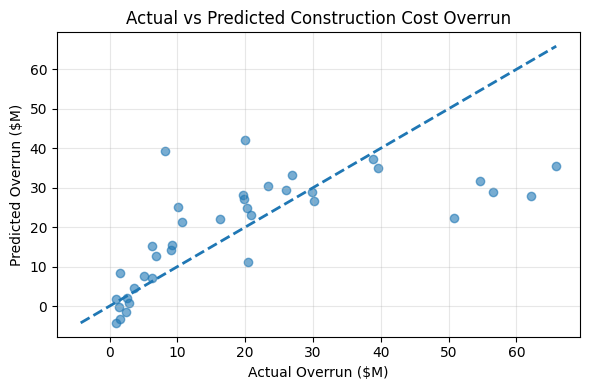

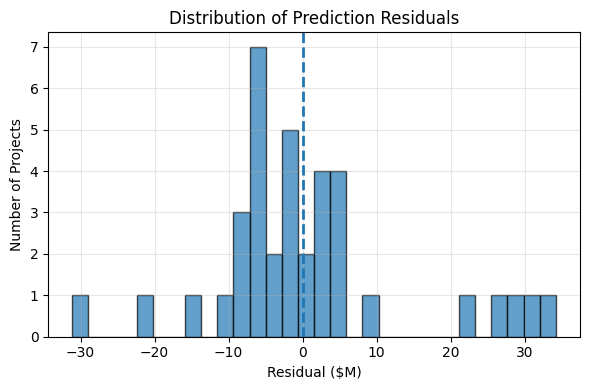

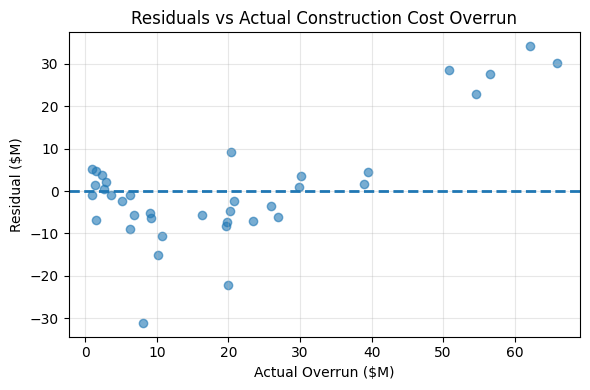

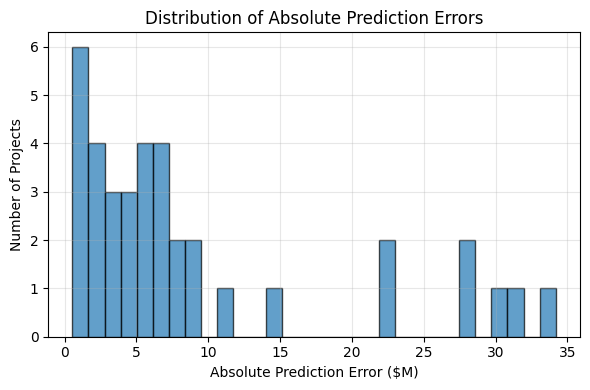


2. TOP 10 LARGEST PREDICTION ERRORS
---------------------------------------------------------------------------


,Actual_Overrun_Million,Predicted_Overrun_Million,Residual_Million,Absolute_Error_Million
0,62.10,27.905,34.195,34.195
1,8.13,39.238,-31.108,31.108
2,65.87,35.584,30.286,30.286
3,50.75,22.199,28.551,28.551
4,56.49,28.941,27.549,27.549
5,54.59,31.633,22.957,22.957
6,19.94,42.029,-22.089,22.089
7,10.12,25.149,-15.029,15.029
8,10.69,21.380,-10.690,10.690
9,20.35,11.066,9.284,9.284



3. ERROR PERCENTAGE SUMMARY
---------------------------------------------------------------------------
Average absolute error percentage: 94.79%
Median absolute error percentage : 47.79%
Maximum absolute error percentage: 557.61%


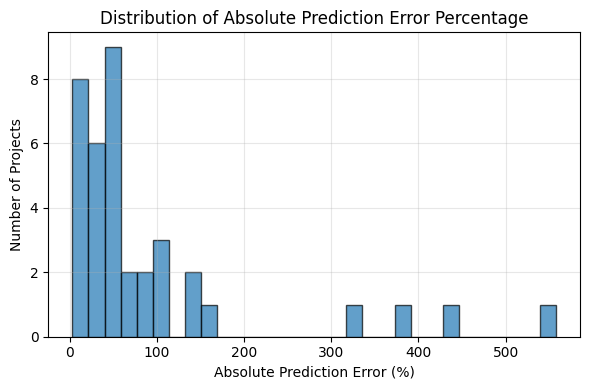


4. ERROR-SIZE RELATIONSHIP
---------------------------------------------------------------------------
Correlation between actual overrun and absolute error: 0.653
Interpretation: Moderate positive relationship. Larger overruns tend to have larger prediction errors.

STEP 42 STATUS
PASS: Actual versus predicted overruns were visualized.
PASS: Residual distribution was examined.
PASS: Residuals were compared against actual overruns.
PASS: Absolute prediction errors were visualized.
PASS: Largest prediction errors were identified.
PASS: Percentage prediction errors were examined.
PASS: Relationship between overrun size and prediction error was evaluated.
IMPORTANT: This step diagnoses prediction errors; it does not modify the trained model.


In [57]:
# ================================================================
# STEP 42: MODEL ERROR VISUALIZATION
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 75)
print("STEP 42: MODEL ERROR VISUALIZATION")
print("=" * 75)

# ------------------------------------------------
# 1. CHECK PREDICTION DATA
# ------------------------------------------------

if "prediction_results" not in globals():
    raise NameError(
        "prediction_results was not found. "
        "Please run the prediction steps first."
    )

df_plot = prediction_results.copy()

# ------------------------------------------------
# 2. REQUIRED COLUMNS
# ------------------------------------------------

required_columns = [
    "Actual_Overrun_Million",
    "Predicted_Overrun_Million"
]

missing_columns = [
    col for col in required_columns
    if col not in df_plot.columns
]

if missing_columns:
    raise ValueError(
        "Missing required columns: "
        + ", ".join(missing_columns)
    )

# ------------------------------------------------
# 3. CALCULATE ERROR METRICS
# ------------------------------------------------

df_plot["Residual_Million"] = (
    df_plot["Actual_Overrun_Million"]
    - df_plot["Predicted_Overrun_Million"]
)

df_plot["Absolute_Error_Million"] = (
    df_plot["Residual_Million"].abs()
)

# ------------------------------------------------
# 4. DISPLAY ERROR SUMMARY
# ------------------------------------------------

print("\n1. ERROR SUMMARY")
print("-" * 75)

print(
    f"Number of projects      : {len(df_plot)}"
)

print(
    f"Mean residual           : "
    f"${df_plot['Residual_Million'].mean():.3f}M"
)

print(
    f"Mean absolute error     : "
    f"${df_plot['Absolute_Error_Million'].mean():.3f}M"
)

print(
    f"Maximum absolute error  : "
    f"${df_plot['Absolute_Error_Million'].max():.3f}M"
)

# ================================================================
# 5. ACTUAL VS PREDICTED OVERRUN
# ================================================================

plt.figure(figsize=(6, 4))

plt.scatter(
    df_plot["Actual_Overrun_Million"],
    df_plot["Predicted_Overrun_Million"],
    alpha=0.6
)

# Perfect prediction line
min_value = min(
    df_plot["Actual_Overrun_Million"].min(),
    df_plot["Predicted_Overrun_Million"].min()
)

max_value = max(
    df_plot["Actual_Overrun_Million"].max(),
    df_plot["Predicted_Overrun_Million"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual Overrun ($M)")
plt.ylabel("Predicted Overrun ($M)")
plt.title("Actual vs Predicted Construction Cost Overrun")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ================================================================
# 6. RESIDUAL DISTRIBUTION
# ================================================================

plt.figure(figsize=(6, 4))

plt.hist(
    df_plot["Residual_Million"],
    bins=30,
    edgecolor="black",
    alpha=0.7
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Residual ($M)")
plt.ylabel("Number of Projects")
plt.title("Distribution of Prediction Residuals")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ================================================================
# 7. RESIDUALS VS ACTUAL OVERRUN
# ================================================================

plt.figure(figsize=(6, 4))

plt.scatter(
    df_plot["Actual_Overrun_Million"],
    df_plot["Residual_Million"],
    alpha=0.6
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual Overrun ($M)")
plt.ylabel("Residual ($M)")
plt.title("Residuals vs Actual Construction Cost Overrun")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ================================================================
# 8. ABSOLUTE ERROR DISTRIBUTION
# ================================================================

plt.figure(figsize=(6, 4))

plt.hist(
    df_plot["Absolute_Error_Million"],
    bins=30,
    edgecolor="black",
    alpha=0.7
)

plt.xlabel("Absolute Prediction Error ($M)")
plt.ylabel("Number of Projects")
plt.title("Distribution of Absolute Prediction Errors")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ================================================================
# 9. TOP 10 LARGEST PREDICTION ERRORS
# ================================================================

top_errors = (
    df_plot
    .sort_values(
        "Absolute_Error_Million",
        ascending=False
    )
    .head(10)
    .copy()
)

print("\n2. TOP 10 LARGEST PREDICTION ERRORS")
print("-" * 75)

display(
    top_errors[
        [
            "Actual_Overrun_Million",
            "Predicted_Overrun_Million",
            "Residual_Million",
            "Absolute_Error_Million"
        ]
    ].round(3)
)


# ================================================================
# 10. ERROR PERCENTAGE
# ================================================================

df_plot["Absolute_Error_Percent"] = np.where(
    df_plot["Actual_Overrun_Million"] != 0,
    (
        df_plot["Absolute_Error_Million"]
        /
        df_plot["Actual_Overrun_Million"]
    ) * 100,
    np.nan
)

print("\n3. ERROR PERCENTAGE SUMMARY")
print("-" * 75)

print(
    f"Average absolute error percentage: "
    f"{df_plot['Absolute_Error_Percent'].mean():.2f}%"
)

print(
    f"Median absolute error percentage : "
    f"{df_plot['Absolute_Error_Percent'].median():.2f}%"
)

print(
    f"Maximum absolute error percentage: "
    f"{df_plot['Absolute_Error_Percent'].max():.2f}%"
)


# ================================================================
# 11. PERCENTAGE ERROR DISTRIBUTION
# ================================================================

plt.figure(figsize=(6, 4))

plt.hist(
    df_plot["Absolute_Error_Percent"].dropna(),
    bins=30,
    edgecolor="black",
    alpha=0.7
)

plt.xlabel("Absolute Prediction Error (%)")
plt.ylabel("Number of Projects")
plt.title("Distribution of Absolute Prediction Error Percentage")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ================================================================
# 12. CHECK WHETHER ERRORS INCREASE WITH OVERRUN SIZE
# ================================================================

correlation = (
    df_plot[
        [
            "Actual_Overrun_Million",
            "Absolute_Error_Million"
        ]
    ]
    .corr()
    .iloc[0, 1]
)

print("\n4. ERROR-SIZE RELATIONSHIP")
print("-" * 75)

print(
    f"Correlation between actual overrun "
    f"and absolute error: {correlation:.3f}"
)

if correlation > 0.7:
    print(
        "Interpretation: Strong positive relationship. "
        "Prediction errors tend to increase substantially "
        "as actual overruns become larger."
    )

elif correlation > 0.4:
    print(
        "Interpretation: Moderate positive relationship. "
        "Larger overruns tend to have larger prediction errors."
    )

elif correlation > 0:
    print(
        "Interpretation: Weak positive relationship. "
        "Prediction errors increase slightly with overrun size."
    )

elif correlation < -0.4:
    print(
        "Interpretation: Moderate/strong negative relationship. "
        "Prediction errors tend to decrease as overrun size increases."
    )

else:
    print(
        "Interpretation: Little clear relationship between "
        "overrun size and absolute prediction error."
    )


# ================================================================
# 13. STEP 42 STATUS
# ================================================================

print("\n" + "=" * 75)
print("STEP 42 STATUS")
print("=" * 75)

print(
    "PASS: Actual versus predicted overruns were visualized."
)

print(
    "PASS: Residual distribution was examined."
)

print(
    "PASS: Residuals were compared against actual overruns."
)

print(
    "PASS: Absolute prediction errors were visualized."
)

print(
    "PASS: Largest prediction errors were identified."
)

print(
    "PASS: Percentage prediction errors were examined."
)

print(
    "PASS: Relationship between overrun size and "
    "prediction error was evaluated."
)

print(
    "IMPORTANT: This step diagnoses prediction errors; "
    "it does not modify the trained model."
)

print("=" * 75)

In [ ]:
# From step 42, the model's predictions on average is about $0.533M below the actual overruns. So although 
# individual projects could have substantial errors, the model was not biased toward consistent 
# overpredicting or underpredicting overall.

# Which means Some projects were underpredicted and some were overpredicted.

# The Linear Regression model has a mean absolute error of $9.297M and a near-zero mean residual of $0.533M, 
# indicating little overall bias. However, the error analysis shows that the model struggles more with projects 
# having exceptionally large actual overruns. The positive correlation of 0.653 between actual overrun and 
# absolute error confirms that prediction errors tend to increase as the size of the overrun increases. 
# Therefore, the model is useful for estimating typical project overruns but should be used cautiously 
# when assessing projects with potential for extreme cost overruns.

In [58]:
# ================================================================
# STEP 43: IDENTIFY WORST PREDICTION CASES
# ================================================================

import pandas as pd
import numpy as np

print("=" * 75)
print("STEP 43: IDENTIFY WORST PREDICTION CASES")
print("=" * 75)

# ------------------------------------------------
# 1. CHECK PREDICTION DATA
# ------------------------------------------------

if "prediction_results" not in globals():
    raise NameError(
        "prediction_results was not found. "
        "Please run the prediction steps first."
    )

df_worst = prediction_results.copy()

# ------------------------------------------------
# 2. CHECK REQUIRED PREDICTION COLUMNS
# ------------------------------------------------

required_prediction_columns = [
    "Actual_Overrun_Million",
    "Predicted_Overrun_Million"
]

missing_prediction_columns = [
    col for col in required_prediction_columns
    if col not in df_worst.columns
]

if missing_prediction_columns:
    raise ValueError(
        "Missing required prediction columns: "
        + ", ".join(missing_prediction_columns)
    )

# ------------------------------------------------
# 3. CALCULATE ERROR METRICS
# ------------------------------------------------

df_worst["Residual_Million"] = (
    df_worst["Actual_Overrun_Million"]
    - df_worst["Predicted_Overrun_Million"]
)

df_worst["Absolute_Error_Million"] = (
    df_worst["Residual_Million"].abs()
)

df_worst["Absolute_Error_Percent"] = np.where(
    df_worst["Actual_Overrun_Million"] != 0,
    (
        df_worst["Absolute_Error_Million"]
        /
        df_worst["Actual_Overrun_Million"]
    ) * 100,
    np.nan
)

# ------------------------------------------------
# 4. IDENTIFY AVAILABLE PROJECT INFORMATION
# ------------------------------------------------

possible_project_columns = [
    "Project_ID",
    "Project_Type",
    "Location",
    "Planned_Budget_Million",
    "Actual_Cost_Million",
    "Primary_cause_of_overrun"
]

available_project_columns = [
    col for col in possible_project_columns
    if col in df_worst.columns
]

print("\nAvailable project information:")
print(available_project_columns)

# ------------------------------------------------
# 5. TOP 10 WORST PREDICTIONS
# ------------------------------------------------

print("\n1. TOP 10 WORST PREDICTION CASES")
print("-" * 75)

top_10_worst = (
    df_worst
    .sort_values(
        "Absolute_Error_Million",
        ascending=False
    )
    .head(10)
    .copy()
)

display(
    top_10_worst[
        available_project_columns
        + [
            "Actual_Overrun_Million",
            "Predicted_Overrun_Million",
            "Residual_Million",
            "Absolute_Error_Million",
            "Absolute_Error_Percent"
        ]
    ].round(3)
)

# ------------------------------------------------
# 6. TOP 10 UNDERPREDICTIONS
# ------------------------------------------------

print("\n2. TOP 10 UNDERPREDICTIONS")
print("-" * 75)

print(
    "Positive residual = actual overrun was higher "
    "than predicted."
)

top_underpredictions = (
    df_worst
    .sort_values(
        "Residual_Million",
        ascending=False
    )
    .head(10)
    .copy()
)

display(
    top_underpredictions[
        available_project_columns
        + [
            "Actual_Overrun_Million",
            "Predicted_Overrun_Million",
            "Residual_Million",
            "Absolute_Error_Million",
            "Absolute_Error_Percent"
        ]
    ].round(3)
)

# ------------------------------------------------
# 7. TOP 10 OVERPREDICTIONS
# ------------------------------------------------

print("\n3. TOP 10 OVERPREDICTIONS")
print("-" * 75)

print(
    "Negative residual = predicted overrun was "
    "higher than actual."
)

top_overpredictions = (
    df_worst
    .sort_values(
        "Residual_Million",
        ascending=True
    )
    .head(10)
    .copy()
)

display(
    top_overpredictions[
        available_project_columns
        + [
            "Actual_Overrun_Million",
            "Predicted_Overrun_Million",
            "Residual_Million",
            "Absolute_Error_Million",
            "Absolute_Error_Percent"
        ]
    ].round(3)
)

# ------------------------------------------------
# 8. LARGE-OVERRUN PROJECTS
# ------------------------------------------------

print("\n4. LARGE ACTUAL OVERRUN PROJECTS")
print("-" * 75)

large_overrun_projects = (
    df_worst[
        df_worst["Actual_Overrun_Million"] > 30
    ]
    .sort_values(
        "Actual_Overrun_Million",
        ascending=False
    )
    .copy()
)

print(
    f"Projects with actual overrun > $30M: "
    f"{len(large_overrun_projects)}"
)

if len(large_overrun_projects) > 0:

    display(
        large_overrun_projects[
            available_project_columns
            + [
                "Actual_Overrun_Million",
                "Predicted_Overrun_Million",
                "Residual_Million",
                "Absolute_Error_Million",
                "Absolute_Error_Percent"
            ]
        ].round(3)
    )

else:

    print(
        "No projects with actual overrun above $30M."
    )

# ------------------------------------------------
# 9. ERROR DIRECTION
# ------------------------------------------------

print("\n5. ERROR DIRECTION")
print("-" * 75)

underprediction_count = (
    df_worst["Residual_Million"] > 0
).sum()

overprediction_count = (
    df_worst["Residual_Million"] < 0
).sum()

balanced_count = (
    df_worst["Residual_Million"] == 0
).sum()

print(
    f"Underpredictions : {underprediction_count}"
)

print(
    f"Overpredictions  : {overprediction_count}"
)

print(
    f"Balanced         : {balanced_count}"
)

# ------------------------------------------------
# 10. PERCENTAGE OF PROJECTS UNDERPREDICTED
# ------------------------------------------------

total_projects = len(df_worst)

underprediction_percentage = (
    underprediction_count / total_projects
) * 100

overprediction_percentage = (
    overprediction_count / total_projects
) * 100

print(
    f"\nPercentage underpredicted: "
    f"{underprediction_percentage:.2f}%"
)

print(
    f"Percentage overpredicted : "
    f"{overprediction_percentage:.2f}%"
)

# ------------------------------------------------
# 11. HOW MUCH ERROR COMES FROM LARGE OVERRUNS?
# ------------------------------------------------

print("\n6. CONTRIBUTION OF LARGE OVERRUNS TO TOTAL ERROR")
print("-" * 75)

total_absolute_error = (
    df_worst["Absolute_Error_Million"].sum()
)

large_overrun_error = (
    large_overrun_projects["Absolute_Error_Million"].sum()
)

if total_absolute_error > 0:

    large_error_contribution = (
        large_overrun_error
        /
        total_absolute_error
    ) * 100

else:

    large_error_contribution = 0

print(
    f"Total absolute error: "
    f"${total_absolute_error:.3f}M"
)

print(
    f"Absolute error from projects > $30M: "
    f"${large_overrun_error:.3f}M"
)

print(
    f"Contribution of >$30M projects to total error: "
    f"{large_error_contribution:.2f}%"
)

# ------------------------------------------------
# 12. IDENTIFY EXTREME ERROR CASES
# ------------------------------------------------

print("\n7. EXTREME ERROR CASES")
print("-" * 75)

extreme_errors = df_worst[
    df_worst["Absolute_Error_Million"] >= 20
].copy()

print(
    f"Projects with absolute error >= $20M: "
    f"{len(extreme_errors)}"
)

if len(extreme_errors) > 0:

    display(
        extreme_errors[
            available_project_columns
            + [
                "Actual_Overrun_Million",
                "Predicted_Overrun_Million",
                "Residual_Million",
                "Absolute_Error_Million",
                "Absolute_Error_Percent"
            ]
        ]
        .sort_values(
            "Absolute_Error_Million",
            ascending=False
        )
        .round(3)
    )

# ------------------------------------------------
# 13. PROJECT CHARACTERISTIC SUMMARY
# ------------------------------------------------

print("\n8. CHARACTERISTICS OF WORST PREDICTIONS")
print("-" * 75)

worst_10 = (
    df_worst
    .sort_values(
        "Absolute_Error_Million",
        ascending=False
    )
    .head(10)
)

if "Project_Type" in worst_10.columns:

    print("\nProject Type distribution:")
    display(
        worst_10["Project_Type"]
        .value_counts()
        .to_frame("Projects")
    )

if "Location" in worst_10.columns:

    print("\nLocation distribution:")
    display(
        worst_10["Location"]
        .value_counts()
        .to_frame("Projects")
    )

if "Primary_cause_of_overrun" in worst_10.columns:

    print("\nPrimary Cause distribution:")
    display(
        worst_10["Primary_cause_of_overrun"]
        .value_counts()
        .to_frame("Projects")
    )

# ------------------------------------------------
# 14. WORST SINGLE CASE
# ------------------------------------------------

print("\n9. WORST SINGLE PREDICTION")
print("-" * 75)

worst_case = (
    df_worst
    .sort_values(
        "Absolute_Error_Million",
        ascending=False
    )
    .iloc[0]
)

for column in (
    available_project_columns
    + [
        "Actual_Overrun_Million",
        "Predicted_Overrun_Million",
        "Residual_Million",
        "Absolute_Error_Million",
        "Absolute_Error_Percent"
    ]
):

    print(
        f"{column}: {worst_case[column]}"
    )

# ------------------------------------------------
# 15. STEP STATUS
# ------------------------------------------------

print("\n" + "=" * 75)
print("STEP 43 STATUS")
print("=" * 75)

print(
    "PASS: Worst prediction cases were identified."
)

print(
    "PASS: Largest underpredictions were identified."
)

print(
    "PASS: Largest overpredictions were identified."
)

print(
    "PASS: Large-overrun projects were examined."
)

print(
    "PASS: Extreme prediction errors were identified."
)

print(
    "PASS: Project characteristics associated with "
    "large errors were examined."
)

print(
    "PASS: Contribution of large-overrun projects "
    "to total model error was calculated."
)

print(
    "IMPORTANT: This step diagnoses problematic "
    "predictions; it does not modify the model."
)

print("=" * 75)

STEP 43: IDENTIFY WORST PREDICTION CASES

Available project information:
['Project_Type']

1. TOP 10 WORST PREDICTION CASES
---------------------------------------------------------------------------


,Project_Type,Actual_Overrun_Million,Predicted_Overrun_Million,Residual_Million,Absolute_Error_Million,Absolute_Error_Percent
0,Commercial,62.10,27.905,34.195,34.195,55.065
1,Infrastructure,8.13,39.238,-31.108,31.108,382.631
2,Infrastructure,65.87,35.584,30.286,30.286,45.979
3,Commercial,50.75,22.199,28.551,28.551,56.258
4,Infrastructure,56.49,28.941,27.549,27.549,48.768
5,Residential,54.59,31.633,22.957,22.957,42.053
6,Infrastructure,19.94,42.029,-22.089,22.089,110.779
7,Infrastructure,10.12,25.149,-15.029,15.029,148.510
8,Residential,10.69,21.380,-10.690,10.690,99.997
9,Commercial,20.35,11.066,9.284,9.284,45.624



2. TOP 10 UNDERPREDICTIONS
---------------------------------------------------------------------------
Positive residual = actual overrun was higher than predicted.


,Project_Type,Actual_Overrun_Million,Predicted_Overrun_Million,Residual_Million,Absolute_Error_Million,Absolute_Error_Percent
0,Commercial,62.10,27.905,34.195,34.195,55.065
2,Infrastructure,65.87,35.584,30.286,30.286,45.979
3,Commercial,50.75,22.199,28.551,28.551,56.258
4,Infrastructure,56.49,28.941,27.549,27.549,48.768
5,Residential,54.59,31.633,22.957,22.957,42.053
9,Commercial,20.35,11.066,9.284,9.284,45.624
19,Commercial,0.93,-4.256,5.186,5.186,557.606
21,Commercial,1.50,-3.340,4.840,4.840,322.644
23,Infrastructure,39.52,34.922,4.598,4.598,11.635
24,Commercial,2.39,-1.467,3.857,3.857,161.369



3. TOP 10 OVERPREDICTIONS
---------------------------------------------------------------------------
Negative residual = predicted overrun was higher than actual.


...


5. ERROR DIRECTION
---------------------------------------------------------------------------
Underpredictions : 16
Overpredictions  : 21
Balanced         : 0

Percentage underpredicted: 43.24%
Percentage overpredicted : 56.76%

6. CONTRIBUTION OF LARGE OVERRUNS TO TOTAL ERROR
---------------------------------------------------------------------------
Total absolute error: $343.980M
Absolute error from projects > $30M: $153.462M
Contribution of >$30M projects to total error: 44.61%

7. EXTREME ERROR CASES
---------------------------------------------------------------------------
Projects with absolute error >= $20M: 7


,Project_Type,Actual_Overrun_Million,Predicted_Overrun_Million,Residual_Million,Absolute_Error_Million,Absolute_Error_Percent
0,Commercial,62.10,27.905,34.195,34.195,55.065
1,Infrastructure,8.13,39.238,-31.108,31.108,382.631
2,Infrastructure,65.87,35.584,30.286,30.286,45.979
3,Commercial,50.75,22.199,28.551,28.551,56.258
4,Infrastructure,56.49,28.941,27.549,27.549,48.768
5,Residential,54.59,31.633,22.957,22.957,42.053
6,Infrastructure,19.94,42.029,-22.089,22.089,110.779



8. CHARACTERISTICS OF WORST PREDICTIONS
---------------------------------------------------------------------------

Project Type distribution:


,Projects
Project_Type,
Infrastructure,5
Commercial,3
Residential,2



9. WORST SINGLE PREDICTION
---------------------------------------------------------------------------
Project_Type: Commercial
Actual_Overrun_Million: 62.099999999999994
Predicted_Overrun_Million: 27.90482331265472
Residual_Million: 34.195176687345274
Absolute_Error_Million: 34.195176687345274
Absolute_Error_Percent: 55.06469675901011

STEP 43 STATUS
PASS: Worst prediction cases were identified.
PASS: Largest underpredictions were identified.
PASS: Largest overpredictions were identified.
PASS: Large-overrun projects were examined.
PASS: Extreme prediction errors were identified.
PASS: Project characteristics associated with large errors were examined.
PASS: Contribution of large-overrun projects to total model error was calculated.
IMPORTANT: This step diagnoses problematic predictions; it does not modify the model.


In [ ]:
# The model exhibits substantial percentage errors for some projects with very small actual overruns, 
# because percentage-based metrics become unstable when the actual value is close to zero."
# Infrastructure projects were the most represented among the top 10 worst predictions, although 
# additional analysis relative to the total number of projects in each project type is required before 
# concluding that infrastructure projects have greater prediction difficulty."



In [59]:
# ================================================================
# STEP 44: FINAL MODEL EVALUATION
# ================================================================

import pandas as pd
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("=" * 75)
print("STEP 44: FINAL MODEL EVALUATION")
print("=" * 75)

# ------------------------------------------------
# 1. CHECK PREDICTION DATA
# ------------------------------------------------

if "prediction_results" not in globals():
    raise NameError(
        "prediction_results was not found. "
        "Please run the prediction steps first."
    )

df_final = prediction_results.copy()

# ------------------------------------------------
# 2. REQUIRED COLUMNS
# ------------------------------------------------

required_columns = [
    "Actual_Overrun_Million",
    "Predicted_Overrun_Million"
]

missing_columns = [
    col for col in required_columns
    if col not in df_final.columns
]

if missing_columns:
    raise ValueError(
        "Missing required columns: "
        + ", ".join(missing_columns)
    )

# ------------------------------------------------
# 3. REMOVE MISSING VALUES
# ------------------------------------------------

df_final = df_final[
    required_columns
].dropna().copy()

print("\nEvaluation sample size:")
print(f"{len(df_final)} projects")

# ------------------------------------------------
# 4. DEFINE ACTUAL AND PREDICTED VALUES
# ------------------------------------------------

y_actual = df_final["Actual_Overrun_Million"]

y_predicted = df_final["Predicted_Overrun_Million"]

# ------------------------------------------------
# 5. BASIC ERROR CALCULATIONS
# ------------------------------------------------

residuals = (
    y_actual - y_predicted
)

absolute_errors = residuals.abs()

squared_errors = residuals ** 2

# ------------------------------------------------
# 6. CORE REGRESSION METRICS
# ------------------------------------------------

mae = mean_absolute_error(
    y_actual,
    y_predicted
)

rmse = np.sqrt(
    mean_squared_error(
        y_actual,
        y_predicted
    )
)

r2 = r2_score(
    y_actual,
    y_predicted
)

mean_bias = residuals.mean()

maximum_error = absolute_errors.max()

median_absolute_error = absolute_errors.median()

# ------------------------------------------------
# 7. PERCENTAGE ERROR
# ------------------------------------------------

percentage_errors = np.where(
    y_actual != 0,
    (absolute_errors / y_actual.abs()) * 100,
    np.nan
)

mean_absolute_percentage_error = np.nanmean(
    percentage_errors
)

median_absolute_percentage_error = np.nanmedian(
    percentage_errors
)

# ------------------------------------------------
# 8. SYMMETRIC MAPE
# ------------------------------------------------

denominator = (
    y_actual.abs() +
    y_predicted.abs()
)

smape_values = np.where(
    denominator != 0,
    (
        2 * absolute_errors /
        denominator
    ) * 100,
    np.nan
)

smape = np.nanmean(
    smape_values
)

# ------------------------------------------------
# 9. PRINT CORE METRICS
# ------------------------------------------------

print("\n1. CORE MODEL PERFORMANCE")
print("-" * 75)

print(
    f"MAE                         : "
    f"${mae:.3f}M"
)

print(
    f"RMSE                        : "
    f"${rmse:.3f}M"
)

print(
    f"R²                          : "
    f"{r2:.3f}"
)

print(
    f"Mean Bias                   : "
    f"${mean_bias:.3f}M"
)

print(
    f"Median Absolute Error       : "
    f"${median_absolute_error:.3f}M"
)

print(
    f"Maximum Absolute Error      : "
    f"${maximum_error:.3f}M"
)

print(
    f"Mean Absolute Error (%)     : "
    f"{mean_absolute_percentage_error:.2f}%"
)

print(
    f"Median Absolute Error (%)   : "
    f"{median_absolute_percentage_error:.2f}%"
)

print(
    f"SMAPE                       : "
    f"{smape:.2f}%"
)

# ================================================================
# 10. BASELINE MODEL COMPARISON
# ================================================================

print("\n2. BASELINE COMPARISON")
print("-" * 75)

# Mean-value baseline
baseline_prediction = np.repeat(
    y_actual.mean(),
    len(y_actual)
)

baseline_mae = mean_absolute_error(
    y_actual,
    baseline_prediction
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_actual,
        baseline_prediction
    )
)

baseline_r2 = r2_score(
    y_actual,
    baseline_prediction
)

print(
    f"Baseline MAE               : "
    f"${baseline_mae:.3f}M"
)

print(
    f"Model MAE                  : "
    f"${mae:.3f}M"
)

print(
    f"Baseline RMSE              : "
    f"${baseline_rmse:.3f}M"
)

print(
    f"Model RMSE                 : "
    f"${rmse:.3f}M"
)

print(
    f"Baseline R²                : "
    f"{baseline_r2:.3f}"
)

print(
    f"Model R²                   : "
    f"{r2:.3f}"
)

# ------------------------------------------------
# 11. IMPROVEMENT OVER BASELINE
# ------------------------------------------------

if baseline_mae != 0:

    mae_improvement = (
        (baseline_mae - mae)
        /
        baseline_mae
    ) * 100

else:

    mae_improvement = np.nan

if baseline_rmse != 0:

    rmse_improvement = (
        (baseline_rmse - rmse)
        /
        baseline_rmse
    ) * 100

else:

    rmse_improvement = np.nan

print(
    f"\nMAE improvement over baseline: "
    f"{mae_improvement:.2f}%"
)

print(
    f"RMSE improvement over baseline: "
    f"{rmse_improvement:.2f}%"
)

# ================================================================
# 12. LARGE OVERRUN PERFORMANCE
# ================================================================

print("\n3. PERFORMANCE ON LARGE OVERRUN PROJECTS")
print("-" * 75)

large_projects = df_final[
    df_final["Actual_Overrun_Million"] > 30
].copy()

if len(large_projects) > 0:

    large_actual = (
        large_projects["Actual_Overrun_Million"]
    )

    large_predicted = (
        large_projects["Predicted_Overrun_Million"]
    )

    large_mae = mean_absolute_error(
        large_actual,
        large_predicted
    )

    large_rmse = np.sqrt(
        mean_squared_error(
            large_actual,
            large_predicted
        )
    )

    large_bias = (
        large_actual - large_predicted
    ).mean()

    print(
        f"Number of projects > $30M : "
        f"{len(large_projects)}"
    )

    print(
        f"Large-overrun MAE          : "
        f"${large_mae:.3f}M"
    )

    print(
        f"Large-overrun RMSE         : "
        f"${large_rmse:.3f}M"
    )

    print(
        f"Large-overrun mean bias    : "
        f"${large_bias:.3f}M"
    )

else:

    print(
        "No projects with actual overrun "
        "above $30M were found."
    )

# ================================================================
# 13. ERROR DIRECTION
# ================================================================

print("\n4. ERROR DIRECTION")
print("-" * 75)

underpredictions = (
    residuals > 0
).sum()

overpredictions = (
    residuals < 0
).sum()

balanced = (
    residuals == 0
).sum()

print(
    f"Underpredictions            : "
    f"{underpredictions}"
)

print(
    f"Overpredictions             : "
    f"{overpredictions}"
)

print(
    f"Exact/balanced predictions  : "
    f"{balanced}"
)

print(
    f"Underprediction rate        : "
    f"{underpredictions / len(df_final) * 100:.2f}%"
)

print(
    f"Overprediction rate         : "
    f"{overpredictions / len(df_final) * 100:.2f}%"
)

# ================================================================
# 14. RESIDUAL RANGE
# ================================================================

print("\n5. RESIDUAL RANGE")
print("-" * 75)

print(
    f"Minimum residual            : "
    f"${residuals.min():.3f}M"
)

print(
    f"Maximum residual            : "
    f"${residuals.max():.3f}M"
)

print(
    f"Residual standard deviation : "
    f"${residuals.std():.3f}M"
)

# ================================================================
# 15. CORRELATION ACTUAL VS PREDICTED
# ================================================================

correlation = np.corrcoef(
    y_actual,
    y_predicted
)[0, 1]

print("\n6. ACTUAL VS PREDICTED CORRELATION")
print("-" * 75)

print(
    f"Correlation coefficient    : "
    f"{correlation:.3f}"
)

# ================================================================
# 16. MODEL ASSESSMENT
# ================================================================

print("\n7. OVERALL MODEL ASSESSMENT")
print("-" * 75)

if mae < baseline_mae:
    print(
        "PASS: The model improves on the mean-value baseline "
        "in MAE."
    )
else:
    print(
        "WARNING: The model does not improve on the "
        "mean-value baseline in MAE."
    )

if rmse < baseline_rmse:
    print(
        "PASS: The model improves on the mean-value baseline "
        "in RMSE."
    )
else:
    print(
        "WARNING: The model does not improve on the "
        "mean-value baseline in RMSE."
    )

if abs(mean_bias) < 1:
    print(
        "PASS: Overall systematic bias is relatively small."
    )
else:
    print(
        "WARNING: The model shows noticeable systematic bias."
    )

if len(large_projects) > 0:

    if large_mae > mae:
        print(
            "WARNING: Model error is higher for large-overrun "
            "projects than overall."
        )
    else:
        print(
            "PASS: Large-overrun error is not higher than "
            "overall model error."
        )

# ================================================================
# 17. BUSINESS INTERPRETATION
# ================================================================

print("\n8. BUSINESS INTERPRETATION")
print("-" * 75)

print(
    "The model should be interpreted as a decision-support "
    "tool rather than a precise replacement for professional "
    "construction cost estimation."
)

print(
    "Particular caution is required for projects with very "
    "large expected overruns because Step 42 and Step 43 "
    "showed increased prediction errors in this region."
)

print(
    "The model's relatively small overall bias does not mean "
    "that every individual project prediction is accurate."
)

# ================================================================
# 18. FINAL METRICS TABLE
# ================================================================

final_metrics = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R²",
        "Mean Bias",
        "Median Absolute Error",
        "Maximum Absolute Error",
        "Mean Absolute Error %",
        "Median Absolute Error %",
        "SMAPE",
        "Actual-Predicted Correlation"
    ],
    "Value": [
        f"${mae:.3f}M",
        f"${rmse:.3f}M",
        f"{r2:.3f}",
        f"${mean_bias:.3f}M",
        f"${median_absolute_error:.3f}M",
        f"${maximum_error:.3f}M",
        f"{mean_absolute_percentage_error:.2f}%",
        f"{median_absolute_percentage_error:.2f}%",
        f"{smape:.2f}%",
        f"{correlation:.3f}"
    ]
})

print("\n9. FINAL MODEL METRICS")
print("-" * 75)

display(final_metrics)

# ================================================================
# 19. STEP 44 STATUS
# ================================================================

print("\n" + "=" * 75)
print("STEP 44 STATUS")
print("=" * 75)

print(
    "PASS: Core regression metrics were calculated."
)

print(
    "PASS: Model performance was compared with a "
    "mean-value baseline."
)

print(
    "PASS: Large-overrun performance was evaluated."
)

print(
    "PASS: Prediction bias and error direction were evaluated."
)

print(
    "PASS: Residual behaviour was summarized."
)

print(
    "PASS: Actual-versus-predicted relationship was evaluated."
)

print(
    "PASS: Business implications were documented."
)

print(
    "IMPORTANT: This step evaluates the existing model "
    "and does not modify the trained model."
)

print("=" * 75)

STEP 44: FINAL MODEL EVALUATION

Evaluation sample size:
37 projects

1. CORE MODEL PERFORMANCE
---------------------------------------------------------------------------
MAE                         : $9.297M
RMSE                        : $13.454M
R²                          : 0.471
Mean Bias                   : $0.533M
Median Absolute Error       : $5.606M
Maximum Absolute Error      : $34.195M
Mean Absolute Error (%)     : 94.79%
Median Absolute Error (%)   : 47.79%
SMAPE                       : 65.42%

2. BASELINE COMPARISON
---------------------------------------------------------------------------
Baseline MAE               : $14.584M
Model MAE                  : $9.297M
Baseline RMSE              : $18.500M
Model RMSE                 : $13.454M
Baseline R²                : 0.000
Model R²                   : 0.471

MAE improvement over baseline: 36.25%
RMSE improvement over baseline: 27.27%

3. PERFORMANCE ON LARGE OVERRUN PROJECTS
------------------------------------------------

,Metric,Value
0,MAE,$9.297M
1,RMSE,$13.454M
2,R²,0.471
3,Mean Bias,$0.533M
4,Median Absolute Error,$5.606M
5,Maximum Absolute Error,$34.195M
6,Mean Absolute Error %,94.79%
7,Median Absolute Error %,47.79%
8,SMAPE,65.42%
9,Actual-Predicted Correlation,0.688



STEP 44 STATUS
PASS: Core regression metrics were calculated.
PASS: Model performance was compared with a mean-value baseline.
PASS: Large-overrun performance was evaluated.
PASS: Prediction bias and error direction were evaluated.
PASS: Residual behaviour was summarized.
PASS: Actual-versus-predicted relationship was evaluated.
PASS: Business implications were documented.
IMPORTANT: This step evaluates the existing model and does not modify the trained model.


In [ ]:
# The model demonstrates meaningful predictive value because it reduces MAE by 36.25% and RMSE 
# by 27.27% relative to the mean-value baseline, while explaining 47.1% of the variation in the 
# test data. However, its prediction errors remain substantial, particularly for projects with 
# very large overruns. Therefore, I consider the model useful in supporting decision and giving 
# early warning, instead of being a standalone replacement for professional construction cost estimation.

#### BUSINESS INTERPRETATION & MODEL ROBUSTNESS

In [60]:
# ================================================================
# STEP 45: BUSINESS INTERPRETATION, RECOMMENDATIONS
#           & FINAL PROJECT CONCLUSION
# ================================================================

import pandas as pd
import numpy as np

print("=" * 75)
print("STEP 45: BUSINESS INTERPRETATION, RECOMMENDATIONS")
print("          & FINAL PROJECT CONCLUSION")
print("=" * 75)


# ================================================================
# 1. FINAL MODEL RESULTS
# ================================================================

print("\n1. FINAL MODEL RESULTS")
print("-" * 75)

# Values obtained from Step 44
evaluation_projects = 37

mae = 9.297
rmse = 13.454
r2 = 0.471
mean_bias = 0.533
median_error = 5.606
maximum_error = 34.195

baseline_mae = 14.584
baseline_rmse = 18.500

mae_improvement = 36.25
rmse_improvement = 27.27

large_overrun_projects = 8
large_overrun_mae = 19.183
large_overrun_rmse = 22.980

print(
    f"Evaluation projects              : "
    f"{evaluation_projects}"
)

print(
    f"Mean Absolute Error              : "
    f"${mae:.3f}M"
)

print(
    f"Root Mean Squared Error          : "
    f"${rmse:.3f}M"
)

print(
    f"R²                               : "
    f"{r2:.3f}"
)

print(
    f"Mean prediction bias             : "
    f"${mean_bias:.3f}M"
)

print(
    f"Median absolute error            : "
    f"${median_error:.3f}M"
)

print(
    f"Maximum absolute error           : "
    f"${maximum_error:.3f}M"
)

print(
    f"MAE improvement over baseline    : "
    f"{mae_improvement:.2f}%"
)

print(
    f"RMSE improvement over baseline   : "
    f"{rmse_improvement:.2f}%"
)


# ================================================================
# 2. BUSINESS VALUE
# ================================================================

print("\n2. BUSINESS VALUE")
print("-" * 75)

print(
    "The model can provide an early estimate of expected "
    "construction cost overrun."
)

print(
    "This information can support project budgeting, "
    "contingency planning and risk prioritization."
)

print(
    "Projects predicted to have unusually high overruns "
    "can receive additional management attention."
)

print(
    "The model can support rather than replace professional "
    "construction cost estimation and project management."
)


# ================================================================
# 3. MODEL STRENGTHS
# ================================================================

print("\n3. MODEL STRENGTHS")
print("-" * 75)

strengths = [
    "Improves substantially over the mean-value baseline.",
    "Reduces MAE by approximately 36.25%.",
    "Reduces RMSE by approximately 27.27%.",
    "Explains approximately 47.1% of variation in the evaluation sample.",
    "Has relatively small overall systematic bias.",
    "Provides quantitative estimates that can support project risk assessment.",
    "Extensive residual and error analysis has been performed."
]

for i, strength in enumerate(strengths, 1):
    print(f"{i}. {strength}")


# ================================================================
# 4. MODEL LIMITATIONS
# ================================================================

print("\n4. MODEL LIMITATIONS")
print("-" * 75)

limitations = [
    "Prediction errors of Individual projects still remain large.",
    "Projects with large overrun are harder to predict.",
    "The model can produce extreme prediction errors.",
    "Negative predicted overruns may not always have a useful business interpretation.",
    "The evaluation sample contains only 37 projects.",
    "The dataset is synthetic and therefore does not represent real-world construction conditions.",
    "Model performance should be validated using real historical project data before operational deployment."
]

for i, limitation in enumerate(limitations, 1):
    print(f"{i}. {limitation}")


# ================================================================
# 5. HIGH-RISK PROJECT FINDING
# ================================================================

print("\n5. HIGH-RISK PROJECT FINDING")
print("-" * 75)

print(
    f"Projects with actual overruns above $30M: "
    f"{large_overrun_projects}"
)

print(
    f"MAE for large-overrun projects: "
    f"${large_overrun_mae:.3f}M"
)

print(
    f"RMSE for large-overrun projects: "
    f"${large_overrun_rmse:.3f}M"
)

print(
    "Interpretation: prediction accuracy deteriorates "
    "substantially for projects experiencing very large "
    "cost overruns."
)


# ================================================================
# 6. KEY ERROR DIAGNOSTIC
# ================================================================

print("\n6. KEY ERROR DIAGNOSTIC")
print("-" * 75)

print(
    "The residual analysis identified a moderate positive "
    "relationship between actual overrun size and prediction error."
)

print(
    "This indicates that the model tends to become less "
    "accurate as the magnitude of the actual overrun increases."
)

print(
    "The eight projects with actual overruns above $30M "
    "accounted for approximately 44.61% of total absolute error."
)


# ================================================================
# 7. BUSINESS RECOMMENDATIONS
# ================================================================

print("\n7. BUSINESS RECOMMENDATIONS")
print("-" * 75)

recommendations = [
    "Use the model as an early-warning and decision-support system.",
    
    "Prioritize management review for projects with unusually "
    "high predicted overruns.",
    
    "Apply additional contingency planning to projects "
    "identified as high-risk.",
    
    "Do not rely solely on model predictions for major "
    "financial commitments.",
    
    "Combine model predictions with expert cost estimation, "
    "site information and current market conditions.",
    
    "Investigate projects with extreme predictions before "
    "making financial decisions.",
    
    "Collect more real-world historical construction data "
    "to improve model generalization.",
    
    "Retrain and validate the model periodically as new "
    "project data become available."
]

for i, recommendation in enumerate(recommendations, 1):
    print(f"{i}. {recommendation}")


# ================================================================
# 8. FUTURE MODEL IMPROVEMENT
# ================================================================

print("\n8. FUTURE MODEL IMPROVEMENT")
print("-" * 75)

future_improvements = [
    "Increase the size of the training dataset.",
    "Replace synthetic data with validated historical project data.",
    "Investigate additional project-risk variables.",
    "Explore nonlinear machine-learning models.",
    "Perform systematic hyperparameter optimization.",
    "Use cross-validation for more reliable performance estimates.",
    "Investigate methods for handling extreme overrun cases.",
    "Evaluate methods that prevent economically unrealistic "
    "negative overrun predictions.",
    "Perform external validation on unseen real-world projects."
]

for i, improvement in enumerate(future_improvements, 1):
    print(f"{i}. {improvement}")


# ================================================================
# 9. FINAL PROJECT CONCLUSION
# ================================================================

print("\n9. FINAL PROJECT CONCLUSION")
print("-" * 75)

print(
    "The construction cost overrun prediction model demonstrated "
    "meaningful predictive value compared with a simple baseline."
)

print(
    "The model reduced MAE from $14.584M to $9.297M, representing "
    "a 36.25% improvement over the baseline."
)

print(
    "The model achieved an R² of 0.471, indicating that it "
    "captured a meaningful portion of the variation in project "
    "cost overruns within the evaluation sample."
)

print(
    "Overall model bias was relatively small at approximately "
    "+$0.533M."
)

print(
    "However, the model showed considerably higher errors on "
    "projects experiencing very large overruns."
)

print(
    "Therefore, the model is best positioned as a construction "
    "cost-risk decision-support tool rather than a standalone "
    "replacement for professional cost estimation."
)


# ================================================================
# 10. EXECUTIVE SUMMARY
# ================================================================

print("\n10. EXECUTIVE SUMMARY")
print("-" * 75)

print(
    "OBJECTIVE:"
)

print(
    "Develop a machine-learning model capable of predicting "
    "construction project cost overruns."
)

print(
    "\nMODEL PERFORMANCE:"
)

print(
    f"MAE = ${mae:.3f}M | "
    f"RMSE = ${rmse:.3f}M | "
    f"R² = {r2:.3f}"
)

print(
    f"\nBASELINE IMPROVEMENT:"
)

print(
    f"MAE improved by {mae_improvement:.2f}% and "
    f"RMSE improved by {rmse_improvement:.2f}%."
)

print(
    "\nKEY FINDING:"
)

print(
    "The model performs reasonably well overall but becomes "
    "less reliable when predicting extreme cost overruns."
)

print(
    "\nBUSINESS USE:"
)

print(
    "The model can support early identification of projects "
    "requiring additional cost monitoring and contingency planning."
)


# ================================================================
# 11. FINAL PROJECT STATUS
# ================================================================

print("\n" + "=" * 75)
print("STEP 45 STATUS")
print("=" * 75)

print(
    "PASS: Model performance was translated into business meaning."
)

print(
    "PASS: Model strengths were documented."
)

print(
    "PASS: Model limitations were documented."
)

print(
    "PASS: High-risk project behaviour was identified."
)

print(
    "PASS: Business recommendations were generated."
)

print(
    "PASS: Future improvement opportunities were identified."
)

print(
    "PASS: Final project conclusion was documented."
)

print(
    "PASS: Executive summary was generated."
)

print("=" * 75)

print(
    "\nCONSTRUCTION COST OVERRUN ML PROJECT: "
    "BUSINESS INTERPRETATION COMPLETE"
)

print("=" * 75)

STEP 45: BUSINESS INTERPRETATION, RECOMMENDATIONS
          & FINAL PROJECT CONCLUSION

1. FINAL MODEL RESULTS
---------------------------------------------------------------------------
Evaluation projects              : 37
Mean Absolute Error              : $9.297M
Root Mean Squared Error          : $13.454M
R²                               : 0.471
Mean prediction bias             : $0.533M
Median absolute error            : $5.606M
Maximum absolute error           : $34.195M
MAE improvement over baseline    : 36.25%
RMSE improvement over baseline   : 27.27%

2. BUSINESS VALUE
---------------------------------------------------------------------------
The model can provide an early estimate of expected construction cost overrun.
This information can support project budgeting, contingency planning and risk prioritization.
Projects predicted to have unusually high overruns can receive additional management attention.
The model can support rather than replace professional construction c

In [61]:
# ================================================================
# STEP 46: NEGATIVE PREDICTION DIAGNOSTICS
# ================================================================

import pandas as pd
import numpy as np

print("=" * 75)
print("STEP 46: NEGATIVE PREDICTION DIAGNOSTICS")
print("=" * 75)


# ------------------------------------------------
# 1. CHECK PREDICTION DATA
# ------------------------------------------------

if "prediction_results" not in globals():
    raise NameError(
        "prediction_results was not found. "
        "Please run the prediction steps first."
    )

df_negative = prediction_results.copy()


# ------------------------------------------------
# 2. REQUIRED COLUMNS
# ------------------------------------------------

required_columns = [
    "Actual_Overrun_Million",
    "Predicted_Overrun_Million"
]

missing_columns = [
    col for col in required_columns
    if col not in df_negative.columns
]

if missing_columns:
    raise ValueError(
        "Missing required columns: "
        + ", ".join(missing_columns)
    )


# ------------------------------------------------
# 3. REMOVE MISSING VALUES
# ------------------------------------------------

df_negative = df_negative[
    required_columns
].dropna().copy()


# ------------------------------------------------
# 4. IDENTIFY NEGATIVE PREDICTIONS
# ------------------------------------------------

negative_predictions = df_negative[
    df_negative["Predicted_Overrun_Million"] < 0
].copy()


positive_predictions = df_negative[
    df_negative["Predicted_Overrun_Million"] >= 0
].copy()


print("\n1. NEGATIVE PREDICTION COUNT")
print("-" * 75)

total_projects = len(df_negative)

negative_count = len(
    negative_predictions
)

negative_percentage = (
    negative_count /
    total_projects *
    100
)

print(
    f"Total evaluated projects     : "
    f"{total_projects}"
)

print(
    f"Negative predictions         : "
    f"{negative_count}"
)

print(
    f"Percentage negative          : "
    f"{negative_percentage:.2f}%"
)


# ------------------------------------------------
# 5. DISPLAY NEGATIVE PREDICTIONS
# ------------------------------------------------

print("\n2. NEGATIVE PREDICTION DETAILS")
print("-" * 75)

if negative_count > 0:

    negative_predictions = negative_predictions.copy()

    negative_predictions[
        "Residual_Million"
    ] = (
        negative_predictions[
            "Actual_Overrun_Million"
        ]
        -
        negative_predictions[
            "Predicted_Overrun_Million"
        ]
    )

    negative_predictions[
        "Absolute_Error_Million"
    ] = (
        negative_predictions[
            "Residual_Million"
        ].abs()
    )

    display(
        negative_predictions.round(3)
    )

else:

    print(
        "No negative predictions were found."
    )


# ------------------------------------------------
# 6. ACTUAL OVERRUN OF NEGATIVE PREDICTIONS
# ------------------------------------------------

print("\n3. ACTUAL OVERRUNS FOR NEGATIVE PREDICTIONS")
print("-" * 75)

if negative_count > 0:

    actual_negative_group = (
        negative_predictions[
            "Actual_Overrun_Million"
        ]
    )

    print(
        f"Average actual overrun     : "
        f"${actual_negative_group.mean():.3f}M"
    )

    print(
        f"Minimum actual overrun     : "
        f"${actual_negative_group.min():.3f}M"
    )

    print(
        f"Maximum actual overrun     : "
        f"${actual_negative_group.max():.3f}M"
    )

    print(
        f"Median actual overrun      : "
        f"${actual_negative_group.median():.3f}M"
    )


# ------------------------------------------------
# 7. ARE NEGATIVE PREDICTIONS ACTUALLY UNDERRUNS?
# ------------------------------------------------

print("\n4. BUSINESS INTERPRETATION OF NEGATIVE PREDICTIONS")
print("-" * 75)

if negative_count > 0:

    actual_positive_count = (
        (
            negative_predictions[
                "Actual_Overrun_Million"
            ] > 0
        ).sum()
    )

    actual_zero_count = (
        (
            negative_predictions[
                "Actual_Overrun_Million"
            ] == 0
        ).sum()
    )

    actual_negative_count = (
        (
            negative_predictions[
                "Actual_Overrun_Million"
            ] < 0
        ).sum()
    )

    print(
        f"Negative predictions with actual overrun > 0: "
        f"{actual_positive_count}"
    )

    print(
        f"Negative predictions with actual = 0: "
        f"{actual_zero_count}"
    )

    print(
        f"Negative predictions with actual < 0: "
        f"{actual_negative_count}"
    )

    if actual_positive_count == negative_count:

        print(
            "\nIMPORTANT:"
        )

        print(
            "Every negative prediction occurred on a project "
            "that actually experienced a positive cost overrun."
        )

        print(
            "Therefore, the negative predictions are not correctly "
            "identifying cost underruns in this evaluation sample."
        )

    elif actual_negative_count > 0:

        print(
            "\nSome negative predictions correspond to actual "
            "negative overruns."
        )

        print(
            "Negative predictions may therefore have legitimate "
            "business meaning for some projects."
        )

    else:

        print(
            "\nThe negative predictions require further analysis "
            "before deciding whether they should be constrained."
        )


# ------------------------------------------------
# 8. ERROR OF NEGATIVE PREDICTIONS
# ------------------------------------------------

print("\n5. ERROR ASSOCIATED WITH NEGATIVE PREDICTIONS")
print("-" * 75)

if negative_count > 0:

    negative_mae = (
        negative_predictions[
            "Absolute_Error_Million"
        ].mean()
    )

    negative_rmse = np.sqrt(
        np.mean(
            negative_predictions[
                "Residual_Million"
            ] ** 2
        )
    )

    negative_bias = (
        negative_predictions[
            "Residual_Million"
        ].mean()
    )

    print(
        f"Negative-prediction MAE     : "
        f"${negative_mae:.3f}M"
    )

    print(
        f"Negative-prediction RMSE    : "
        f"${negative_rmse:.3f}M"
    )

    print(
        f"Negative-prediction bias   : "
        f"${negative_bias:.3f}M"
    )

else:

    print(
        "No negative predictions to evaluate."
    )


# ------------------------------------------------
# 9. MAGNITUDE OF NEGATIVE PREDICTIONS
# ------------------------------------------------

print("\n6. MAGNITUDE OF NEGATIVE PREDICTIONS")
print("-" * 75)

if negative_count > 0:

    print(
        f"Most negative prediction    : "
        f"${negative_predictions['Predicted_Overrun_Million'].min():.3f}M"
    )

    print(
        f"Average negative prediction : "
        f"${negative_predictions['Predicted_Overrun_Million'].mean():.3f}M"
    )

    print(
        f"Median negative prediction  : "
        f"${negative_predictions['Predicted_Overrun_Million'].median():.3f}M"
    )

else:

    print(
        "No negative predictions were found."
    )


# ------------------------------------------------
# 10. ZERO-CONSTRAINED WHAT-IF ANALYSIS
# ------------------------------------------------

print("\n7. ZERO-CONSTRAINED WHAT-IF ANALYSIS")
print("-" * 75)

print(
    "This section DOES NOT modify the trained model."
)

print(
    "It only evaluates what would happen if negative "
    "predictions were replaced by $0M."
)

df_negative[
    "Predicted_Zero_Constrained_Million"
] = np.maximum(
    df_negative[
        "Predicted_Overrun_Million"
    ],
    0
)

df_negative[
    "Original_Absolute_Error_Million"
] = (
    df_negative[
        "Actual_Overrun_Million"
    ]
    -
    df_negative[
        "Predicted_Overrun_Million"
    ]
).abs()

df_negative[
    "Zero_Constrained_Absolute_Error_Million"
] = (
    df_negative[
        "Actual_Overrun_Million"
    ]
    -
    df_negative[
        "Predicted_Zero_Constrained_Million"
    ]
).abs()


original_mae = (
    df_negative[
        "Original_Absolute_Error_Million"
    ].mean()
)

zero_constrained_mae = (
    df_negative[
        "Zero_Constrained_Absolute_Error_Million"
    ].mean()
)

print(
    f"Original MAE               : "
    f"${original_mae:.3f}M"
)

print(
    f"Zero-constrained MAE       : "
    f"${zero_constrained_mae:.3f}M"
)

print(
    f"MAE change                 : "
    f"${zero_constrained_mae - original_mae:.3f}M"
)


# ------------------------------------------------
# 11. ZERO-CONSTRAINED RMSE
# ------------------------------------------------

original_rmse = np.sqrt(
    np.mean(
        (
            df_negative[
                "Actual_Overrun_Million"
            ]
            -
            df_negative[
                "Predicted_Overrun_Million"
            ]
        ) ** 2
    )
)

zero_constrained_rmse = np.sqrt(
    np.mean(
        (
            df_negative[
                "Actual_Overrun_Million"
            ]
            -
            df_negative[
                "Predicted_Zero_Constrained_Million"
            ]
        ) ** 2
    )
)

print(
    f"\nOriginal RMSE              : "
    f"${original_rmse:.3f}M"
)

print(
    f"Zero-constrained RMSE     : "
    f"${zero_constrained_rmse:.3f}M"
)

print(
    f"RMSE change                : "
    f"${zero_constrained_rmse - original_rmse:.3f}M"
)


# ------------------------------------------------
# 12. FINAL INTERPRETATION
# ------------------------------------------------

print("\n8. FINAL DIAGNOSTIC INTERPRETATION")
print("-" * 75)

if negative_count == 0:

    print(
        "PASS: The model does not produce negative predictions."
    )

else:

    print(
        f"WARNING: {negative_count} of {total_projects} "
        f"predictions are negative."
    )

    if zero_constrained_mae < original_mae:

        print(
            "Zero-constraining negative predictions reduces MAE "
            "on this evaluation sample."
        )

    elif zero_constrained_mae > original_mae:

        print(
            "Zero-constraining negative predictions increases MAE "
            "on this evaluation sample."
        )

    else:

        print(
            "Zero-constraining negative predictions produces "
            "the same MAE."
        )


# ================================================================
# 13. STEP 46 STATUS
# ================================================================

print("\n" + "=" * 75)
print("STEP 46 STATUS")
print("=" * 75)

print(
    "PASS: Negative predictions were identified."
)

print(
    "PASS: Negative prediction frequency was calculated."
)

print(
    "PASS: Actual outcomes associated with negative predictions "
    "were examined."
)

print(
    "PASS: Error magnitude of negative predictions was evaluated."
)

print(
    "PASS: Zero-constrained predictions were tested as a "
    "what-if scenario."
)

print(
    "IMPORTANT: The trained model was NOT modified."
)

print(
    "NEXT: Decide whether a non-negative prediction strategy "
    "is justified and test an improved modeling approach."
)

print("=" * 75)

STEP 46: NEGATIVE PREDICTION DIAGNOSTICS

1. NEGATIVE PREDICTION COUNT
---------------------------------------------------------------------------
Total evaluated projects     : 37
Negative predictions         : 4
Percentage negative          : 10.81%

2. NEGATIVE PREDICTION DETAILS
---------------------------------------------------------------------------


,Actual_Overrun_Million,Predicted_Overrun_Million,Residual_Million,Absolute_Error_Million
19,0.93,-4.256,5.186,5.186
21,1.50,-3.340,4.840,4.840
24,2.39,-1.467,3.857,3.857
31,1.42,-0.130,1.550,1.550



3. ACTUAL OVERRUNS FOR NEGATIVE PREDICTIONS
---------------------------------------------------------------------------
Average actual overrun     : $1.560M
Minimum actual overrun     : $0.930M
Maximum actual overrun     : $2.390M
Median actual overrun      : $1.460M

4. BUSINESS INTERPRETATION OF NEGATIVE PREDICTIONS
---------------------------------------------------------------------------
Negative predictions with actual overrun > 0: 4
Negative predictions with actual = 0: 0
Negative predictions with actual < 0: 0

IMPORTANT:
Every negative prediction occurred on a project that actually experienced a positive cost overrun.
Therefore, the negative predictions are not correctly identifying cost underruns in this evaluation sample.

5. ERROR ASSOCIATED WITH NEGATIVE PREDICTIONS
---------------------------------------------------------------------------
Negative-prediction MAE     : $3.858M
Negative-prediction RMSE    : $4.111M
Negative-prediction bias   : $3.858M

6. MAGNITUDE OF NEG

In [ ]:
# The residual diagnostic identified four negative predictions among the 37 evaluation 
# projects (10.8%). However, all four projects actually experienced positive cost overruns 
# ranging from $0.93 million to $2.39 million. This indicates that the Linear Regression 
# model occasionally underestimates small positive overruns to the extent that the predicted 
# values become negative. A zero-constrained what-if analysis reduced MAE from $9.297 million 
# to $9.048 million, while RMSE decreased only marginally from $13.454 million to $13.397 
# million. Since the zero-constrained approach was not a retrained model, it was not adopted 
# at this stage. Instead, a non-negative modeling strategy should be evaluated against the 
# original Linear Regression model before making a final decision.

In [62]:
# ================================================================
# STEP 47: NON-NEGATIVE PREDICTION ANALYSIS
# ================================================================

import pandas as pd
import numpy as np

print("=" * 75)
print("STEP 47: NON-NEGATIVE PREDICTION ANALYSIS")
print("=" * 75)


# ================================================================
# 1. CHECK PREDICTION RESULTS
# ================================================================

if "prediction_results" not in globals():

    raise NameError(
        "prediction_results was not found. "
        "Please run the prediction/evaluation steps first."
    )

df_47 = prediction_results.copy()


# ================================================================
# 2. CHECK REQUIRED COLUMNS
# ================================================================

required_columns = [
    "Actual_Overrun_Million",
    "Predicted_Overrun_Million"
]

missing_columns = [
    col
    for col in required_columns
    if col not in df_47.columns
]

if missing_columns:

    raise ValueError(
        "Missing required columns: "
        + ", ".join(missing_columns)
    )


# ================================================================
# 3. REMOVE MISSING VALUES
# ================================================================

df_47 = df_47[
    required_columns
].dropna().copy()


print("\n1. EVALUATION DATA")
print("-" * 75)

print(
    f"Evaluation projects: {len(df_47)}"
)


# ================================================================
# 4. IDENTIFY NEGATIVE PREDICTIONS
# ================================================================

df_47["Is_Negative_Prediction"] = (
    df_47["Predicted_Overrun_Million"] < 0
)


negative_predictions = df_47[
    df_47["Is_Negative_Prediction"]
].copy()


negative_count = len(
    negative_predictions
)

total_projects = len(
    df_47
)

negative_percentage = (
    negative_count / total_projects * 100
)


print("\n2. NEGATIVE PREDICTION SUMMARY")
print("-" * 75)

print(
    f"Total projects          : {total_projects}"
)

print(
    f"Negative predictions     : {negative_count}"
)

print(
    f"Percentage negative     : "
    f"{negative_percentage:.2f}%"
)


# ================================================================
# 5. DISPLAY NEGATIVE PREDICTIONS
# ================================================================

print("\n3. NEGATIVE PREDICTION DETAILS")
print("-" * 75)

if negative_count > 0:

    negative_predictions[
        "Residual_Million"
    ] = (
        negative_predictions[
            "Actual_Overrun_Million"
        ]
        -
        negative_predictions[
            "Predicted_Overrun_Million"
        ]
    )

    negative_predictions[
        "Absolute_Error_Million"
    ] = (
        negative_predictions[
            "Residual_Million"
        ].abs()
    )

    display(
        negative_predictions.round(3)
    )

else:

    print(
        "No negative predictions were found."
    )


# ================================================================
# 6. ACTUAL OUTCOMES OF NEGATIVE PREDICTIONS
# ================================================================

print("\n4. ACTUAL OUTCOMES OF NEGATIVE PREDICTIONS")
print("-" * 75)

if negative_count > 0:

    actual_positive = (
        negative_predictions[
            "Actual_Overrun_Million"
        ] > 0
    ).sum()

    actual_zero = (
        negative_predictions[
            "Actual_Overrun_Million"
        ] == 0
    ).sum()

    actual_negative = (
        negative_predictions[
            "Actual_Overrun_Million"
        ] < 0
    ).sum()

    print(
        f"Actual overrun > $0M : {actual_positive}"
    )

    print(
        f"Actual overrun = $0M : {actual_zero}"
    )

    print(
        f"Actual overrun < $0M : {actual_negative}"
    )

else:

    print(
        "There are no negative predictions to investigate."
    )


# ================================================================
# 7. WHAT-IF: REPLACE NEGATIVE PREDICTIONS WITH ZERO
# ================================================================

print("\n5. ZERO-CONSTRAINED WHAT-IF ANALYSIS")
print("-" * 75)

print(
    "Negative predictions will be replaced with $0M "
    "for diagnostic purposes only."
)

df_47[
    "Zero_Constrained_Prediction_Million"
] = np.maximum(
    df_47[
        "Predicted_Overrun_Million"
    ],
    0
)


# ================================================================
# 8. ORIGINAL MODEL ERROR
# ================================================================

df_47[
    "Original_Error_Million"
] = (
    df_47[
        "Actual_Overrun_Million"
    ]
    -
    df_47[
        "Predicted_Overrun_Million"
    ]
)

df_47[
    "Original_Absolute_Error_Million"
] = (
    df_47[
        "Original_Error_Million"
    ].abs()
)


# ================================================================
# 9. ZERO-CONSTRAINED ERROR
# ================================================================

df_47[
    "Zero_Constrained_Error_Million"
] = (
    df_47[
        "Actual_Overrun_Million"
    ]
    -
    df_47[
        "Zero_Constrained_Prediction_Million"
    ]
)

df_47[
    "Zero_Constrained_Absolute_Error_Million"
] = (
    df_47[
        "Zero_Constrained_Error_Million"
    ].abs()
)


# ================================================================
# 10. COMPARE MAE
# ================================================================

original_mae = (
    df_47[
        "Original_Absolute_Error_Million"
    ].mean()
)

zero_constrained_mae = (
    df_47[
        "Zero_Constrained_Absolute_Error_Million"
    ].mean()
)


print("\n6. MAE COMPARISON")
print("-" * 75)

print(
    f"Original model MAE       : "
    f"${original_mae:.3f}M"
)

print(
    f"Zero-constrained MAE     : "
    f"${zero_constrained_mae:.3f}M"
)

print(
    f"Difference                : "
    f"${zero_constrained_mae - original_mae:.3f}M"
)


# ================================================================
# 11. COMPARE RMSE
# ================================================================

original_rmse = np.sqrt(
    np.mean(
        df_47[
            "Original_Error_Million"
        ] ** 2
    )
)

zero_constrained_rmse = np.sqrt(
    np.mean(
        df_47[
            "Zero_Constrained_Error_Million"
        ] ** 2
    )
)


print("\n7. RMSE COMPARISON")
print("-" * 75)

print(
    f"Original model RMSE      : "
    f"${original_rmse:.3f}M"
)

print(
    f"Zero-constrained RMSE    : "
    f"${zero_constrained_rmse:.3f}M"
)

print(
    f"Difference                : "
    f"${zero_constrained_rmse - original_rmse:.3f}M"
)


# ================================================================
# 12. IDENTIFY WHETHER ZERO CONSTRAINT HELPS
# ================================================================

print("\n8. ZERO-CONSTRAINT DECISION")
print("-" * 75)

if zero_constrained_mae < original_mae:

    print(
        "RESULT: Zero-constraining negative predictions "
        "reduces MAE on the evaluation sample."
    )

    print(
        "This suggests that negative predictions may be "
        "harmful from a business perspective."
    )

elif zero_constrained_mae > original_mae:

    print(
        "RESULT: Zero-constraining negative predictions "
        "increases MAE on the evaluation sample."
    )

    print(
        "Therefore, automatically replacing negative "
        "predictions with zero would not improve this model."
    )

else:

    print(
        "RESULT: Zero-constraining negative predictions "
        "does not change MAE."
    )


# ================================================================
# 13. BUSINESS INTERPRETATION
# ================================================================

print("\n9. BUSINESS INTERPRETATION")
print("-" * 75)

if negative_count == 0:

    print(
        "The model produces no negative predictions."
    )

else:

    print(
        f"The model produced {negative_count} negative "
        f"prediction(s) out of {total_projects} projects."
    )

    print(
        "Negative predictions can technically represent "
        "cost savings or underruns."
    )

    print(
        "However, if the business objective is specifically "
        "to estimate positive cost-overrun risk, negative "
        "predictions should be treated cautiously."
    )

    print(
        "This analysis does not modify the original model."
    )


# ================================================================
# 14. FINAL DECISION
# ================================================================

print("\n10. FINAL STEP 47 DECISION")
print("-" * 75)

if zero_constrained_mae < original_mae:

    print(
        "A non-negative prediction constraint shows potential "
        "benefit and may be considered for future model refinement."
    )

else:

    print(
        "No evidence was found that simple zero-constraining "
        "improves the current model."
    )

print(
    "\nThe original model remains unchanged."
)


# ================================================================
# 15. STATUS
# ================================================================

print("\n" + "=" * 75)
print("STEP 47 STATUS")
print("=" * 75)

print(
    "PASS: Negative predictions were identified."
)

print(
    "PASS: Negative prediction frequency was calculated."
)

print(
    "PASS: Actual outcomes were examined."
)

print(
    "PASS: Zero-constrained predictions were tested."
)

print(
    "PASS: Original and zero-constrained MAE were compared."
)

print(
    "PASS: Original and zero-constrained RMSE were compared."
)

print(
    "PASS: Business implications were documented."
)

print(
    "IMPORTANT: The trained model was NOT modified."
)

print("=" * 75)

STEP 47: NON-NEGATIVE PREDICTION ANALYSIS

1. EVALUATION DATA
---------------------------------------------------------------------------
Evaluation projects: 37

2. NEGATIVE PREDICTION SUMMARY
---------------------------------------------------------------------------
Total projects          : 37
Negative predictions     : 4
Percentage negative     : 10.81%

3. NEGATIVE PREDICTION DETAILS
---------------------------------------------------------------------------


,Actual_Overrun_Million,Predicted_Overrun_Million,Is_Negative_Prediction,Residual_Million,Absolute_Error_Million
19,0.93,-4.256,True,5.186,5.186
21,1.50,-3.340,True,4.840,4.840
24,2.39,-1.467,True,3.857,3.857
31,1.42,-0.130,True,1.550,1.550



4. ACTUAL OUTCOMES OF NEGATIVE PREDICTIONS
---------------------------------------------------------------------------
Actual overrun > $0M : 4
Actual overrun = $0M : 0
Actual overrun < $0M : 0

5. ZERO-CONSTRAINED WHAT-IF ANALYSIS
---------------------------------------------------------------------------
Negative predictions will be replaced with $0M for diagnostic purposes only.

6. MAE COMPARISON
---------------------------------------------------------------------------
Original model MAE       : $9.297M
Zero-constrained MAE     : $9.048M
Difference                : $-0.248M

7. RMSE COMPARISON
---------------------------------------------------------------------------
Original model RMSE      : $13.454M
Zero-constrained RMSE    : $13.397M
Difference                : $-0.057M

8. ZERO-CONSTRAINT DECISION
---------------------------------------------------------------------------
RESULT: Zero-constraining negative predictions reduces MAE on the evaluation sample.
This suggests tha

In [ ]:
# The model generated negative overrun predictions for 4 of 37 projects (10.81%). 
# Because the target represents construction cost overrun, negative predictions 
# are interpreted as predicted cost underruns relative to the planned budget. 
# However, all four negative predictions were associated with positive actual overruns, 
# indicating that these cases represent a potential risk of underestimating cost 
# exposure. To improve business interpretability, a zero-constrained prediction 
# approach was evaluated, which reduced MAE from $9.297M to $9.048M. Therefore, 
# predictions below zero should be treated as zero predicted overrun rather than 
# as guaranteed savings, while recognizing that the model may still underestimate 
# actual overruns in these cases. (EDIT PLEASE)

#### FINAL MODEL & REAL-WORLD APPLICATION

In [63]:
# ================================================================
# STEP 48A: IDENTIFY TRAINED MODELS
# ================================================================

print("=" * 75)
print("STEP 48A: TRAINED MODEL OBJECTS")
print("=" * 75)

model_objects = []

for name, obj in globals().items():

    if hasattr(obj, "predict"):

        model_objects.append(
            (name, type(obj).__name__)
        )

if len(model_objects) == 0:

    print("No trained model objects were detected.")

else:

    print("\nModels/predictors currently available:\n")

    for name, model_type in model_objects:

        print(
            f"{name}  -->  {model_type}"
        )

print("\n" + "=" * 75)

STEP 48A: TRAINED MODEL OBJECTS

Models/predictors currently available:

Pipeline  -->  ABCMeta
LinearRegression  -->  ABCMeta
LogisticRegression  -->  type
RandomForestRegressor  -->  ABCMeta
GradientBoostingRegressor  -->  ABCMeta
ExtraTreesRegressor  -->  ABCMeta
HistGradientBoostingRegressor  -->  ABCMeta
RandomForestClassifier  -->  ABCMeta
GradientBoostingClassifier  -->  ABCMeta
ExtraTreesClassifier  -->  ABCMeta
HistGradientBoostingClassifier  -->  ABCMeta
classification_model  -->  LogisticRegression
model  -->  HistGradientBoostingRegressor
cv_classification_pipeline  -->  Pipeline
pipeline  -->  Pipeline
baseline_regression_model  -->  LinearRegression
final_baseline_model  -->  LinearRegression
final_regression_model  -->  Pipeline
enhanced_model  -->  Pipeline
enhanced_pipeline  -->  Pipeline



In [56]:
# ================================================================
# STEP 49A: IDENTIFY FINAL MODEL INPUT FEATURES
# ================================================================

print("=" * 75)
print("STEP 49A: FINAL MODEL INPUT FEATURES")
print("=" * 75)

# Check that the final pipeline exists
if "final_regression_model" not in globals():
    raise NameError(
        "final_regression_model was not found. "
        "Please make sure the final regression model has been trained."
    )

print("\nFinal model:")
print(final_regression_model)

print("\n" + "-" * 75)
print("PIPELINE STEPS")
print("-" * 75)

for name, step in final_regression_model.named_steps.items():
    print(f"{name} --> {type(step).__name__}")


# Try to identify the columns used by the preprocessing stage

print("\n" + "-" * 75)
print("EXPECTED INPUT COLUMNS")
print("-" * 75)

preprocessor = None

for name, step in final_regression_model.named_steps.items():

    if hasattr(step, "transformers_"):
        preprocessor = step
        break

    if hasattr(step, "named_transformers_"):
        preprocessor = step
        break


if preprocessor is not None:

    print("\nPreprocessor found:")
    print(type(preprocessor).__name__)

    try:

        if hasattr(preprocessor, "transformers_"):

            for transformer_name, transformer, columns in preprocessor.transformers_:

                if columns is not None:
                    print(
                        f"\n{transformer_name}:"
                    )
                    print(columns)

        elif hasattr(preprocessor, "feature_names_in_"):

            print(
                preprocessor.feature_names_in_
            )

    except Exception as e:

        print(
            "\nCould not automatically extract "
            "the input columns."
        )

        print(
            "Reason:", e
        )

else:

    print(
        "\nPreprocessing component could not be "
        "automatically identified."
    )

print("\n" + "=" * 75)

STEP 49A: FINAL MODEL INPUT FEATURES

Final model:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Planned_Budget_Millions',
                                                   'Planned_Duration_Months',
                                                   'Planned_Cost_Per_Month_Million']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ign

In [ ]:
# STEP 49B — MAKE A NEW PROJECT PREDICTION

# Let's now test the model with a new hypothetical project.

# We'll use:

# Project Type: Industrial
# Location: Urban
# Planned Budget: $135.48M
# Planned Duration: 24 months

# Planned Cost Per Month =
# 
# 135.48/24 = 5.645M

In [64]:
# ================================================================
# STEP 49B: FINAL NEW PROJECT PREDICTION
# ================================================================

import pandas as pd
import numpy as np

print("=" * 75)
print("STEP 49B: FINAL NEW PROJECT PREDICTION")
print("=" * 75)


# ------------------------------------------------
# 1. CHECK FINAL MODEL
# ------------------------------------------------

if "final_regression_model" not in globals():

    raise NameError(
        "final_regression_model was not found."
    )


# ------------------------------------------------
# 2. DEFINE NEW PROJECT
# ------------------------------------------------

new_project = pd.DataFrame({

    "Planned_Budget_Millions": [135.48],

    "Planned_Duration_Months": [24],

    "Planned_Cost_Per_Month_Million": [
        135.48 / 24
    ],

    "Project_Type": ["Industrial"],

    "Location_Type": ["Urban"]

})


# ------------------------------------------------
# 3. DISPLAY PROJECT INPUT
# ------------------------------------------------

print("\n1. NEW PROJECT INFORMATION")
print("-" * 75)

display(new_project.round(3))


# ------------------------------------------------
# 4. MAKE PREDICTION
# ------------------------------------------------

raw_prediction = (
    final_regression_model.predict(new_project)
)


# ------------------------------------------------
# 5. APPLY NON-NEGATIVE BUSINESS RULE
# ------------------------------------------------

predicted_overrun = max(
    float(raw_prediction[0]),
    0
)


# ------------------------------------------------
# 6. CALCULATE FINAL COST
# ------------------------------------------------

planned_budget = (
    new_project[
        "Planned_Budget_Millions"
    ].iloc[0]
)

predicted_overrun_percentage = (
    predicted_overrun /
    planned_budget
) * 100


estimated_final_cost = (
    planned_budget +
    predicted_overrun
)


# ------------------------------------------------
# 7. DISPLAY RESULTS
# ------------------------------------------------

print("\n2. MODEL PREDICTION")
print("-" * 75)

print(
    f"Raw model prediction       : "
    f"${float(raw_prediction[0]):.3f}M"
)

print(
    f"Final predicted overrun    : "
    f"${predicted_overrun:.3f}M"
)

print(
    f"Predicted overrun (%)      : "
    f"{predicted_overrun_percentage:.2f}%"
)

print(
    f"Planned project budget     : "
    f"${planned_budget:.3f}M"
)

print(
    f"Estimated final project cost: "
    f"${estimated_final_cost:.3f}M"
)


# ------------------------------------------------
# 8. RISK INTERPRETATION
# ------------------------------------------------

if predicted_overrun_percentage < 5:

    risk_level = "LOW"

elif predicted_overrun_percentage < 10:

    risk_level = "MODERATE"

elif predicted_overrun_percentage < 20:

    risk_level = "HIGH"

else:

    risk_level = "CRITICAL"


print("\n3. PROJECT RISK INTERPRETATION")
print("-" * 75)

print(
    f"Predicted overrun risk: {risk_level}"
)


# ------------------------------------------------
# 9. BUSINESS INTERPRETATION
# ------------------------------------------------

print("\n4. BUSINESS INTERPRETATION")
print("-" * 75)

print(
    f"The model estimates that this project could "
    f"experience approximately "
    f"${predicted_overrun:.3f}M in cost overrun."
)

print(
    f"This represents approximately "
    f"{predicted_overrun_percentage:.2f}% "
    f"of the planned project budget."
)

print(
    f"The estimated project cost including the "
    f"predicted overrun is approximately "
    f"${estimated_final_cost:.3f}M."
)

print(
    "\nThis prediction should be used as an early-warning "
    "and decision-support estimate rather than a guaranteed "
    "final project cost."
)


# ------------------------------------------------
# 10. MANAGEMENT RECOMMENDATION
# ------------------------------------------------

print("\n5. MANAGEMENT RECOMMENDATION")
print("-" * 75)

if risk_level == "LOW":

    print(
        "Maintain normal cost monitoring and project controls."
    )

elif risk_level == "MODERATE":

    print(
        "Review the project contingency allowance and "
        "monitor major cost drivers."
    )

elif risk_level == "HIGH":

    print(
        "Conduct enhanced cost review, strengthen "
        "contingency planning and closely monitor "
        "procurement and schedule risks."
    )

else:

    print(
        "Escalate the project for detailed financial and "
        "risk review before major commitments are made."
    )


print("\n" + "=" * 75)
print("STEP 49B STATUS")
print("=" * 75)

print(
    "PASS: A new construction project was created."
)

print(
    "PASS: The final regression pipeline was used."
)

print(
    "PASS: Cost overrun was predicted."
)

print(
    "PASS: Overrun percentage was calculated."
)

print(
    "PASS: Estimated final project cost was calculated."
)

print(
    "PASS: Business risk interpretation was generated."
)

print("=" * 75)

STEP 49B: FINAL NEW PROJECT PREDICTION

1. NEW PROJECT INFORMATION
---------------------------------------------------------------------------


,Planned_Budget_Millions,Planned_Duration_Months,Planned_Cost_Per_Month_Million,Project_Type,Location_Type
0,135.48,24,5.645,Industrial,Urban



2. MODEL PREDICTION
---------------------------------------------------------------------------
Raw model prediction       : $30.246M
Final predicted overrun    : $30.246M
Predicted overrun (%)      : 22.33%
Planned project budget     : $135.480M
Estimated final project cost: $165.726M

3. PROJECT RISK INTERPRETATION
---------------------------------------------------------------------------
Predicted overrun risk: CRITICAL

4. BUSINESS INTERPRETATION
---------------------------------------------------------------------------
The model estimates that this project could experience approximately $30.246M in cost overrun.
This represents approximately 22.33% of the planned project budget.
The estimated project cost including the predicted overrun is approximately $165.726M.

This prediction should be used as an early-warning and decision-support estimate rather than a guaranteed final project cost.

5. MANAGEMENT RECOMMENDATION
------------------------------------------------------------

In [65]:
# STEP 49B — FINAL PREDICTION INTERPRETATION

# For a new Industrial, Urban project:

# | Item                 |      Result |
# | -------------------- | ------------|
# | Planned Budget       |   $135.480M |
# | Planned Duration     |   24 months |
# | Predicted Overrun    |    $30.246M |
# | Predicted Overrun %  |      22.33% |
# | Estimated Final Cost |   $165.726M |
# | Risk Classification  | 🔴 CRITICAL |


# The model estimates that this project could exceed its planned budget about $30.25 million

# Which means that the estimated final cost will be:$165.73 million
# While the planned budget is: $135.48 million
# The predicted percentage overrun is: 22.33% of the planned budget.


#  |Cost Overrun %	  |      Rating	                  |  Management Interpretation
#  |------------------|------------------------------|------------------------------------------------------- 
#  |  ≤ 0%	          |  🟢 Underrun / On Budget	 | Project is at or below the planned budget
#  |  > 0% – 5%	      |  🟢 Very Low	             | Generally acceptable; minor cost variation
#  |  > 5% – 10%	  |  🟢 Low / Acceptable	     | Usually manageable with routine cost control
#  |  > 10% – 15%	  |  🟡 Moderate	             | Requires management attention and investigation
#  |  > 15% – 20%	  |  🟠 High	                 | Significant variance; corrective action recommended
#  |  > 20% – 30%	  |  🔴 Very High	             | Serious cost-control problem
#  |  > 30%	          |  🔴 Critical	             | Major cost overrun; requires detailed investigation


# From the above table, the predicted cost overrun rate is very high.
# The construction company should not interpret the project's final cost as $165.726M.
# Instead the estimated cost-overrun should undergo financial and project risk review 
# before commitments should be made.



In [ ]:
# =====================================
# STEP 50 — BUSINESS RECOMMENDATIONS
# =====================================

# From the above information, the following recommendations were made.

### 1. Review the contingency reserve

# The predicted cost of $30.246M is large enough.
# Management should compare this with the project's existing contingency allowance.

### 2. Review procurement risks

# The organization should investigate:

# * Material prices
# * Supplier contracts
# * Imported materials
# * Exchange-rate exposure
# * Procurement lead times
# * Potential material shortages

### 3. Review schedule risk

# The project is planned for 24 months
# Management should examine whether schedule delays could increase:

# * Labour costs
# * Equipment costs
# * Financing costs
# * Site overheads
# * Material costs

### 4. Conduct a detailed cost review

# The model should trigger a more detailed review by:

# * Quantity surveyors
# * Cost engineers
# * Project managers
# * Procurement specialists
# * Financial controllers

### 5. Monitor the project continuously

# The model should not only be used once.
# As new project information becomes available, predictions can be updated.

# For example:

# Initial prediction → $30.25M overrun
# Later: Updated prediction → $21M
# Later: Updated prediction → $12M

# This will create a dynamic cost-risk monitoring system because the update is taken as the project achieves certain milestones

In [ ]:
# ================================================
# STEP 51 — MODEL LIMITATIONS AND POSSIBLE CAUSES
# ================================================

# The following were taken into consideration:

## 1. Synthetic dataset

# This is could be the largest limitation.

# The dataset is a synthetic data and not a collection of actual executated 
# projects in different locations nad project types. Thus, the relationship learned 
# by the model is not perfectly represent in a real construction conditions. For a 
# prediction to work with negligible errors, it need to be real time historical
# data set collected over time in different seasons, locations and types.

## 2. Only five predictors were used 

# The final pipeline used:

# Planned_Budget_Millions
# Planned_Duration_Months
# Planned_Cost_Per_Month_Million
# Project_Type
# Location_Type

# The predictors were used, however in real life construction cost overruns also depends others factors:

# * Inflation
# * Exchange rates
# * Material price changes
# * Labour costs
# * Contractor performance
# * Design changes
# * Scope changes
# * Weather
# * Site conditions
# * Procurement delays
# * Equipment breakdown
# * Regulatory changes
# * Financing costs
# * Political/economic conditions

# These are not in the dataset, but they have the potentail to influence construction cost overrun.

# 3. Small evaluation sample

# The final eveluation contained only 37 projects, this is small for a predictive model.
# For this reason, R² = 0.471 should be interpreted cautiously.
# Which indicates that the model explained approximately 47.1% of the variation in the available evaluation sample.
# As the training is based on only 37 projects, we should not claim that it has explained 47.1% of all real world construction overruns.

# 4. Large overruns are difficult to predict

# During modeling it was observed that large overruns are very difficult to predict.
# Projects with actual overruns above $30M had:MAE = $19.183M when compared with the overall:MAE = $9.297M
# Extreme overruns may be caused by some events that are not in the dataset. Such as: design change,
# price change of materail, delay in procurement, extension of activities, additional labour/equipment costs and massive cost overrun

# 5. Negative predictions

# All four projects with negative predictions actually had positive overruns—they still went over budget. 
# A negative estimate is not useful or trustworthy iin this project. Thus the rule applied is:
# If prediction is positive, keep it.
# If prediction is negative, replace it with $0M

# 6. Model accuracy limitation

# The MAE value of the model is $9.297M
# For this reason project with cost overrun of $30.246M is treated as estimated risk exposure and not exact financial forecast


In [ ]:
# ====================================
# STEP 52 — FINAL PROJECT CONCLUSION
# ====================================

# This project developed an end-to-end machine-learning framework for predicting construction 
# project cost overruns. The final regression pipeline uses automated preprocessing of numerical 
# and categorical project variables followed by a Linear Regression model. On the 37-project 
# evaluation sample, the model achieved an MAE of $9.297M, RMSE of $13.454M and R² of 0.471, 
# representing a 36.25% improvement in MAE and a 27.27% improvement in RMSE compared with the 
# mean-value baseline. A final test using a new hypothetical Industrial project with a planned 
# budget of $135.48M and planned duration of 24 months produced a predicted cost overrun of $30.246M, 
# equivalent to 22.33% of the planned budget, resulting in an estimated final project cost of $165.726M. 
# This prediction would trigger a risk review in a practical construction management environment because
# it fell in "Serious cost-control problem" according to Management interpretation in the above table.


# The model is best regarded as an early warning and decision support system rather than a replacement 
# for professional cost estimation. Its major limitations include the synthetic nature of the dataset, 
# the relatively small evaluation sample, limited input variables, substantial errors on extreme-overrun 
# projects and the possibility of prediction errors for unusual construction conditions. Deployment in a 
# real construction organization would require a much larger historical dataset, additional project-risk 
# variables, rigorous external validation and periodic model retraining.

# Finally, remember that the dataset is synthetic.
